# Сборный проект
# "*Определяющие успешность игры закономерности*"

### Описание проекта

**Заказчик исследования**: Интернет-магазин «Стримчик».

**Цель исследования**:
Выявить определяющие успешность игры закономерности, что позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.

**Ход исследования**:

Данные для предстоящего анализа получим из файла:
- `/datasets/games.csv`.

О качестве данных ничего не известно. Поэтому перед анализом понадобится их обзор с целью выявления ошибок, пропусков и оценки их влияния на предстоящее исследование. 

В предобработке будет проведена работа по исправлению найденных ошибок. Посчитаны суммарные продажи во всех регионах и добавлены в отдельный столбец. 

Далее проведем исследовательский анализ данных, направленный на:
- просмотр количества игр, выпускаемых в разные годы;
- изменение продаж по платформам;
- определение актуального периода;
- определение платформ, которые лидируют по продажам, растут или падают;
- построение графика «ящик с усами» по глобальным продажам игр в разбивке по платформам;
- выяление влияния на продажи внутри одной популярной платформы отзывов пользователей и критиков (с построением диаграммы рассеяния и посчетоом корреляции между отзывами и продажами);
- проосмотр общего распределение игр по жанрам. 

Затем составим портрет пользователя каждого региона (NA, EU, JP). Проверим гипотезы.

На основании полученных данных сделаем выводы.

**Описание данных**

- `Name` — название игры
- `Platform` — платформа
- `Year_of_Release` — год выпуска
- `Genre` — жанр игры
- `NA_sales` — продажи в Северной Америке (миллионы проданных копий)
- `EU_sales` — продажи в Европе (миллионы проданных копий)
- `JP_sales` — продажи в Японии (миллионы проданных копий)
- `Other_sales` — продажи в других странах (миллионы проданных копий)
- `Critic_Score` — оценка критиков (максимум 100)
- `User_Score` — оценка пользователей (максимум 10)
- `Rating` — рейтинг от организации `ESRB` (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.

Данные за 2016 год могут быть неполными.



Таким образом, **исследование пройдёт в шесть этапов**:

1. [Загрузка данных](#data)
2. [Первичный обзор и подготовка данных](#Initial_review_and_data_preparation)
3. [Исследовательский анализ данных](#data_analysis)
4. [Составление портрета пользователя каждого региона](#user_portrait)
5. [Проверка гипотез](#Hypothesis_testing)
6. [Формирование выводов и рекомендаций](#conclusions)

<h1>Оглавление:<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Загрузка-данных" data-toc-modified-id="Загрузка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Загрузка данных</a></span></li><li><span><a href="#Подготовка-данных.-Первичный-обзор-и-предобработка" data-toc-modified-id="Подготовка-данных.-Первичный-обзор-и-предобработка-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Подготовка данных. Первичный обзор и предобработка</a></span><ul class="toc-item"><li><span><a href="#Первичный-анализ-датафрейма,-выводы" data-toc-modified-id="Первичный-анализ-датафрейма,-выводы-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Первичный анализ датафрейма, выводы</a></span></li><li><span><a href="#Приведение-столбцов-к-нижнему-регистру" data-toc-modified-id="Приведение-столбцов-к-нижнему-регистру-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Приведение столбцов к нижнему регистру</a></span></li><li><span><a href="#Приведение-данных-к-нужным-типам" data-toc-modified-id="Приведение-данных-к-нужным-типам-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Приведение данных к нужным типам</a></span></li><li><span><a href="#Удаление-неявных-дубликатов" data-toc-modified-id="Удаление-неявных-дубликатов-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Удаление неявных дубликатов</a></span></li><li><span><a href="#Обработка-пропусков" data-toc-modified-id="Обработка-пропусков-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Обработка пропусков</a></span><ul class="toc-item"><li><span><a href="#Возможные-причины-пропусков-в-данных:" data-toc-modified-id="Возможные-причины-пропусков-в-данных:-3.5.1"><span class="toc-item-num">3.5.1&nbsp;&nbsp;</span>Возможные причины пропусков в данных:</a></span></li></ul></li><li><span><a href="#Посчет-суммарных-продаж-во-всех-регионах-и--их-запись-в-отдельный-столбец" data-toc-modified-id="Посчет-суммарных-продаж-во-всех-регионах-и--их-запись-в-отдельный-столбец-3.6"><span class="toc-item-num">3.6&nbsp;&nbsp;</span>Посчет суммарных продаж во всех регионах и  их запись в отдельный столбец</a></span></li><li><span><a href="#Вывод-по-разделу" data-toc-modified-id="Вывод-по-разделу-3.7"><span class="toc-item-num">3.7&nbsp;&nbsp;</span>Вывод по разделу</a></span></li></ul></li><li><span><a href="#Исследовательский-анализ-данных" data-toc-modified-id="Исследовательский-анализ-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Анализ-количества-выпускаемых-игр-по-годам" data-toc-modified-id="Анализ-количества-выпускаемых-игр-по-годам-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Анализ количества выпускаемых игр по годам</a></span></li><li><span><a href="#Анализ-продаж-по-платформам" data-toc-modified-id="Анализ-продаж-по-платформам-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Анализ продаж по платформам</a></span></li><li><span><a href="#Определение-актуального-периода" data-toc-modified-id="Определение-актуального-периода-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Определение актуального периода</a></span></li><li><span><a href="#Анализ-платформ-по-продажам-(с-учетом-актуального-периода)" data-toc-modified-id="Анализ-платформ-по-продажам-(с-учетом-актуального-периода)-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Анализ платформ по продажам (с учетом актуального периода)</a></span></li><li><span><a href="#«Ящик-с-усами»-по-глобальным-продажам-игр-в-разбивке-по-платформам" data-toc-modified-id="«Ящик-с-усами»-по-глобальным-продажам-игр-в-разбивке-по-платформам-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>«Ящик с усами» по глобальным продажам игр в разбивке по платформам</a></span></li><li><span><a href="#Влияние-на-продажи-внутри-одной-популярной-платформы-отзывов-пользователей-и-критиков" data-toc-modified-id="Влияние-на-продажи-внутри-одной-популярной-платформы-отзывов-пользователей-и-критиков-4.6"><span class="toc-item-num">4.6&nbsp;&nbsp;</span>Влияние на продажи внутри одной популярной платформы отзывов пользователей и критиков</a></span></li><li><span><a href="#Соотнесение-выводов-с-продажами-игр-на-других-платформах" data-toc-modified-id="Соотнесение-выводов-с-продажами-игр-на-других-платформах-4.7"><span class="toc-item-num">4.7&nbsp;&nbsp;</span>Соотнесение выводов с продажами игр на других платформах</a></span></li><li><span><a href="#Анализ-распределения-игр-по-жанрам-и-их-прибыльности" data-toc-modified-id="Анализ-распределения-игр-по-жанрам-и-их-прибыльности-4.8"><span class="toc-item-num">4.8&nbsp;&nbsp;</span>Анализ распределения игр по жанрам и их прибыльности</a></span></li><li><span><a href="#Вывод-по-разделу" data-toc-modified-id="Вывод-по-разделу-4.9"><span class="toc-item-num">4.9&nbsp;&nbsp;</span>Вывод по разделу</a></span></li></ul></li><li><span><a href="#Составление-портрета-пользователя-каждого-региона" data-toc-modified-id="Составление-портрета-пользователя-каждого-региона-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Составление портрета пользователя каждого региона</a></span><ul class="toc-item"><li><span><a href="#Самые-популярные-платформы-(топ-5)-для-пользователя-каждого-региона-(NA,-EU,-JP)" data-toc-modified-id="Самые-популярные-платформы-(топ-5)-для-пользователя-каждого-региона-(NA,-EU,-JP)-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Самые популярные платформы (топ-5) для пользователя каждого региона (NA, EU, JP)</a></span></li><li><span><a href="#Самые-популярные-жанры-(топ-5)-в-каждом-регионе" data-toc-modified-id="Самые-популярные-жанры-(топ-5)-в-каждом-регионе-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Самые популярные жанры (топ-5) в каждом регионе</a></span></li><li><span><a href="#Влияние-рейтинга-ESRB-на-продажи" data-toc-modified-id="Влияние-рейтинга-ESRB-на-продажи-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Влияние рейтинга ESRB на продажи</a></span></li><li><span><a href="#Вывод-по-разделу" data-toc-modified-id="Вывод-по-разделу-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Вывод по разделу</a></span></li></ul></li><li><span><a href="#Проверка-гипотез" data-toc-modified-id="Проверка-гипотез-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Проверка гипотез</a></span><ul class="toc-item"><li><span><a href="#1.-Гипотеза-о-равенстве-средних-пользовательских-рейтингов-платформ-Xbox-One-и-PC" data-toc-modified-id="1.-Гипотеза-о-равенстве-средних-пользовательских-рейтингов-платформ-Xbox-One-и-PC-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>1. Гипотеза о равенстве средних пользовательских рейтингов платформ Xbox One и PC</a></span></li><li><span><a href="#2.-Гипотеза-о-различии-средних-пользовательских-рейтингов-жанров-Action-и-Sports" data-toc-modified-id="2.-Гипотеза-о-различии-средних-пользовательских-рейтингов-жанров-Action-и-Sports-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>2. Гипотеза о различии средних пользовательских рейтингов жанров Action и Sports</a></span></li><li><span><a href="#Вывод-по-разделу" data-toc-modified-id="Вывод-по-разделу-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Вывод по разделу</a></span></li></ul></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Общий вывод</a></span></li></ul></div>

### Загрузка данных

Импортируем основные библиотеки, которые понадобятся нам в дальнейшем. Считаем данные из csv-файла в датафрейм и сохраним в переменную `computer_games_data`.
<a id='data'></a>
Путь к файлу:   

`/datasets/games.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from scipy import stats as st
from scipy.stats import ttest_ind, sem, t

Теперь считаем данные из csv-файла в датафрейм и сохраним в переменную `computer_games_data`

In [2]:
try:
    computer_games_data  = (
        pd.read_csv('/datasets/games.csv')
    )
except:
    computer_games_data = (
        pd.read_csv('C:/Users/Мария/Desktop/Практикум/Датасеты/games.csv') 
    )  

computer_games_data.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Данные успешно загружены, переходим к первичному обзору и предобработке.

### Подготовка данных. Первичный обзор и предобработка

<a id='Initial_review_and_data_preparation'></a>


Изучим данные и выполним предобработку, если это будет необходимо. Проверим, есть ли в данных пропуски и дубликаты. Убедимся, что типы данных во всех колонках соответствуют сохранённым в них значениям. 

#### Первичный анализ датафрейма, выводы
Для начала проведем первичный анализ имеющегося датафрейма. Воспользуемся функцией `analyze_all_dfs`

In [3]:
def analyze_all_dfs(computer_games_data):
    # Внутри функции создаем словарь dfs, где каждому датафрейму даем имя 
    dfs = {
        "computer_games_data (данные о продажах игр, оценки пользователей, экспертов, жанры и платформы)": computer_games_data
          }
    
    # Функция последовательно проходит по каждому датафрейму и выводит результаты анализа по стандартному набору операций:  
    for name, df in dfs.items():
        print(f"\n=== Первичный анализ датафрейма {name} ===")

        print("\n1. Общая информация:")
        print('*'*40)
        df.info()

        print("\n2. Анализ пропусков в данных:")
        print('*'*40)
        print(df.isna().sum())
        
        print("\n3. Процент пропусков в данных:")
        print('*'*40)
        print((df.isnull().mean() * 100).round(2))

        print("\n4. Вывод первых 5 строк:")
        print('*'*40)
        display(df.head())

        print("\n5. Статистика по числовым столбцам:")
        print('*'*40)
        display(df.describe())

        print("\n6. Проверка на дубликаты:")
        print('*'*40)
        print(f"Количество дубликатов: {df.duplicated().sum()}")
        
        print("\n7. Для анализа категориальных данных:")
        print('*'*40)
        for col in df.select_dtypes(include=['object', 'category']).columns:
            print(f"\n- {col} (Top 10 показателей):")
            display(df[col].value_counts().head(10))

        print("\n" + "="*50 + "\n")

analyze_all_dfs(computer_games_data)


=== Первичный анализ датафрейма computer_games_data (данные о продажах игр, оценки пользователей, экспертов, жанры и платформы) ===

1. Общая информация:
****************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB

2. Анализ пропусков в данных:
**************

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN



5. Статистика по числовым столбцам:
****************************************


,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000



6. Проверка на дубликаты:
****************************************
Количество дубликатов: 0

7. Для анализа категориальных данных:
****************************************

- Name (Top 10 показателей):


...

Action          3369
Sports          2348
Misc            1750
Role-Playing    1498
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       873
Fighting         849
Name: Genre, dtype: int64


- User_Score (Top 10 показателей):


tbd    2424
7.8     324
8       290
8.2     282
8.3     254
8.5     253
7.5     251
7.9     249
8.1     244
7.7     240
Name: User_Score, dtype: int64


- Rating (Top 10 показателей):


E       3990
T       2961
M       1563
E10+    1420
EC         8
K-A        3
RP         3
AO         1
Name: Rating, dtype: int64

Дополнительно к первичному обзору с помощью функции `analyze_all_dfs`, произведем так же **проверку на неявные дубликаты**. Проверять будем по `имени`, `платформе` и `году релиза` одновременно.

In [4]:
# Ищем неявные дубликаты по столбцам 'Name', 'Platform', 'Year_of_Release'
duplicates = computer_games_data[computer_games_data.duplicated(subset=, keep=False)]

# Выводим строки с дубликатами
print("Строки с дубликатами:")
display(duplicates.sort_values(by='Name')) # Отсортировали на выводе по имени

Строки с дубликатами:


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
604,Madden NFL 13,PS3,2012.0,Sports,2.11,0.22,0.00,0.23,83.0,5.5,E
16230,Madden NFL 13,PS3,2012.0,Sports,0.00,0.01,0.00,0.00,83.0,5.5,E
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


**Из полученной информации имеющемуся датафрейму можно сделать следующий вывод**:

Датайфрейм `computer_games_data (данные о продажах игр, оценки пользователей, экспертов, жанры и платформы)`:
- содержит 16175 строк и 11 столбцов;
- наименование столбцов не соответствуют стилю `snake_case`, нужно привести к нижнему регистру;
- не все указанные типы данных соответствуют данным, сожержащимся в столбцах:
    - в столбце `Year_of_Release` (год выпуска) стоит тип данных `float64`, нужно преобразовать в `int` (в тип `datetime` преобразовывать здесь не нужно, это будет избыточно для анализа, т.к. столбец `Year_of_Release` содержит не полную дату (например, день, месяц и год), а только числовое значение года);
    - в столбце `User_Score` тип данных `object`, а нужен `float64`;
- в 6-ти столбцах из 11-ти содержаться пропуски:
    - `Name` - **2** пропуска (**0,01%** данных)
    - `Year_of_Release` - **269** пропусков (**1,61%** данных)
    - `Genre` - **2** пропуска (**0,01%** данных)
    - `Critic_Score` - **8578** проопусков (**51,32%** данных)
    - `User_Score` - **6701** пропуск (**40,09%** данных)
    - `Rating` - **6766** пропускоов (**40.48%** данных)
- данные предоставлены за период **с 1980 г. по 2016 г.**;
- максимальная оценка критиков 98, минимальная - 13;
- **явных дубликатов нет**;
- выявлено **2 неявных дубликата** (имя, платформа и год релиза совпадают)
- **топ-5 игр по названию**:
     - Need for Speed: Most Wanted - 12
     - LEGO Marvel Super Heroes - 9
     - Ratatouille - 9
     - FIFA 14  - 9
     - Madden NFL 07 -  9
- **топ-5 платфоорм**:
     - PS2 - 2161
     - DS - 2151
     - PS3 - 1331
     - Wii - 1320
     - X360 - 1262
- **топ-5 жанров игр**:
    - Action - 3369
    - Sports - 2348
    - Misc - 1750
    - Role-Playing - 1498
    - Shooter - 1323
- **рейтинг от организации ESRB**:
    - E - 3990
    - T - 2961
    - M - 1563
    - E10+ -  1420
    - EC - 8
    - K-A - 3
    - RP - 3
    - AO - 1.

Теперь займемся предобработкой.

#### Приведение столбцов к нижнему регистру

Приведем все столбцы к нижнему регистру.

In [5]:
# Преобразуем названия столбцов в строчные буквы
computer_games_data.columns = computer_games_data.columns.str.lower()

# Проверка
computer_games_data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Все хорошо, переходим к типам данных.

#### Приведение данных к нужным типам

Преобразуем данные в нужные типы. Как уже говоорилоось выше, в столбце `year_of_release` (год выпуска) стоит тип данных `float64`, нужно преобразовать в `int` (в тип `datetime` преобразовывать здесь не нужно, это будет избыточно для анализа, т.к. столбец `year_of_release` содержит не полную дату (например, день, месяц и год), а только числовое значение года) и в столбце `user_score` тип данных `object`, а нужен `float64`.

1. Преобразуем столбец `year_of_release` из `float64` в `int64`:

In [6]:
# Преобразуем данные в столбце year_of_release в Int64 (используем тип данных Int64 с поддержкой NaN)
computer_games_data['year_of_release'] = pd.to_numeric(computer_games_data['year_of_release'], errors='coerce').astype('Int64') 

# Проверка
# computer_games_data.info()

2. Теперь в столбце `user_score` изменим тип данных `object` на `float64`. Здесь же сразу заменим аббревиатуру `'tbd'` на `None`. 

`tbd` — это аббревиатура от "to be determined" (англ. «будет определено»). Она часто используется в данных для обозначения отсутствия определённого значения, которое будет добавлено позже.

В контексте столбца `user_score` это может означать, что:

- оценка пользователя пока не выставлена;
- данные будут обновлены или рассчитаны в будущем.

Здесь два варианта:
1. **Трактовать как пропуск**: Значение `tbd` можно заменить на `NaN` (отсутствие данных) для анализа.
2. **Игнорировать**: Если эти данные не важны для анализа, можно исключить строки с tbd. 

Из первичного обзора данных было выявлено, что в анализируемом датафрейме строк с аббревиатурой `tbd` - **2424 строки**, а это почти **14,5%** от всех данных. Игнорировать или исключать из анализа мы их не можем, это будет очень большая потеря данных, поэтому предлагается заменить на **NaN**. 

Но сначала предварительно, перед работой с пропускми, **создадим копию текущего датафрейма**. Это делается для того, чтобы выполнять операции на основном датафрейме (`computer_games_data`) и позже, если будем удалять данные, сравнить его с копией (`original_data`), чтобы определить процент удалённых данных, сравнить результаты до и после преобразоований и т.д..

In [7]:
# Создаем копию текущего датафрейма
original_data = computer_games_data.copy()

```python
# Комментарий ревьюера
# Создадим копию датасета до преобразования
temp = computer_games_data.copy() 
```

In [8]:
# Заменяем 'tbd' на NaN
computer_games_data['user_score'] = computer_games_data['user_score'].replace('tbd', np.nan)

# Меняем тип данных на float64
computer_games_data['user_score'] = pd.to_numeric(computer_games_data['user_score'], errors='coerce')

# Проверяем результат по типу данных
# computer_games_data.info()

# Проверяем результат по проценту пропусков в user_score
print("Процент пропусков до преобразования, %:")
print((original_data['user_score'].isna().mean() * 100).round(2))

print("Процент пропусков после преобразования, %:")
print((computer_games_data['user_score'].isna().mean() * 100).round(2))

print("Разница в количестве пропусков, %:")
print((computer_games_data['user_score'].isna().mean() * 100).round(2) - (original_data['user_score'].isna().mean() * 100).round(2))

# Проверяем полученный результат доо и после замены на примере двух строк
display(original_data[118:120])
computer_games_data[118:120]

Процент пропусков до преобразования, %:
40.09
Процент пропусков после преобразования, %:
54.59
Разница в количестве пропусков, %:
14.5


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
118,Uncharted 3: Drake's Deception,PS3,2011,Action,2.77,2.75,0.19,1.03,92.0,8.3,T
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.00,0.66,NaN,tbd,E


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
118,Uncharted 3: Drake's Deception,PS3,2011,Action,2.77,2.75,0.19,1.03,92.0,8.3,T
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.00,0.66,NaN,NaN,E


Видим, что в столбце `user_score` тип данных теперь `float64`, вместо `tbd` указано `NaN` и процент пропусков увеличился на **14.5%**, как раз на количество строк с аббревиатурой `tbd`.  Следовательно, замена выполнена корректно. 

Далее удалим неявные дубликаты.

#### Удаление неявных дубликатов

Итак, первичный анализ выявлил в анализируемом датафрейме 2 неявных дубликата. Удалим их.

In [9]:
# Удаляем дубликаты по столбцам 'name', 'platform', 'year_of_release'
computer_games_data = computer_games_data.drop_duplicates(subset=['name', 'platform', 'year_of_release'], keep='first')

# Проверяем, остались ли дубликаты
print("Количество оставшихся дубликатов:", computer_games_data.duplicated(subset=['name', 'platform', 'year_of_release']).sum())

Количество оставшихся дубликатов: 0


Больше в `computer_games_data` **дубликатов нет**, переходим к обработке пропусков.

 

#### Обработка пропусков



Посмотрим на **процент пропусков в датафрейме `computer_games_data`**. Построим **горизонтальную столбчатую диаграмму пропусков**.

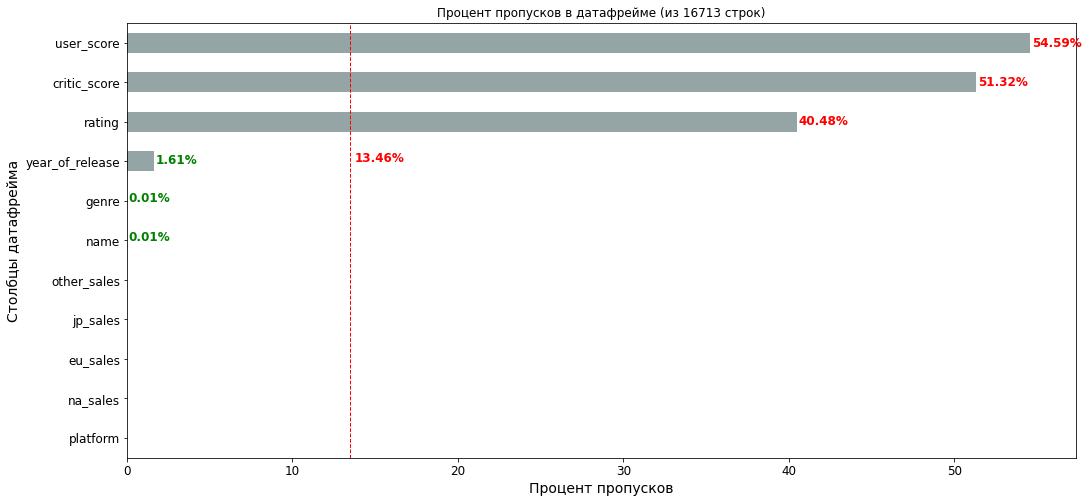

In [10]:
# Строим горизонтальную столбчатую диаграмму пропусков
# Используем функцию для визуализации пропусков
def percent_hbar(df, old_threshold=None):
    percent_of_nulls = (df.isnull().sum() / len(df) * 100).sort_values().round(2)
    threshold = percent_of_nulls.mean()
    ax = percent_of_nulls.plot(
        kind='barh', figsize=(17, 8), 
        title='Процент пропусков в датафрейме (из {} строк)'.format(len(df)), 
        color='#95a5a6', legend=False, fontsize=12
    )
    ax.set_xlabel('Процент пропусков', fontsize=14)  # Подпись оси X
    ax.set_ylabel('Столбцы датафрейма', fontsize=14)  # Подпись оси Y
    dict_percent = dict(percent_of_nulls)
    i = 0
    for k in dict_percent:
        color = 'green'
        if dict_percent[k] > 0:
            if dict_percent[k] > threshold:
                color = 'red'
            ax.text(dict_percent[k] + 0.1, i + 0.09, str(dict_percent[k]) + '%', 
                    color=color, fontweight='bold', fontsize='large')
        i += 0.98
    if old_threshold is not None:
        plt.axvline(x=old_threshold, linewidth=1, color='r', linestyle='--')
        ax.text(old_threshold + 0.3, 10, '{0:.2%}'.format(old_threshold / 100), 
                color='r', fontweight='bold', fontsize='large')
        plt.axvline(x=threshold, linewidth=1, color='green', linestyle='--')
        ax.text(threshold + 0.3, 7, '{0:.2%}'.format(threshold / 100), 
                color='green', fontweight='bold', fontsize='large')
    else:
        plt.axvline(x=threshold, linewidth=1, color='r', linestyle='--')
        ax.text(threshold + 0.3, 7, '{0:.2%}'.format(threshold / 100), 
                color='r', fontweight='bold', fontsize='large')
    return ax, threshold

# Применение функции к датафрейму
plot, threshold = percent_hbar(computer_games_data)

# Отображение графика
plt.show()

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

Согласно полученной визуализации, **средний процент пропусков находится примерно на уровне 13,46%** (обозначен красной вертикальной линией). Столбцы с процентом выше этого значения (`user_score`, `critic_score` и `rating`) можно считать проблемными для анализа. 

В столбце `user_score` после замены `tbd` на `NaN` вместо начальных **40,09%** пропусков теперь **54,59%** (количество отсутствующих данных **увеличилось на 14,5%**).

Начнем обработку пропусков со столбцов `name` и `genre`, там всего по 0,01 % пропусков.

In [11]:
# Выведем строки с пропущенными значениями в столбце 'name'
display(computer_games_data[computer_games_data['name'].isnull()])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.0,0.08,NaN,NaN,NaN


Видим, что это всего 1 строка и в ней большинство столбцов содержат пропуски. Такие данные для анализа не сыграют особой роли, поэтому **их предлагается удалить** (потеря составит **0,01%** от всех данных).

In [12]:
# Удаление строк с пропусками в столбце 'name'
computer_games_data = computer_games_data.dropna(subset=['name'])

# Проверка
# print(computer_games_data.isna().sum())

В столбцах `name` и `genre` пропусков теперь нет, переходим к `year_of_release`.

In [13]:
# Выведем строки с пропущенными значениями в столбце 'year_of_release'
computer_games_data[computer_games_data['year_of_release'].isnull()].head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,<NA>,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,<NA>,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,<NA>,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN


Посмотрим на уникальные **названия игр, в которых не указан год выпуска**.

In [14]:
# Получение уникальных значений из столбца 'name', где в 'year_of_release' есть пропуски
set(computer_games_data[computer_games_data['year_of_release'].isnull()]['name'])

{'AKB1/48: Idol to Guam de Koishitara...',
 'Action Man-Operation Extreme',
 'Advance Wars: Days of Ruin',
 'Adventure',
 'Agarest Senki: Re-appearance',
 'Air-Sea Battle',
 'Alex Rider: Stormbreaker',
 'All-Star Baseball 2005',
 'Alone in the Dark: The New Nightmare',
 'Aquaman: Battle for Atlantis',
 'Atsumare! Power Pro Kun no DS Koushien',
 'B.L.U.E.: Legend of Water',
 'Backbreaker',
 'Battle vs. Chess',
 'Bejeweled 3',
 'Beyond the Labyrinth',
 'Big Beach Sports 2',
 'Bikkuriman Daijiten',
 'BioShock 2',
 'Breakaway IV',
 'Brothers in Arms: Furious 4',
 'Build-A-Bear Workshop: Friendship Valley',
 "Cabela's Alaskan Adventure",
 'Call of Duty 3',
 'Call of Duty: Black Ops',
 'Captain America: Super Soldier',
 'Charm Girls Club: My Fashion Mall',
 'Charm Girls Club: My Fashion Show',
 'Chou Soujuu Mecha MG',
 'Circus Atari',
 'Clockwork Empires',
 'College Hoops 2K6',
 'Combat',
 'Combat Elite: WWII Paratroopers',
 'Combat Wings: The Great Battles of WWII',
 "Cubix Robots for Every

Видим, что в некоторых названиях указан год. Можно предположить, что это год выпуска игры. Если это так, то предлагается создать словарь с названиями игр и годами их выпуска и вручную заполнить пропуски в столбце `year_of_release`. 

Однако, при проверке выснилось, что это предположение не верно. К примеру, даты выхода игры `All-Star Baseball 2005` в США на PS2 - 8 апреля 2004 г., на Xbox - 23 марта 2004, `Football Manager 2007` - 20 октября 2006г. Следовательно, такой способ заполнения пропусков  в данной ситуации не корректен.

Т.к. процент пропущенных значений в столбце `year_of_release` не велик (`1,61%`), то предлагается **удалить строки с данными пропусками**. Существенного влияния на будущие результаты анализа это действие не должно оказать.

In [15]:
# Удаление строк с пропусками в столбце 'year_of_release'
computer_games_data = computer_games_data.dropna(subset=['year_of_release'])

# Проверка
# (computer_games_data.isnull().mean() * 100).round(2)

Теперь нужно решить вопрос с пропусками в столбцах: оценка критиков, оценка пользователей и рейтинг от организации ESRB.

In [16]:
computer_games_data.describe()

,year_of_release,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score
count,16443.000000,16443.000000,16443.000000,16443.000000,16443.000000,7982.000000,7462.000000
mean,2006.485921,0.264028,0.145939,0.078492,0.047597,68.992608,7.126548
std,5.875546,0.818400,0.506731,0.311109,0.188011,13.920049,1.499429
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000,6.400000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000,7.500000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000,8.200000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000,9.700000


Изначально, была осуществлена попытка скрапинга пропущенных данных (оценки и рейтинга) с дальнейщим сохранением результатов в отдельный файл. Но во всех случаях (даже после очистки названий игры для использования в URL, отбору как по платфоре и названию игры, так и только по названию игры) данные подгрузить не удалось (простыню кода вставлять не будем, чтообы не засорять проект лишней непригодившейся информацией).

В связи с этим, нужно иначе решить вопрос с оставшимися пропусками. Так как в столбцах `user_score`, `critic_score` и `rating` имеется значительная часть пропусков (`54,59%`, `51,32%` и `40,48%` соответственно), то их удаление приведет к весомой, играющей важную роль для анализа, части данных.  Заполнять медианой, средним значением такие столбцы как оценка критиков, оценка пользователей и рейтинг от организации ESRB, так же существенно исказит результаты анализа. Здесь либо оставляем как есть, но тогда в анализе эти данные не будут присутствовать, либо заполнить пропуски специальными заглушками, например `-1` или `Unknown`. Но т.к. `Unknown` подходит хорошо для категорий, предлагается пропуски в `user_score` и `critic_score` заплнить заглушкой `-1`, а в `rating` - заглушкой `Unknown`. 

In [17]:
# Заполняем пропуски в столбцах 'rating', 'user_score' и 'critic_score' значением -1
computer_games_data['rating'] = computer_games_data['rating'].fillna('Unknown')
computer_games_data['user_score'] = computer_games_data['user_score'].fillna(-1)
computer_games_data['critic_score'] = computer_games_data['critic_score'].fillna(-1)

# Проверяем результат
print(computer_games_data[['rating', 'user_score', 'critic_score']].isnull().sum())

rating          0
user_score      0
critic_score    0
dtype: int64


Все пропуски заполнены заглушками, теперь **посчитаем процент удаленных данных** и определим, не критичен ли он для дальнейшего анализа. 

In [18]:
# Вычисляем количество удаленных строк
removed_rows = len(original_data) - len(computer_games_data)

# Рассчитываем процент удаленных данных
percent_removed = (removed_rows / len(original_data)) * 100

print(f"Количество удаленных строк: {removed_rows}")
print(f"Процент удаленных данных: {percent_removed:.2f}%")

Количество удаленных строк: 272
Процент удаленных данных: 1.63%


Видим, что удалено 1,63% данных (272 строки). Это можно отнести к **минимальному искажению выборки: удаление 1.63% данных не должно существенно повлиять на результаты анализа и выводы**. 

Теперь опишем возможные причины образования пропусков.

##### Возможные причины пропусков в данных:

Пропуски в столбце `critic_score` (оценка критиков) могли возникнуть по причинам отсутствия обзоров критиков, т.е. некоторые игры не получили оценок от профессиональных критиков, особенно если они малопопулярны или выпущены для узкого сегмента аудитории. Оценки могли так же отсутствовать в источниках данных из-за проблем с их сбором или обновлением (например, база данных Metacritic не обновлялась вовремя). Ну и игры, выпущенные для старых или редких платформ, могут не иметь критических оценок.

Пропуски в столбце `user_score` (оценка пользователей) могли возникнуть из-за недостатка пользователе - если игра не популярна, пользователи могли просто не оставлять отзывы и оценки. Так же пропуски могли возникнуть из-за ошибок в системе сбора пользовательских оценок или из-за их неполного импорта. Или, например, игра могла быть недавно выпущена, и пользователи ещё не успели её оценить.

Пропуски в отзывах могут быть связаны также с низким уровнем продаж игры, из-за чего не набралось достаточного количества пользовательских отзывов для формирования итоговой оценки.

Пропуски в столбце `rating` (возрастной рейтинг ESRB) могли возникнуть по причине того, что игра не была оценена ESRB: некоторые игры, особенно инди-проекты или локальные релизы, могут не проходить сертификацию в ESRB. Так же для игр, выпущенных за пределами США (например, в Японии или Европе), рейтинг ESRB может отсутствовать, так как там используются другие системы (PEGI, CERO). Ну и данные о рейтинге могли быть потеряны при переносе или обновлении базы данных.


#### Посчет суммарных продаж во всех регионах и  их запись в отдельный столбец

Посчитаем суммарные продажи во всех регионах и запишем их в отдельный столбец `total_sales`.

In [19]:
# Считаем суммарные продажи по всем регионам
computer_games_data['total_sales'] = (
    computer_games_data['na_sales'] + 
    computer_games_data['eu_sales'] + 
    computer_games_data['jp_sales'] + 
    computer_games_data['other_sales']
)

# Проверяем результат
display(computer_games_data[['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head())

,na_sales,eu_sales,jp_sales,other_sales,total_sales
0,41.36,28.96,3.77,8.45,82.54
1,29.08,3.58,6.81,0.77,40.24
2,15.68,12.76,3.79,3.29,35.52
3,15.61,10.93,3.28,2.95,32.77
4,11.27,8.89,10.22,1.00,31.38


Для общего понимания ситуации построим здесь еще визуализацию по суммарным продажам по каждому региону. 

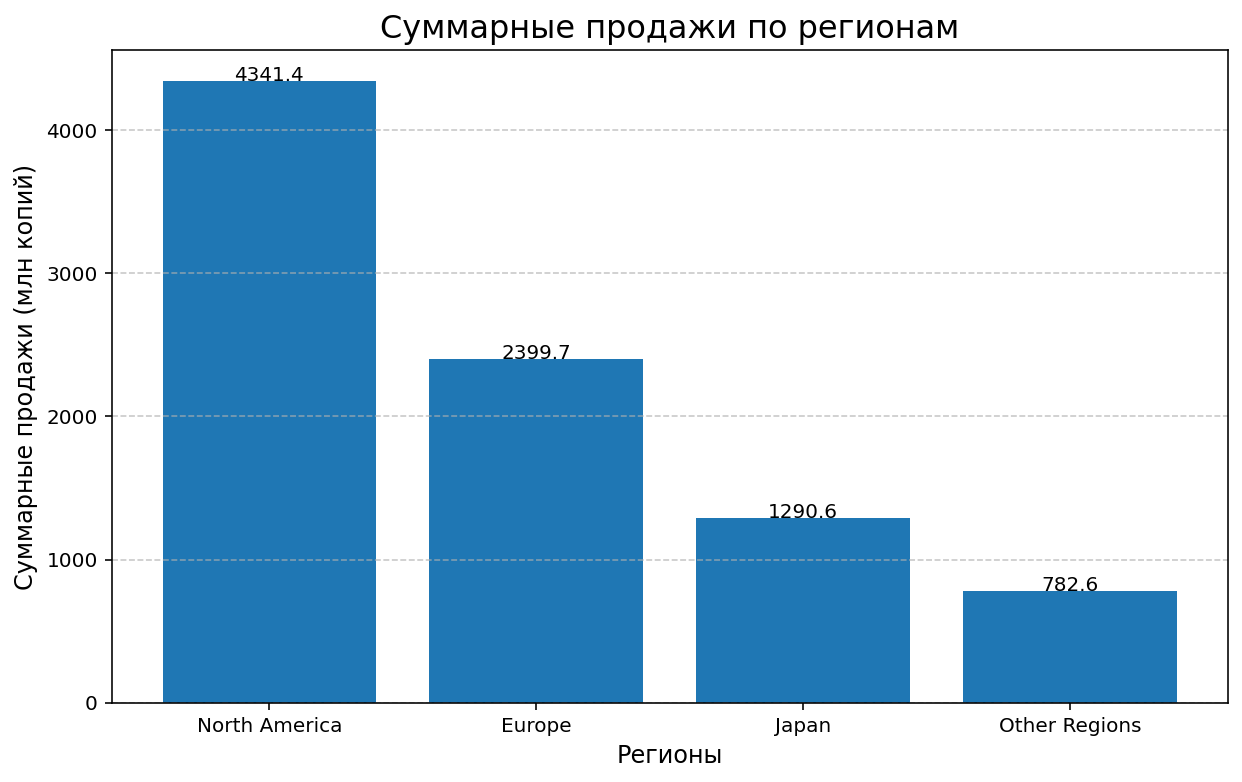

In [20]:
# Суммируем продажи по регионам
region_sales = {
    'North America': computer_games_data['na_sales'].sum(),
    'Europe': computer_games_data['eu_sales'].sum(),
    'Japan': computer_games_data['jp_sales'].sum(),
    'Other Regions': computer_games_data['other_sales'].sum()
}

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 6))
plt.bar(region_sales.keys(), region_sales.values())
plt.title('Суммарные продажи по регионам', fontsize=16)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)
plt.xlabel('Регионы', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Подписи на столбцах
for index, value in enumerate(region_sales.values()):
    plt.text(index, value + 1, f'{value:.1f}', ha='center', fontsize=10)

plt.show()

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

Видим, что North America лидируем по суммарным продажам (4352,9 млн. копий), на втоором место стоит Europe (2405,4 млн. копий), затем Japan и другие регионы. 

Нами выполненны все шаги по первичному анализу данных и обработке, переходим к проведению исследовательского анализа данных.

#### Вывод по разделу

В настоящем разделе были произведены первичный обзор и предобработка данных.

**Первичный обзор данных показал**, что

Датайфрейм `computer_games_data (данные о продажах игр, оценки пользователей, экспертов, жанры и платформы)`:
- содержит 16175 строк и 11 столбцов;
- наименование столбцов не соответствуют стилю `snake_case`, нужно привести к нижнему регистру;
- не все указанные типы данных соответствуют данным, сожержащимся в столбцах:
    - в столбце `Year_of_Release` (год выпуска) стоит тип данных `float64`, нужно преобразовать в `int` (в тип `datetime` преобразовывать здесь не нужно, это будет избыточно для анализа, т.к. столбец `Year_of_Release` содержит не полную дату (например, день, месяц и год), а только числовое значение года);
    - в столбце `User_Score` тип данных `object`, а нужен `float64`;
- в 6-ти столбцах из 11-ти содержаться пропуски:
    - `Name` - **2** пропуска (**0,01%** данных)
    - `Year_of_Release` - **269** пропусков (**1,61%** данных)
    - `Genre` - **2** пропуска (**0,01%** данных)
    - `Critic_Score` - **8578** проопусков (**51,32%** данных)
    - `User_Score` - **6701** пропуск (**40,09%** данных)
    - `Rating` - **6766** пропускоов (**40.48%** данных)
- данные предоставлены за период **с 1980 г. по 2016 г.**;
- максимальная оценка критиков 98, минимальная - 13;
- **явных дубликатов нет**;
- выявлено **2 неявных дубликата** (имя, платформа и год релиза совпадают)
- **топ-5 игр по названию**:
     - Need for Speed: Most Wanted - 12
     - LEGO Marvel Super Heroes - 9
     - Ratatouille - 9
     - FIFA 14  - 9
     - Madden NFL 07 -  9
- **топ-5 платфоорм**:
     - PS2 - 2161
     - DS - 2151
     - PS3 - 1331
     - Wii - 1320
     - X360 - 1262
- **топ-5 жанров игр**:
    - Action - 3369
    - Sports - 2348
    - Misc - 1750
    - Role-Playing - 1498
    - Shooter - 1323
- **рейтинг от организации ESRB**:
    - E - 3990
    - T - 2961
    - M - 1563
    - E10+ -  1420
    - EC - 8
    - K-A - 3
    - RP - 3
    - AO - 1.

**В результате предобработке были выполнены следующие действия:**
1. Все **названия столбцов** преобразованы в нижний регистр.
2. Все данные приведены к нужным типам.
3. Выявлено, что в анализируемом датафрейме имеются строки с аббревиатурой `tbd` (`2424 строки / 14,5% ` от всех данных). Произведена их замена на `NaN`. В столбце `user_score` после замены `tbd` на `NaN` вместо начальных `40,09%` пропусков теперь `54,59%` (количество отсутствующих данных увеличилось на `14,5%`).
3. Все **неявные дубликаты** (2) удалены.
4. Установлено, что **средний процент пропусков** находится примерно на уровне `13,46`%. Столбцы с процентом выше этого значения (user_score, critic_score и rating) считаются проблемными для анализа.
5. Пропуски со столбцах `name` и `genre` (по 0,01 % пропусков) удалены.
6. Пропуски в столбце `year_of_release` также удалены (`1,61%` от общего объема информации). Изначально была прoведена работа по отработке версии, что год в названиях игp - это год выпуска игры. В этом случае, предлагалось создать словарь с названиями игр и годами их выпуска и вручную заполнить пропуски в столбце `year_of_release`. Однако, при проверке выснилось, что это предположение не верно. К примеру, даты выхода игры `All-Star Baseball 2005` в США на PS2 - 8 апреля 2004 г., на Xbox - 23 марта 2004; `Football Manager 2007` - 20 октября 2006г. Следовательно, такой способ заполнения пропусков в данной ситуации не корректен, пропуски удалили.
7. В столбцах `user_score`, `critic_score` и `rating` выявлена значительная часть пропусков (`54,59%`, `51,32%` и `40,48%` соответственно). Принято решение пропуски в `user_score` и `critic_score` заплнить заглушкой `-1`, а в `rating` - заглушкой `Unknown`.
8. Посчитет процента удаленных данных показал, что потеря составила `1,63%` данных (`272` строки). Это можно отнести к минимальному искажению выборки: удаление 1.63% данных не должно существенно повлиять на результаты анализа и выводы.
9. Выявлены **возможные причины пропусков** в данных:
- Пропуски в столбце `critic_score` (оценка критиков) могли возникнуть по причинам отсутствия обзоров критиков, т.е. некоторые игры не получили оценок от профессиональных критиков, особенно если они малопопулярны или выпущены для узкого сегмента аудитории. Оценки могли так же отсутствовать в источниках данных из-за проблем с их сбором или обновлением (например, база данных Metacritic не обновлялась вовремя). Ну и игры, выпущенные для старых или редких платформ, могут не иметь критических оценок.

- Пропуски в столбце `user_score` (оценка пользователей) могли возникнуть из-за недостатка пользователе - если игра не популярна, пользователи могли просто не оставлять отзывы и оценки. Так же пропуски могли возникнуть из-за ошибок в системе сбора пользовательских оценок или из-за их неполного импорта. Или, например, игра могла быть недавно выпущена, и пользователи ещё не успели её оценить. Пропуски в отзывах могут быть связаны также с низким уровнем продаж игры, из-за чего не набралось достаточного количества пользовательских отзывов для формирования итоговой оценки.

- Пропуски в столбце `rating` (возрастной рейтинг ESRB) могли возникнуть по причине того, что игра не была оценена ESRB: некоторые игры, особенно инди-проекты или локальные релизы, могут не проходить сертификацию в ESRB. Так же для игр, выпущенных за пределами США (например, в Японии или Европе), рейтинг ESRB может отсутствовать, так как там используются другие системы (PEGI, CERO). Ну и данные о рейтинге могли быть потеряны при переносе или обновлении базы данных.

10. Был произведен посчет суммарных продаж во всех регионах и записан их в отдельный столбец `total_sales`.

Краткие выводы по разделу сформированы, переходим к исследовательскому анализу данных.

### Исследовательский анализ данных 

<a id='data_analysis'></a> 

#### Анализ количества выпускаемых игр по годам
<a id='4.1'></a>
Посмотрим, сколько игр выпускалось в разные годы и определим, важны ли данные за все периоды.

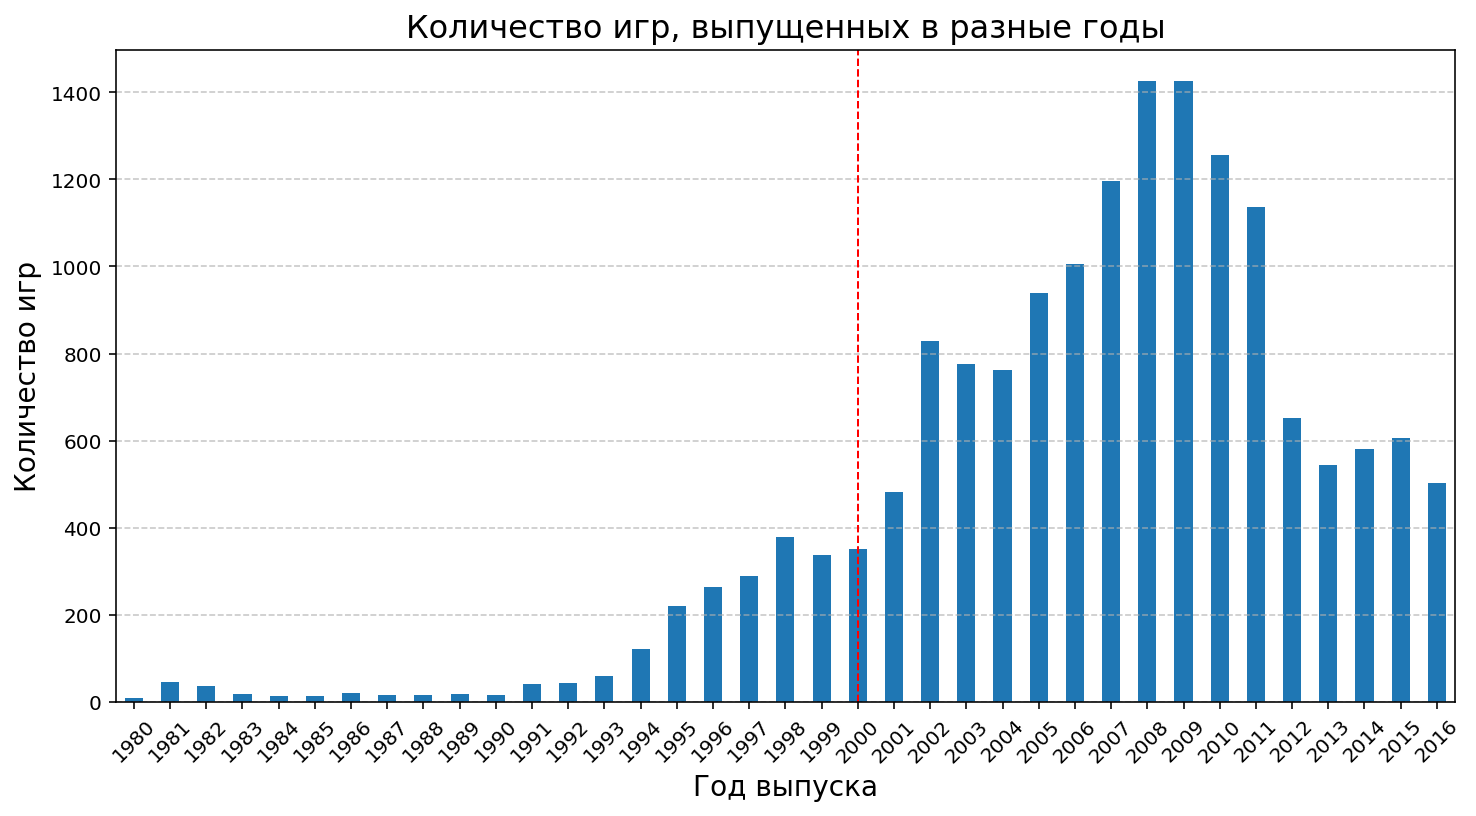

In [21]:
# Группируем данные по году выпуска и считаем количество игр
games_per_year = computer_games_data.groupby('year_of_release')['name'].count()

# Построение графика
plt.figure(figsize=(12, 6))
games_per_year.plot(kind='bar')

# Добавляем вертикальную линию на уровне 2000
plt.axvline(x=2000 - games_per_year.index.min(), color='red', linestyle='--', linewidth=1)

plt.title('Количество игр, выпущенных в разные годы', fontsize=16)
plt.xlabel('Год выпуска', fontsize=14)
plt.ylabel('Количество игр', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

В игровой индустрии наблюдается **устойчивый рост количества выпущенных игр с 1995 года, который достигает своего пика в период с 2006 по 2009 год.** Это связано с активным развитием технологий, ростом популярности видеоигр и появлением новых платформ. Однако после 2009 года количество выпускаемых игр начало снижаться, вероятно, из-за увеличения затрат на разработку высококачественных игр, а также смещения акцента на мобильные и инди-игры. 


Данные до 2000 года представляют меньшую ценность для анализа, так как индустрия игр и предпочтения пользователей значительно изменились с тех пор. Для более точного анализа текущих тенденций и планирования продаж в 2017 году **рекомендуется сосредоточиться на данных за период с 2000 по 2016 год**, так как они отражают современные платформы и актуальные жанры.

#### Анализ продаж по платформам

Сначала посмотрим **на общее количество продаж по каждой платформе** на протяжение всего анализируемого периода.

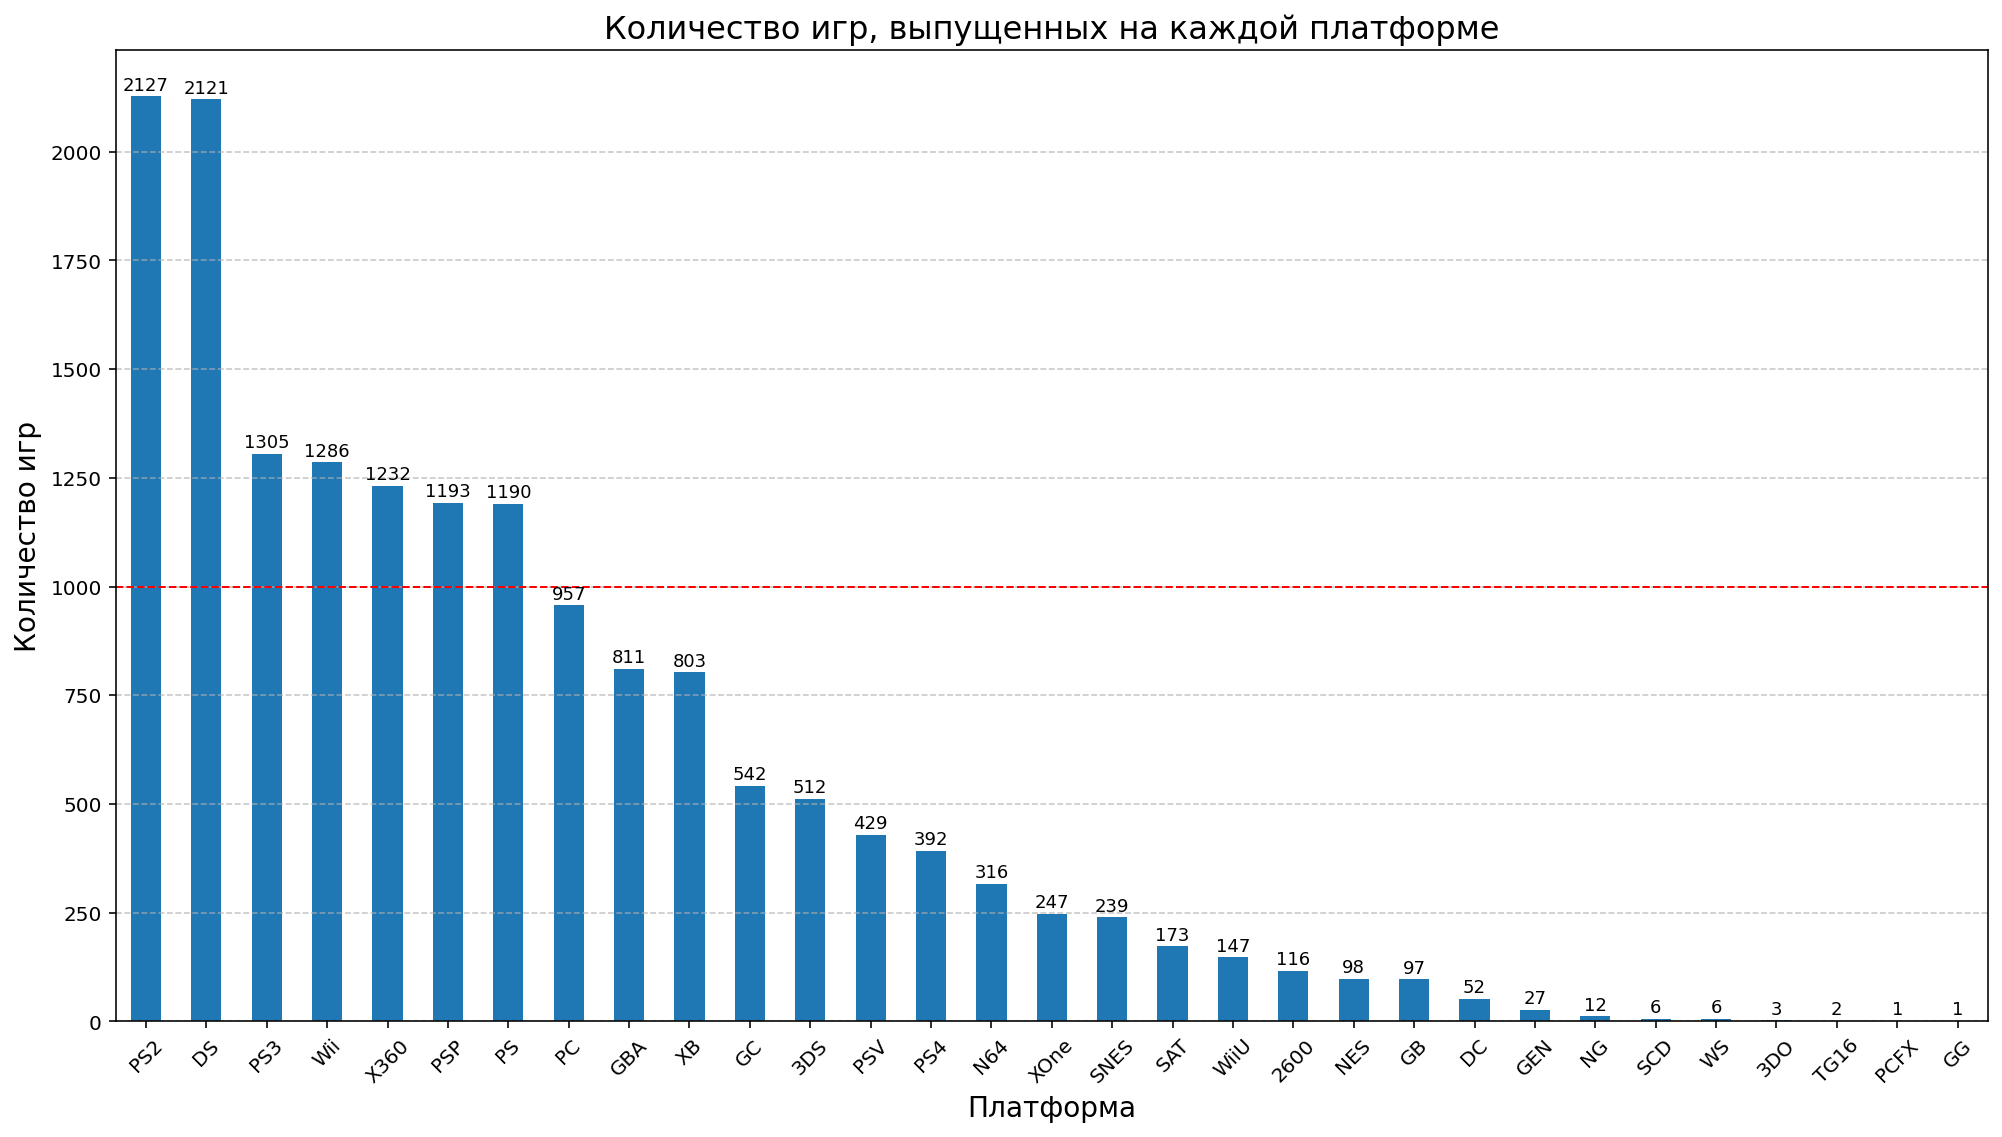

In [22]:
# Группируем данные по платформам и считаем количество выпущенных игр
game_count_by_platform = computer_games_data.groupby('platform')['name'].count().sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(14, 8))
ax = game_count_by_platform.plot(kind='bar')

# Добавляем подписи значений на столбцах
for i, value in enumerate(game_count_by_platform):
    ax.text(i, value + 5, str(value), ha='center', va='bottom', fontsize=9)
    
# Добавляем красную пунктирную линию на уровне 1000
plt.axhline(y=1000, color='red', linestyle='--', linewidth=1) 

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

# Настройка графика
plt.title('Количество игр, выпущенных на каждой платформе', fontsize=16)
plt.xlabel('Платформа', fontsize=14)
plt.ylabel('Количество игр', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Видим, что по количеству предлагаемых игр на протяжение всего анализируемого периода **лидирует 7 платформ: `PS2`, `DS`, `PS3`, `Wii`, `X360`, `PSP` и `PS`** (более 1000 игр). 

Теперь посмотрим, как менялись продажи по платформам. Сначала **посчитаем суммарные продажи по всем платформам**. 

In [23]:
# Считаем суммарные продажи по платформам
platform_sales = computer_games_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales

platform
PS2     1233.56
X360     961.24
PS3      931.33
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
PC       255.76
GB       254.43
XB       251.57
NES      251.05
N64      218.01
SNES     200.04
GC       196.73
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64

Видим, что по самым крупным суммарным продажам можно выделить основные **6 платформ: `PS2`, `X360`, `PS3`, `Wii`, `DS` и `PS`**. Далее продажи значительно ниже. Однако, если только их выбрать в качестве топовых платформ, исходя из наибольших суммарных продаж, можно упустить текущую картину за 2016 год.  Т.е., например, PS4, XOne, и 3DS -  новые, только развивающиеся платформы, они могут пока не иметь высоких продаж, однако, тоже должны быть учтены при анализе и формировании решений на будущее.

Поэтому в данном случае, предлагаеся взять все платформы без формирования топового списка, но период взять с 2000 года, т.к. в [п.4.1.](#4.1) настоящего исследования было определено, что данные до 2000 года представляют меньшую ценность для анализа - индустрия игр и предпочтения пользователей значительно изменились с тех пор.

Построим распределение по годам. А далее определим за какой характерный срок появляются новые и исчезают старые платформы.

<Figure size 1152x720 with 0 Axes>

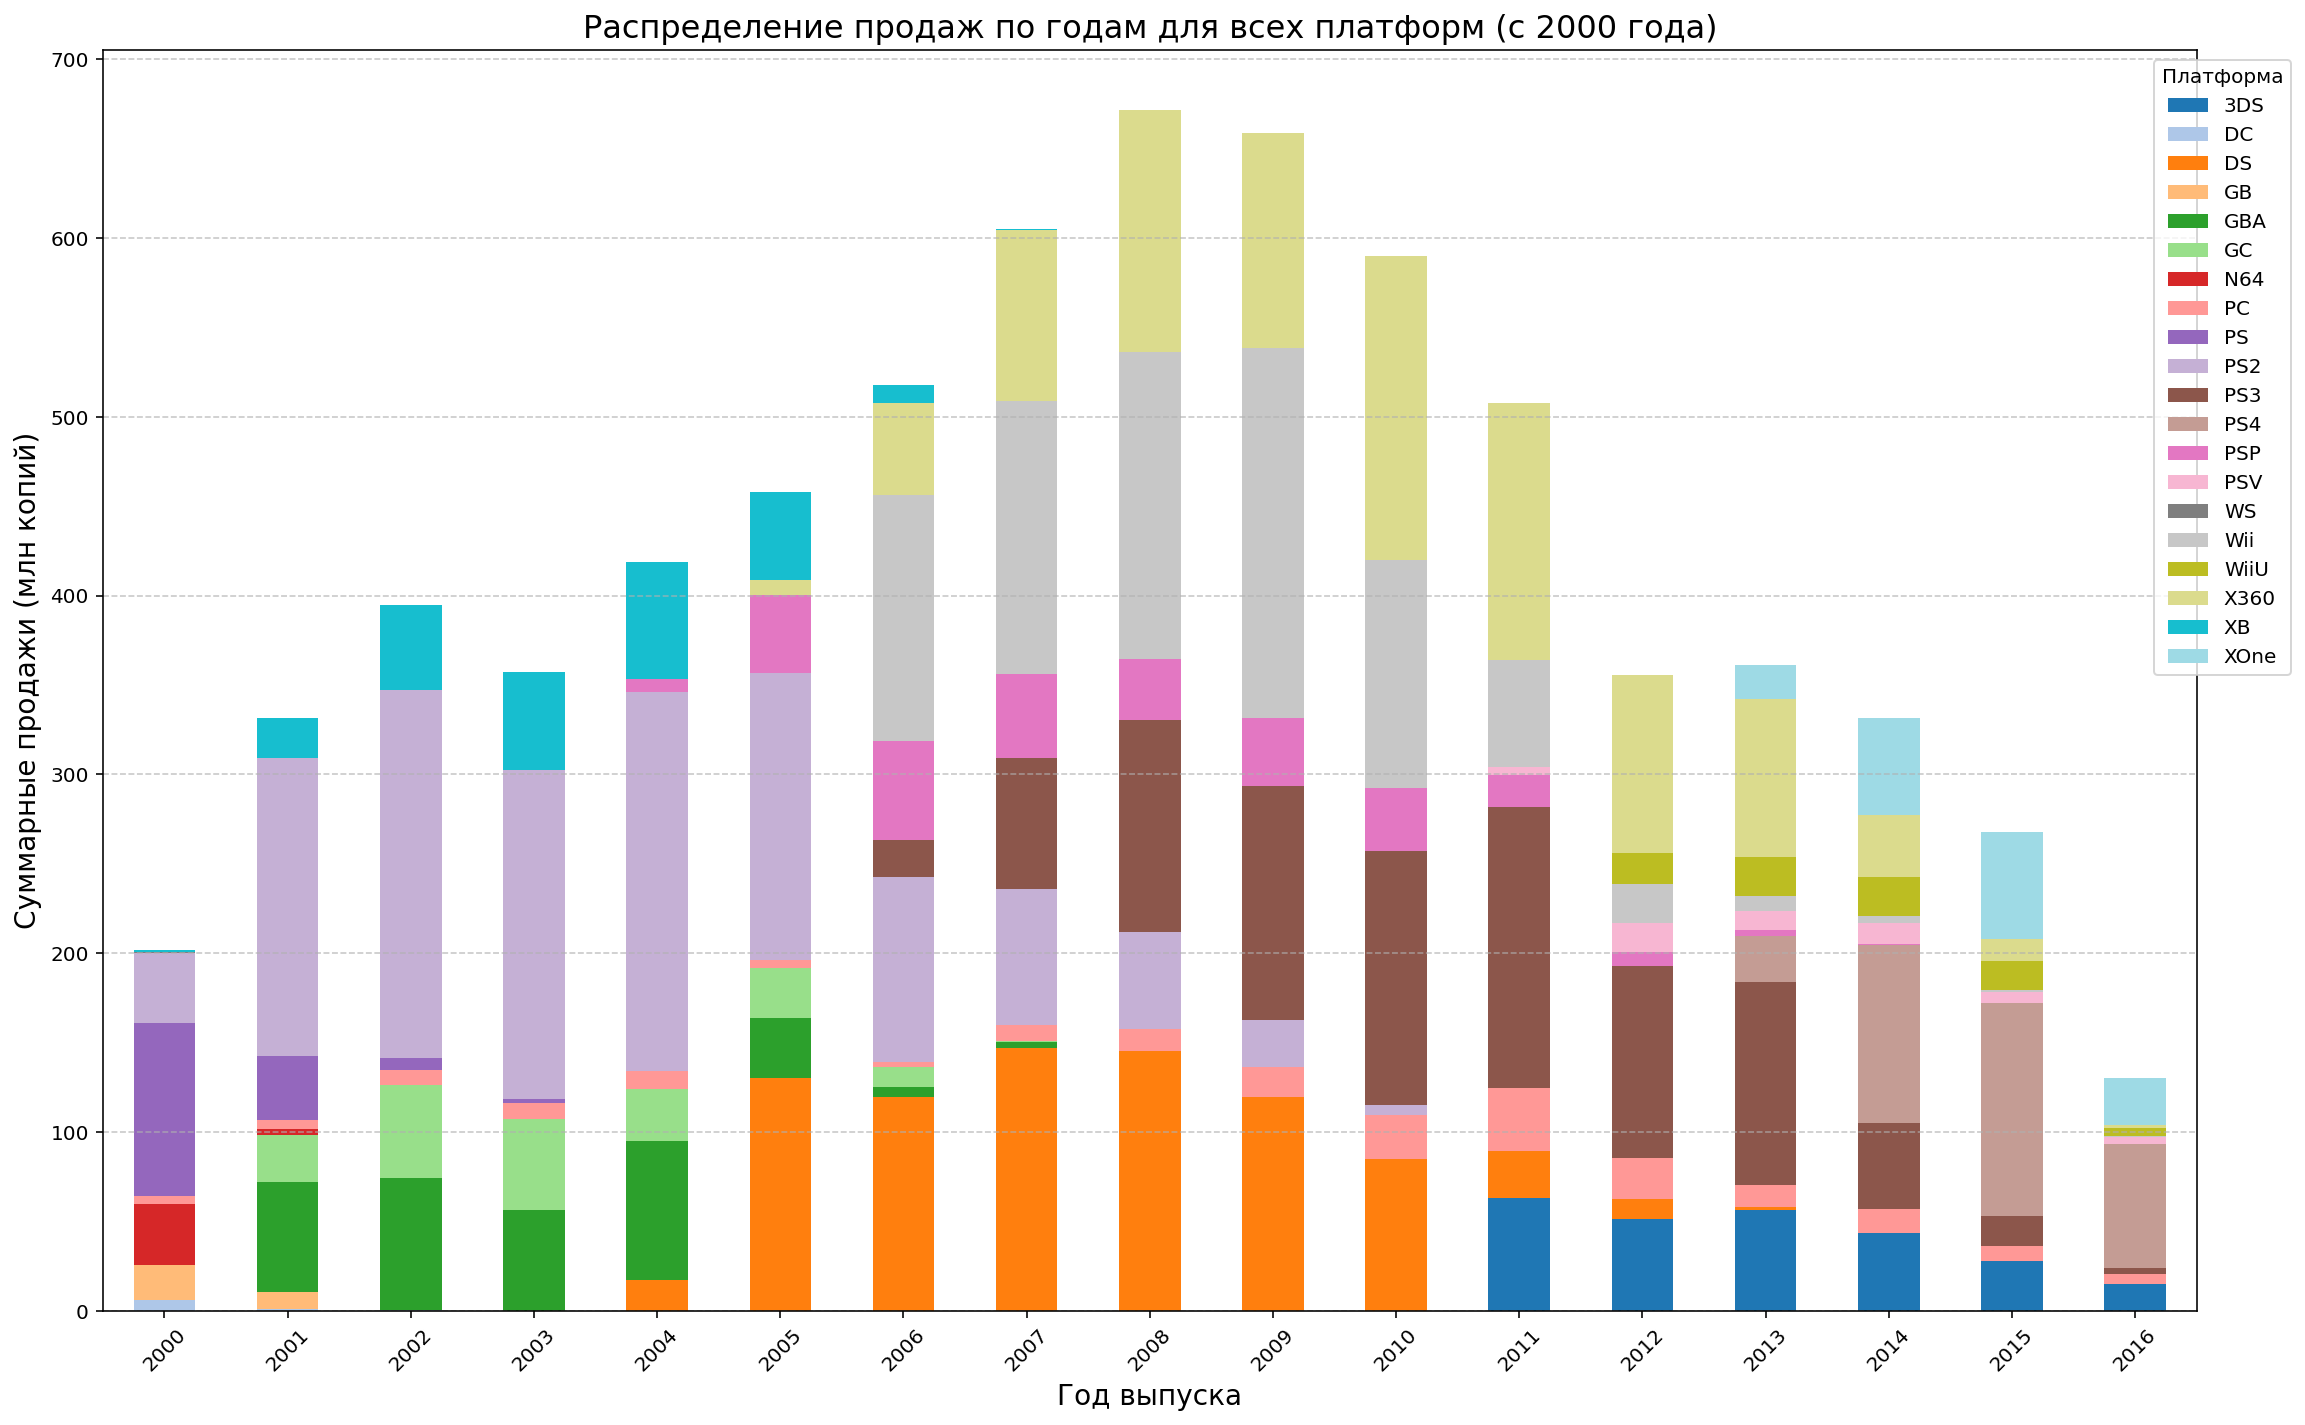

Жизненный цикл всех платформ (с 2000 года): 7.5 лет.


In [24]:
# Фильтруем данные с 2000 года
filtered_data = computer_games_data[computer_games_data['year_of_release'] >= 2000]

# Группируем данные по платформам и годам, суммируя продажи
platform_sales_by_year_filtered = filtered_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

# Построение графика для всех платформ с 2000 года
plt.figure(figsize=(16, 10))
platform_sales_by_year_filtered.plot(kind='bar', stacked=True, colormap='tab20', figsize=(16, 10))
plt.title('Распределение продаж по годам для всех платформ (с 2000 года)', fontsize=16)
plt.xlabel('Год выпуска', fontsize=14)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Платформа', fontsize=10, bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Определяем жизненный цикл для всех платформ с 2000 года
time_life_filtered = filtered_data.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']).reset_index()
time_life_filtered['life'] = time_life_filtered['max'] - time_life_filtered['min'] + 1  # Включаем границы диапазона

# Выводим медианный жизненный цикл для всех платформ с 2000 года
print(f"Жизненный цикл всех платформ (с 2000 года): {time_life_filtered['life'].median()} лет.")

Анализ продаж по платформам показывает, что самые крупные суммарные продажи достигнуты на таких платформах, как **DS**, **PS2**, **PS3**, **Wii**, **X360** и **PS**. Каждая из этих платформ имеет характерный жизненный цикл, составляющий согласно табличному расчету -  **7,5 лет**, а по визуализации -  в среднем **7–10 лет**. Платформы обычно достигают пика продаж через 2–3 года после своего выхода, после чего их популярность постепенно снижается.

**PS2** активно набирала популярность с 2000 года, достигла пика около 2004–2005 годов и начала терять позиции к 2010 году.   
**Wii** стартовала в 2006 году, быстро завоевала рынок и достигла максимальных продаж к 2008–2009 годам, после чего популярность начала снижаться.   
**PS3** и **X360** доминировали в период с 2006 по 2011 годы, после чего их продажи пошли на спад.   
**DS** стала одной из лидирующих платформ в 2006–2010 годах.   
**PS**, несмотря на возраст, показала хорошие результаты на ранних этапах развития игровой индустрии (затем ее сменила PS2, а последнюю PS3).   

После 2010 года виден спад продаж старых платформ и постепенное появление новых, таких как **PS4** (пришла на смену PS3), **XOne**, **3DS**, **PSV** которые начинают набирать популярность. Для анализа и прогнозирования важно учитывать данные за последние **5–10 лет**, так как они наиболее релевантны для современных тенденций.

#### Определение актуального периода

Чтобы определить актуальный период для анализа и прогнозирования на 2017 год, обобщим ключевые выводы:  
- при анализе количества выпускаемых игр по годам было выявлено, что рекомендуется сосредоточиться на данных за период **с 2000 по 2016 год**;
- при анализе продаж по платформам опледелен характерный жизненный цикл каждой платформы, составляющий в среднем **7–10 лет**;
- при анализе продаж по платформам установлено, что для анализа и прогнозирования важно учитывать данные за последние **5–10 лет**.

Однако,  для прогнозирования в такой динамично развивающейся индустрии, как компьютерные игры, не следует использовать слишком большой временной интервал. Это может привести к учёту уже устаревших трендов.  

Рекомендуется брать данные за **последние 2–5 лет** (включая 2016 год), поскольку это позволяет учитывать актуальные тенденции.  

Таким образом, актуальным периодом для анализа и прогнозирования предлагается считать последние **5 лет**, начиная с **2012 года**. Установим этот период через фильтрацию данных и сохраним в переменной `actual_period_data`.

In [25]:
# Фильтруем данные за период с 2012 по 2016 год
actual_period_data = computer_games_data[computer_games_data['year_of_release'] >= 2012]

# Проверяем данные
actual_period_data['year_of_release'].value_counts().sort_index()

2012    652
2013    544
2014    581
2015    606
2016    502
Name: year_of_release, dtype: Int64

Актуальный период определен и установлен. В настоящей работе **данные за предыдущие годы (до 2012 года) учитываться не будут**.

#### Анализ платформ по продажам (с учетом актуального периода)
Сначала **выведем информацию по десяти платформам с самыми высокими суммарными продажами за весь актуальный период** (топ-10 платформ по суммарным продажам). 

In [26]:
# Суммируем продажи по платформам за актуальный период
top_platforms = actual_period_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# Выводим топ-10 платформ
top_platforms.head(10)

platform
PS4     314.14
PS3     288.78
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
Name: total_sales, dtype: float64

Из полученной информации делаем вывод, что **лидерами по продажам являются PS3 (910.38 млн копий), X360 (901.43 млн копий) и Wii (754.75 млн копий)**. Минимальные продажи у **XOne (159.32  млн копий)**.

Однако, чтобы понять, какие продажи растут, какие падают, построим дополнительно еще визуализацию по годам. 

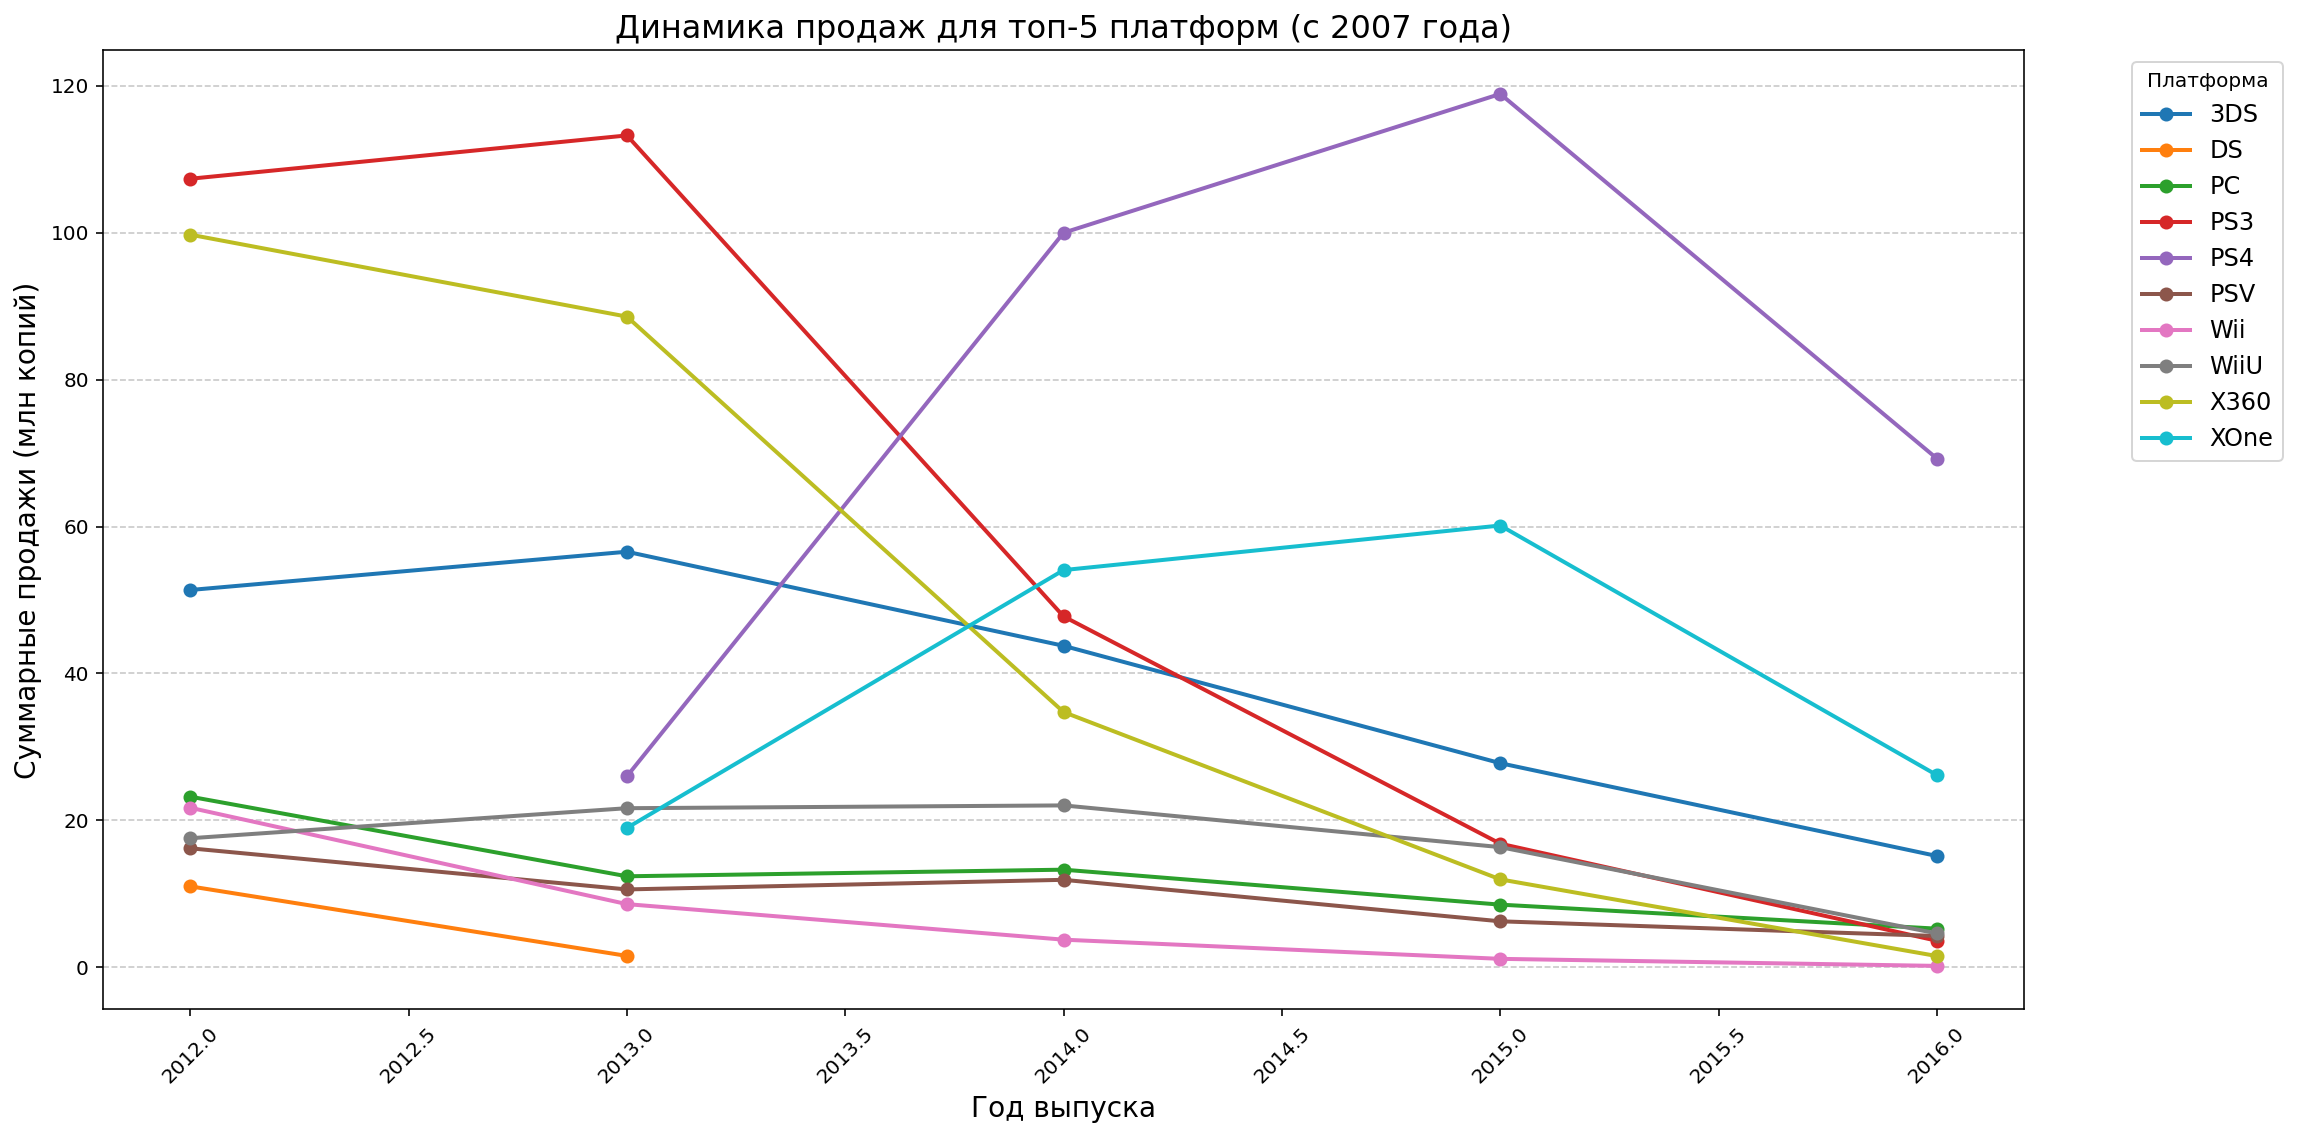

In [27]:
# Определяем топ-10 платформ с наибольшими суммарными продажами за актуальный период
top_10_platforms = actual_period_data.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10).index

# Фильтруем данные для топ-10 платформ
top_10_data = actual_period_data[actual_period_data['platform'].isin(top_10_platforms)]

# Группируем данные по годам и платформам, суммируя продажи
platform_sales_trend_top_10 = top_10_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

# Построение графика
plt.figure(figsize=(16, 8))
platform_sales_trend_top_10.plot(ax=plt.gca(), kind='line', marker='o', linewidth=2)

# Настройка графика
plt.title('Динамика продаж для топ-5 платформ (с 2007 года)', fontsize=16)
plt.xlabel('Год выпуска', fontsize=14)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=14)
plt.legend(title='Платформа', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

Итак, выше было заявлено, что лидерами по продажам являются `PS3`, `X360` и `Wii`, однако **их популярность снижается из-за завершения жизненного цикла**.

**Растущими платформами остаются `PS4` (314.14 млн копий), `XOne` (159.32 млн копий) и `3DS` (257.81 млн копий)**, которые имеют высокий потенциал для увеличения продаж. 

Для прогнозирования на 2017 год **стоит сосредоточиться на `PS4`, `XOne` и `3DS` как на наиболее перспективных платформах**.

#### «Ящик с усами» по глобальным продажам игр в разбивке по платформам

Построим 2 графика «ящик с усами» по глобальным продажам игр в разбивке по платформам (со всеми максимумами продаж за актуальный период и с масштабированными данными).

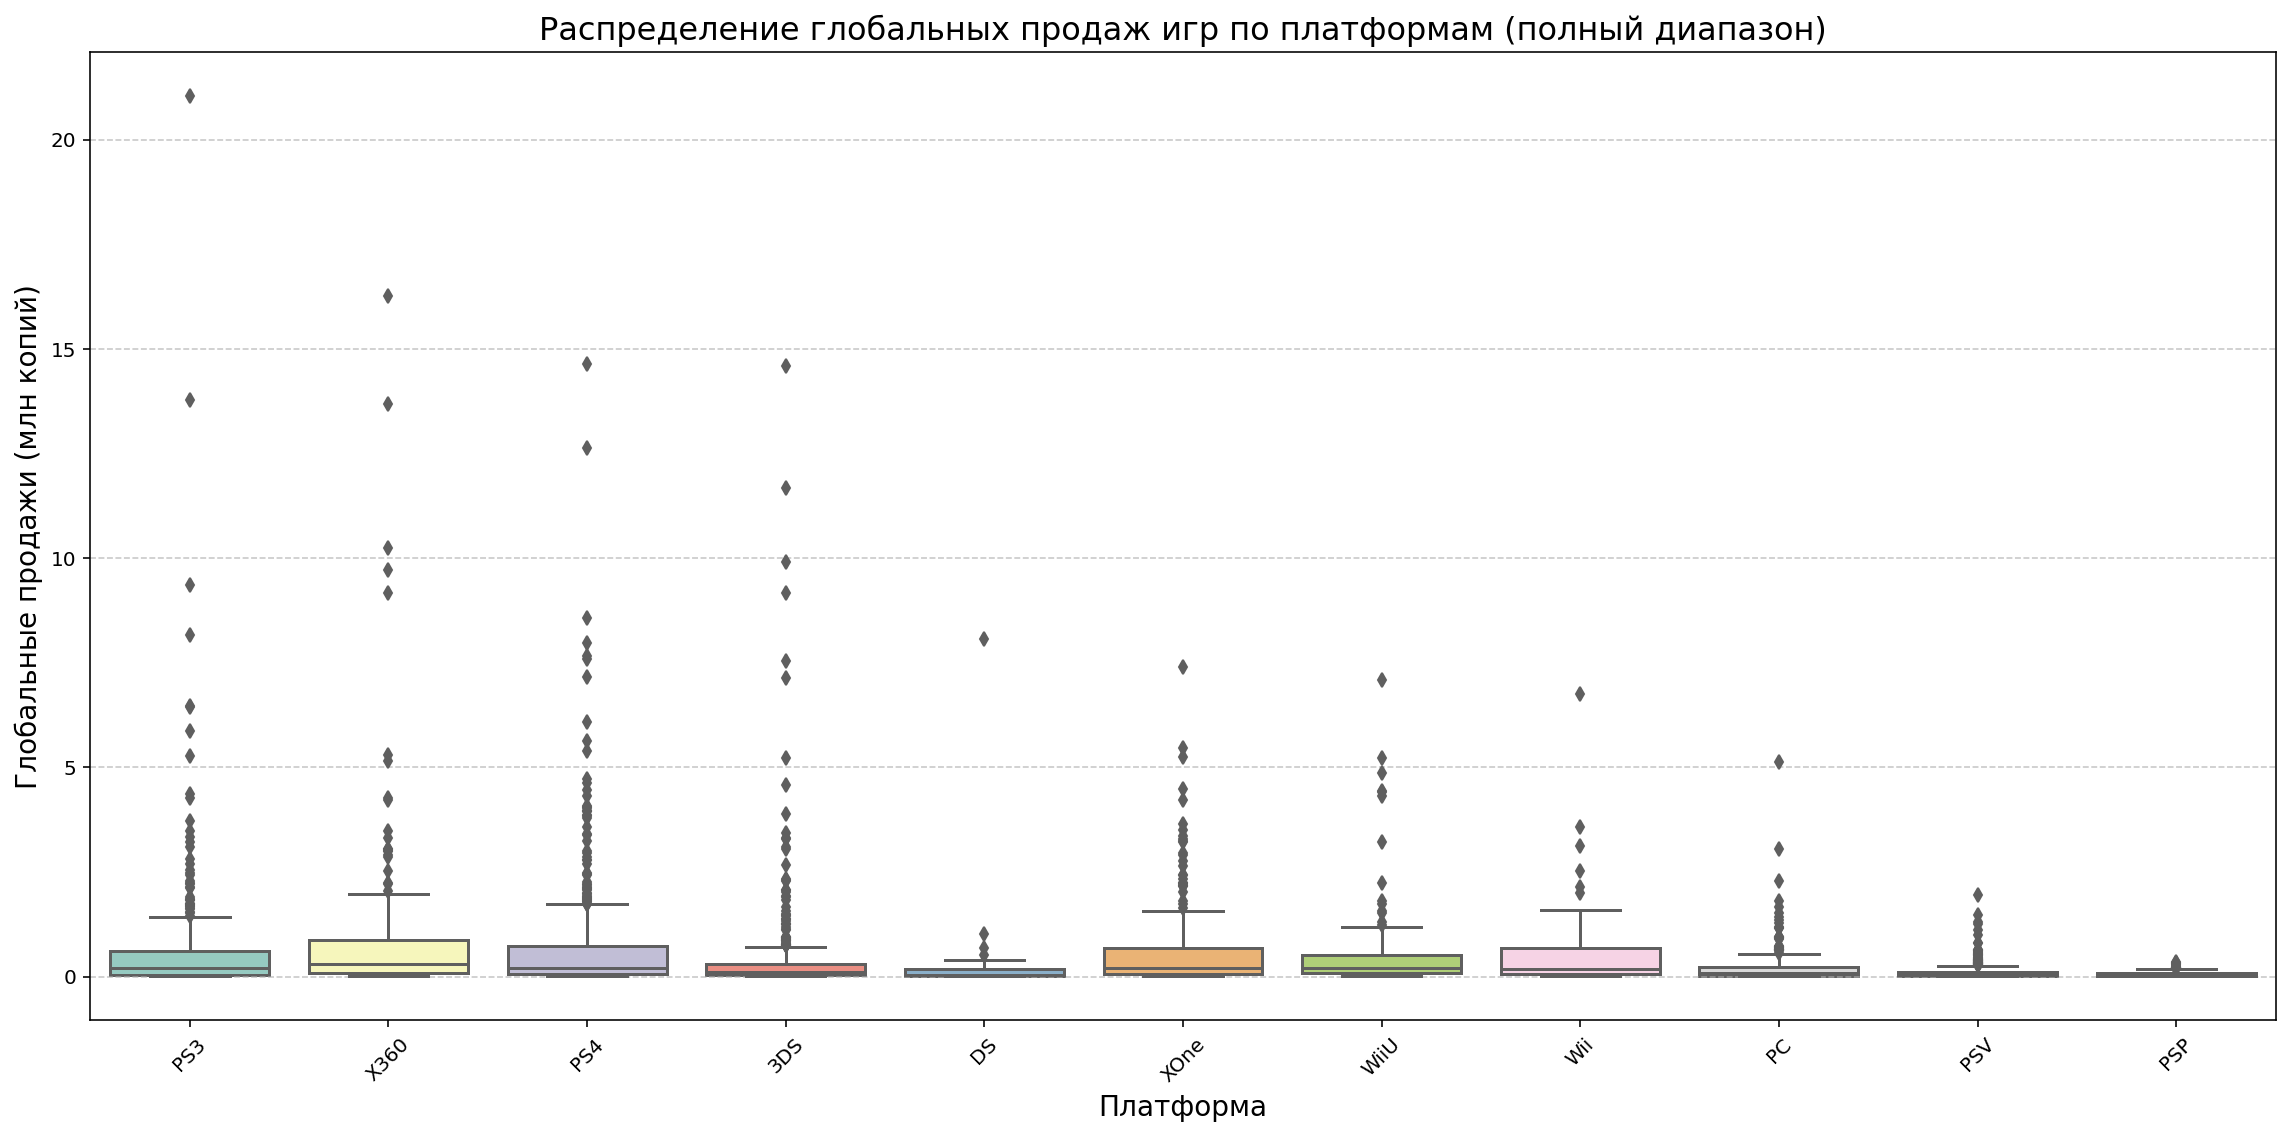

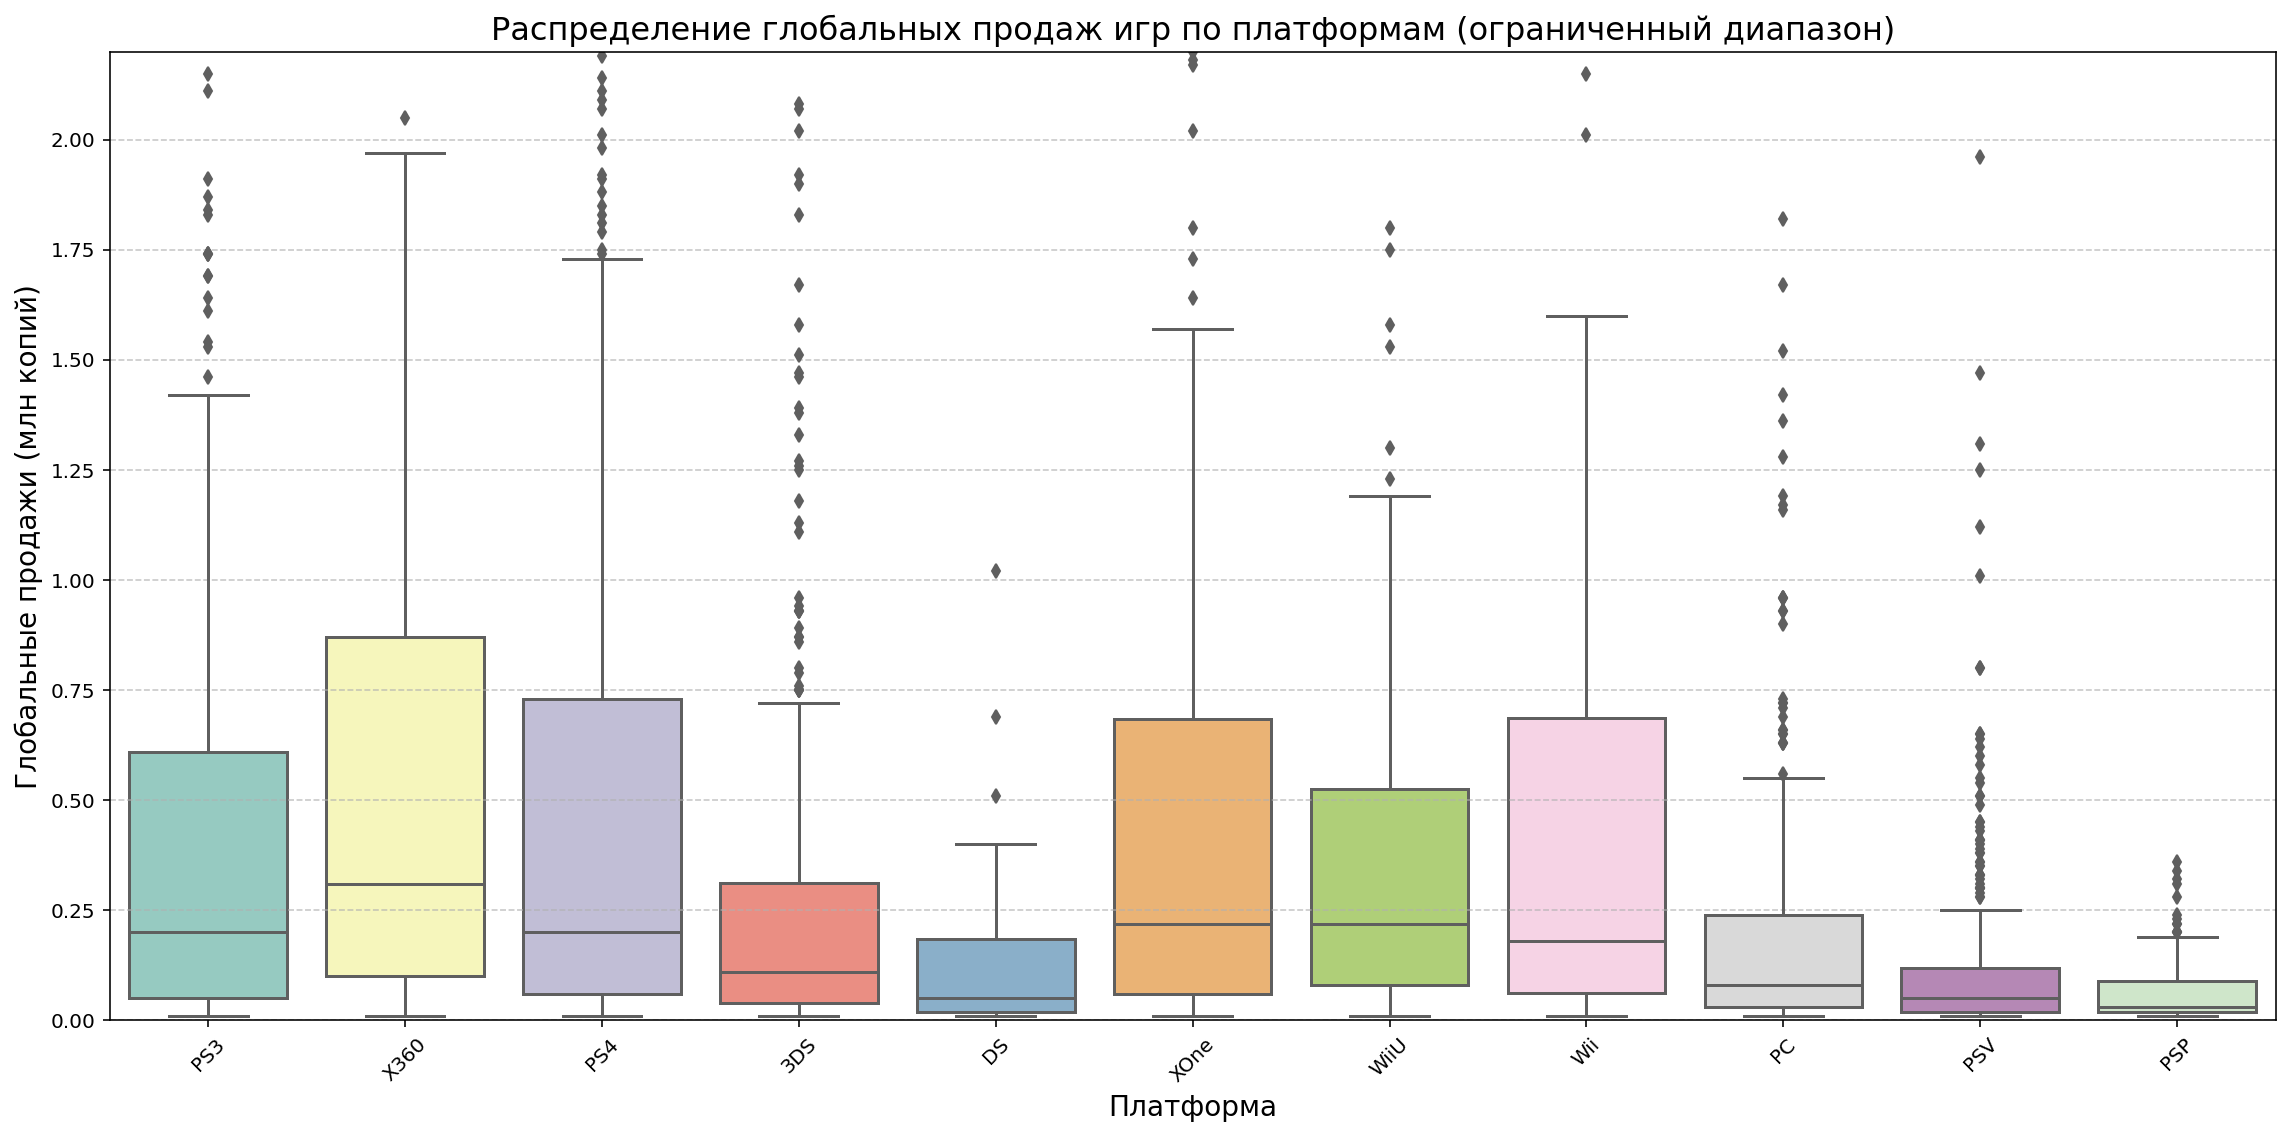

In [28]:
# Построение первого "ящика с усами" (полный диапазон данных)
plt.figure(figsize=(16, 8))
sns.boxplot(x='platform', y='total_sales', data=actual_period_data, palette='Set3')
plt.title('Распределение глобальных продаж игр по платформам (полный диапазон)', fontsize=16)
plt.xlabel('Платформа', fontsize=14)
plt.ylabel('Глобальные продажи (млн копий)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Построение второго "ящика с усами" (ограниченный диапазон Y-оси до 2.2)
plt.figure(figsize=(16, 8))
sns.boxplot(x='platform', y='total_sales', data=actual_period_data, palette='Set3')
plt.title('Распределение глобальных продаж игр по платформам (ограниченный диапазон)', fontsize=16)
plt.xlabel('Платформа', fontsize=14)
plt.ylabel('Глобальные продажи (млн копий)', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, 2.2)  # Ограничение Y-оси для исключения выбросов
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Улучшаем качество графика
%config InlineBackend.figure_format = 'retina'

По представленным графикам можно сделать следующие выводы:

**Первый график (полный диапазон)** отражает наличие значительных выбросов в данных по продажам для большинства платформ. Такие платформы, как `PS3`,`X360`, `PS4`, и `3DS` имеют высокие пиковые продажи отдельных игр, что может быть связано с популярностью хитов на этих платформах.

**Второй график (ограниченный диапазон)** лучше визуализирует основную массу данных, исключая влияние выбросов. Основные продажи большинства игр для каждой платформы находятся в диапазоне до 1,5–2 млн копий. Платформы `PS4`, `XOne`, и `WiiU` демонстрируют схожие медианы продаж, но меньший разброс, что указывает на более равномерные продажи игр.

#### Влияние на продажи внутри одной популярной платформы отзывов пользователей и критиков

Посмотрим, как влияют на продажи внутри одной популярной платформы (возьмем `PS4`) отзывы пользователей и критиков. Построим диаграмму рассеяния и посчитаем корреляцию между отзывами и продажами.

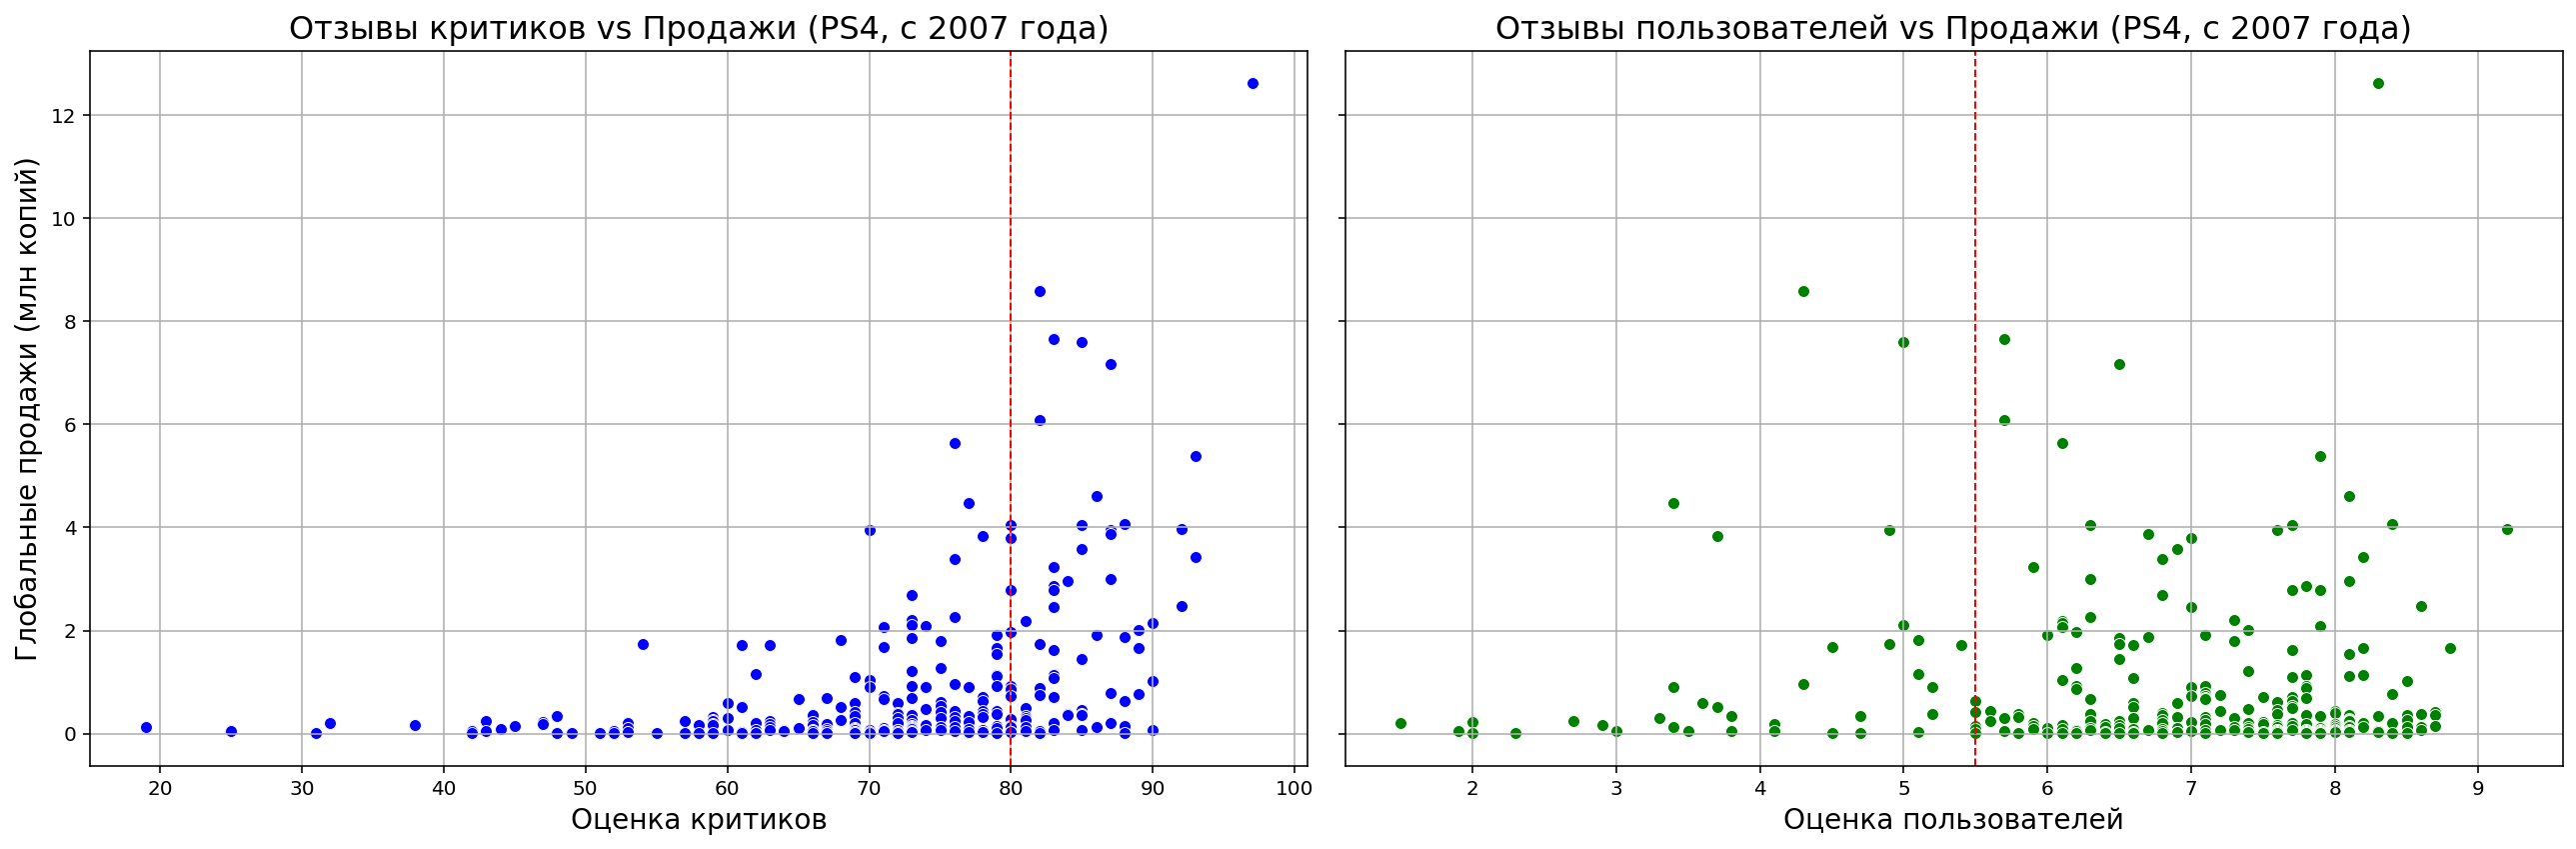

Корреляция между отзывами критиков и продажами: 0.41
Корреляция между отзывами пользователей и продажами: -0.03


In [29]:
# Фильтруем данные для платформы PS4 из актуального периода
ps4_data = actual_period_data[actual_period_data['platform'] == 'PS4']

# Фильтруем данные для анализа критиков
ps4_data_critic = ps4_data[ps4_data['critic_score'] != -1]

# Фильтруем данные для анализа пользователей
ps4_data_user = ps4_data[ps4_data['user_score'] != -1]

# Создаем фигуру с двумя графиками на одной линии
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Диаграмма рассеяния: отзывы критиков vs продажи
sns.scatterplot(
    data=ps4_data_critic, x='critic_score', y='total_sales', color='blue', ax=axes[0]
)
axes[0].axvline(x=80, color='red', linestyle='--', linewidth=1)  
axes[0].set_title('Отзывы критиков vs Продажи (PS4, с 2007 года)', fontsize=16)
axes[0].set_xlabel('Оценка критиков', fontsize=14)
axes[0].set_ylabel('Глобальные продажи (млн копий)', fontsize=14)
axes[0].grid(True)

# Диаграмма рассеяния: отзывы пользователей vs продажи
sns.scatterplot(
    data=ps4_data_user, x='user_score', y='total_sales', color='green', ax=axes[1]
)
axes[1].axvline(x=5.5, color='red', linestyle='--', linewidth=1)  
axes[1].set_title('Отзывы пользователей vs Продажи (PS4, с 2007 года)', fontsize=16)
axes[1].set_xlabel('Оценка пользователей', fontsize=14)
axes[1].grid(True)

# Настройка и отображение
plt.tight_layout()
plt.show()

# Расчет корреляции
critic_corr = ps4_data_critic['critic_score'].corr(ps4_data_critic['total_sales'])
user_corr = ps4_data_user['user_score'].corr(ps4_data_user['total_sales'])

print(f"Корреляция между отзывами критиков и продажами: {critic_corr:.2f}")
print(f"Корреляция между отзывами пользователей и продажами: {user_corr:.2f}")

На левом графике (оценки критиков) видно, что **игры с высокими оценками критиков** (выше 80) имеют тенденцию к более высоким продажам, особенно если оценки превышают этот порог.  

Корреляция составляет **0.41**, что указывает на умеренную положительную зависимость. Это означает, что высокие оценки критиков в целом положительно влияют на продажи игр на платформе PS4.  

На правом графике (оценки пользователей) заметна слабая связь между отзывами пользователей и продажами. При этом продажи становятся выше и плотнее после оценки в **5.5 баллов**.  

Однако коэффициент корреляции равен **-0.03**, что свидетельствует об отсутствии значимой зависимости. Это говорит о том, что оценки пользователей практически не влияют на продажи. Следовательно, **продажи зависят от множества других факторов**.  

Также на графиках можно заметить **выбросы** – игры с очень высокими продажами. Хотя такие игры часто имеют высокие оценки, их количество слишком мало, чтобы существенно повлиять на общую корреляцию.  

#### Соотнесение выводов с продажами игр на других платформах

Для соотнесения выводов с продажами игр на других платформах, построим диаграммы рассеяния и расчет корреляции по пяти другим платформам.

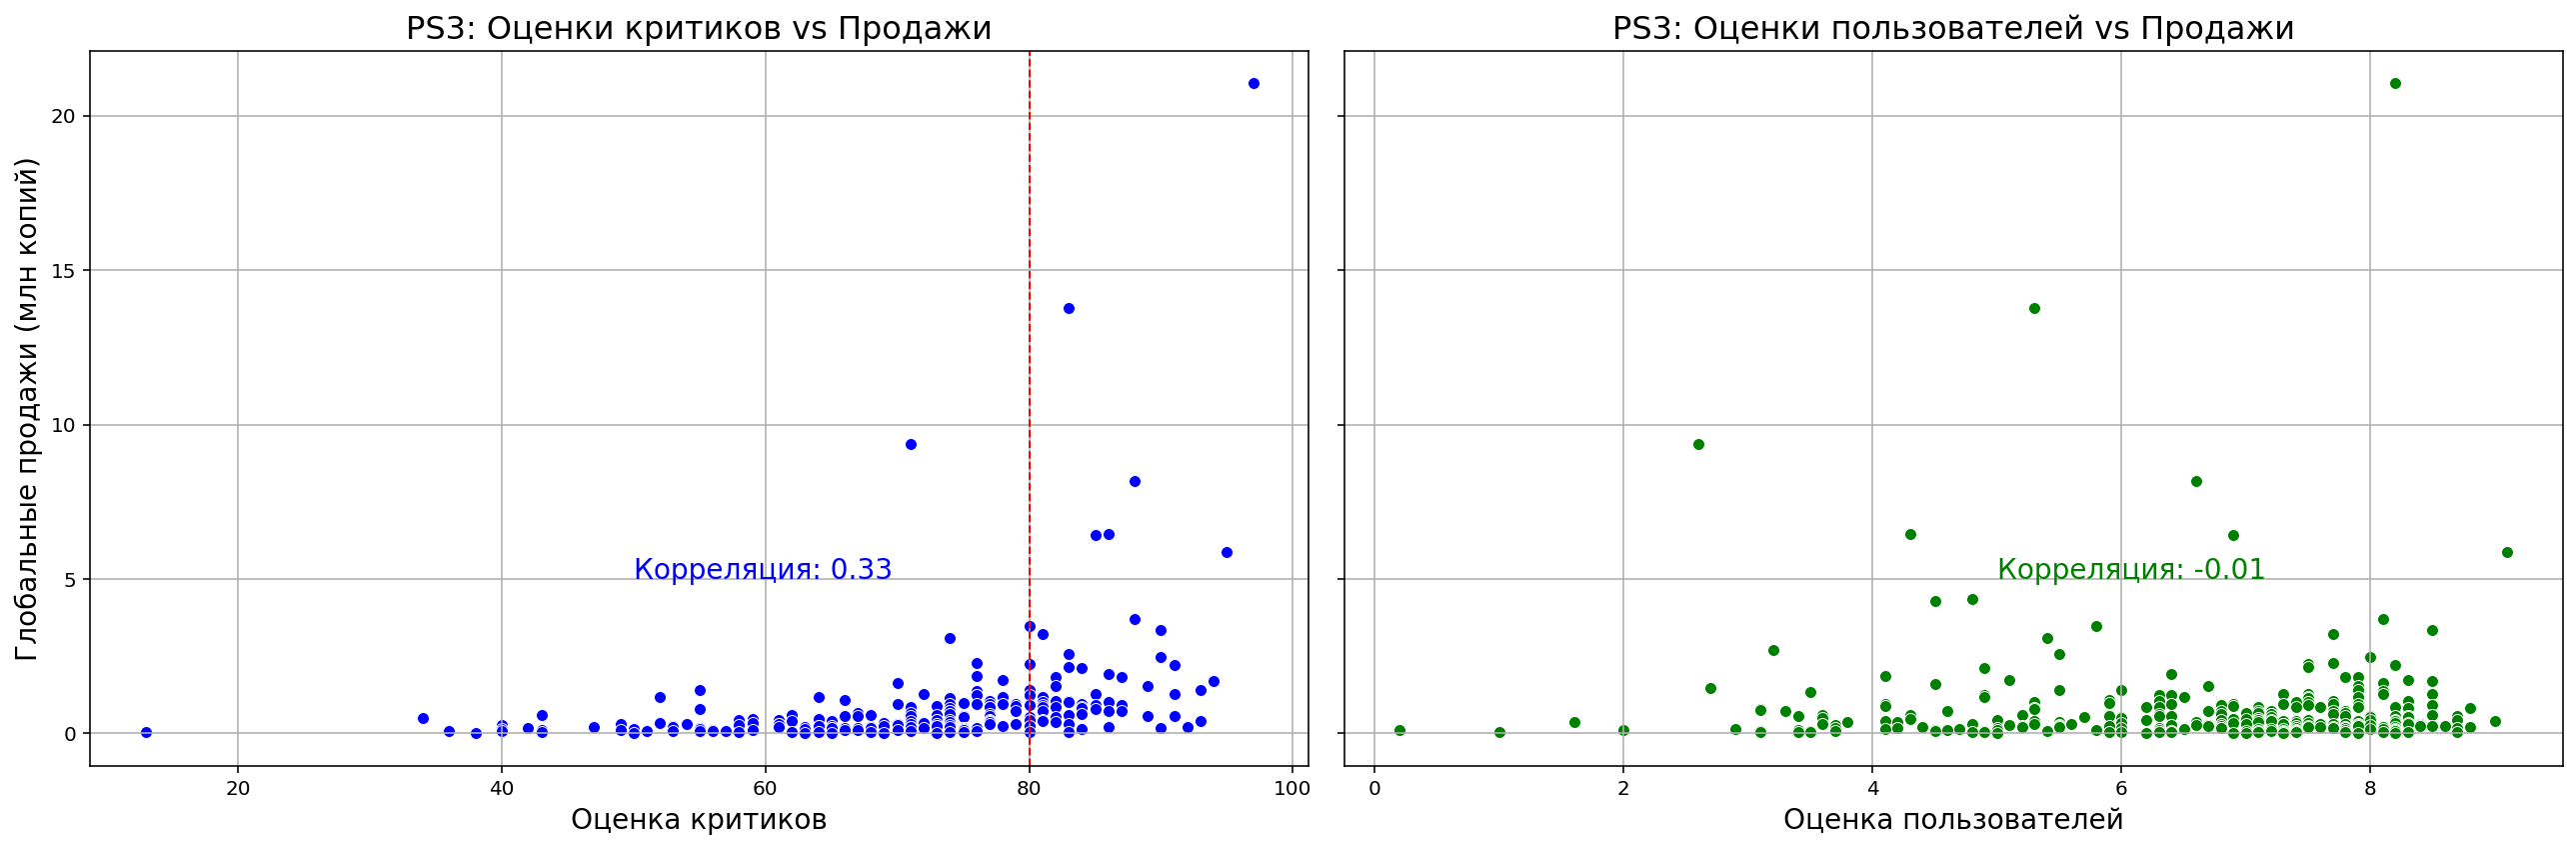

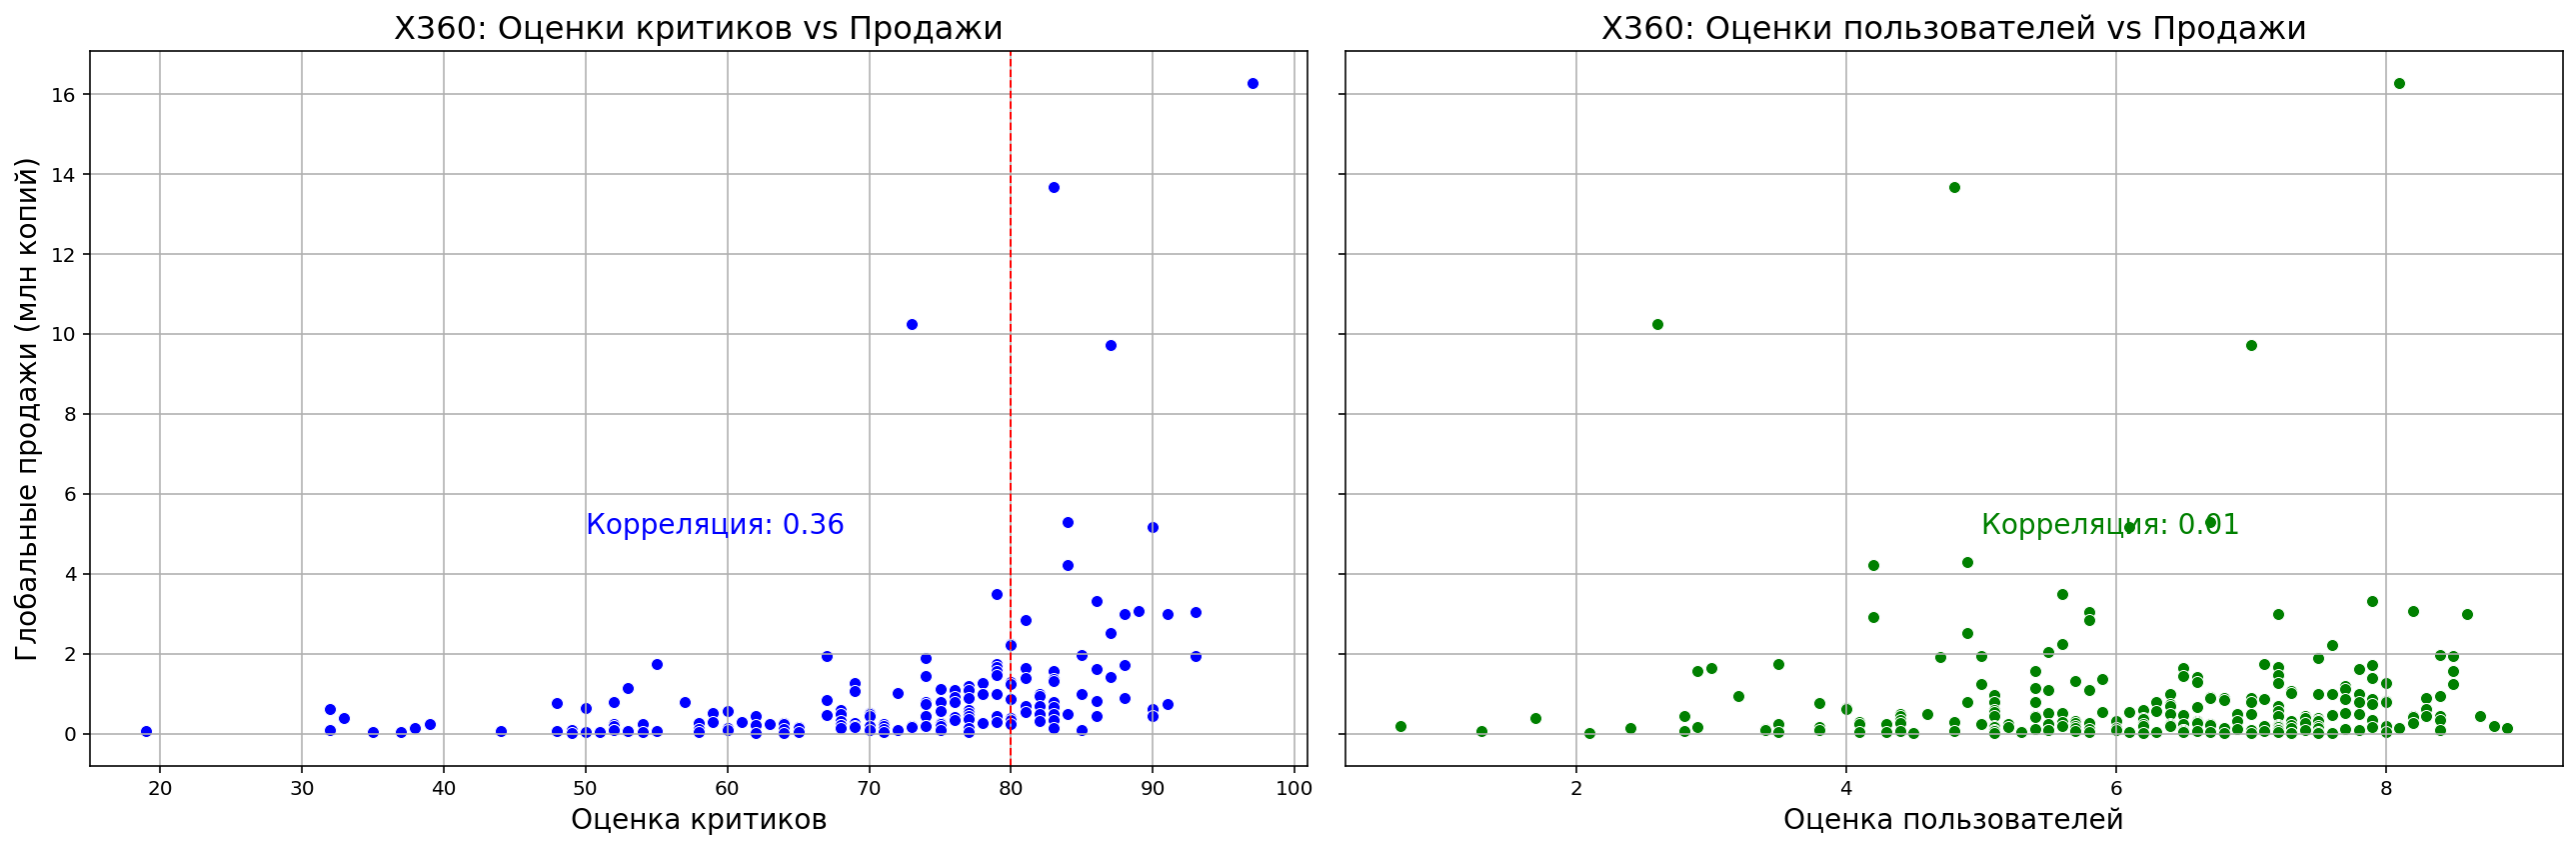

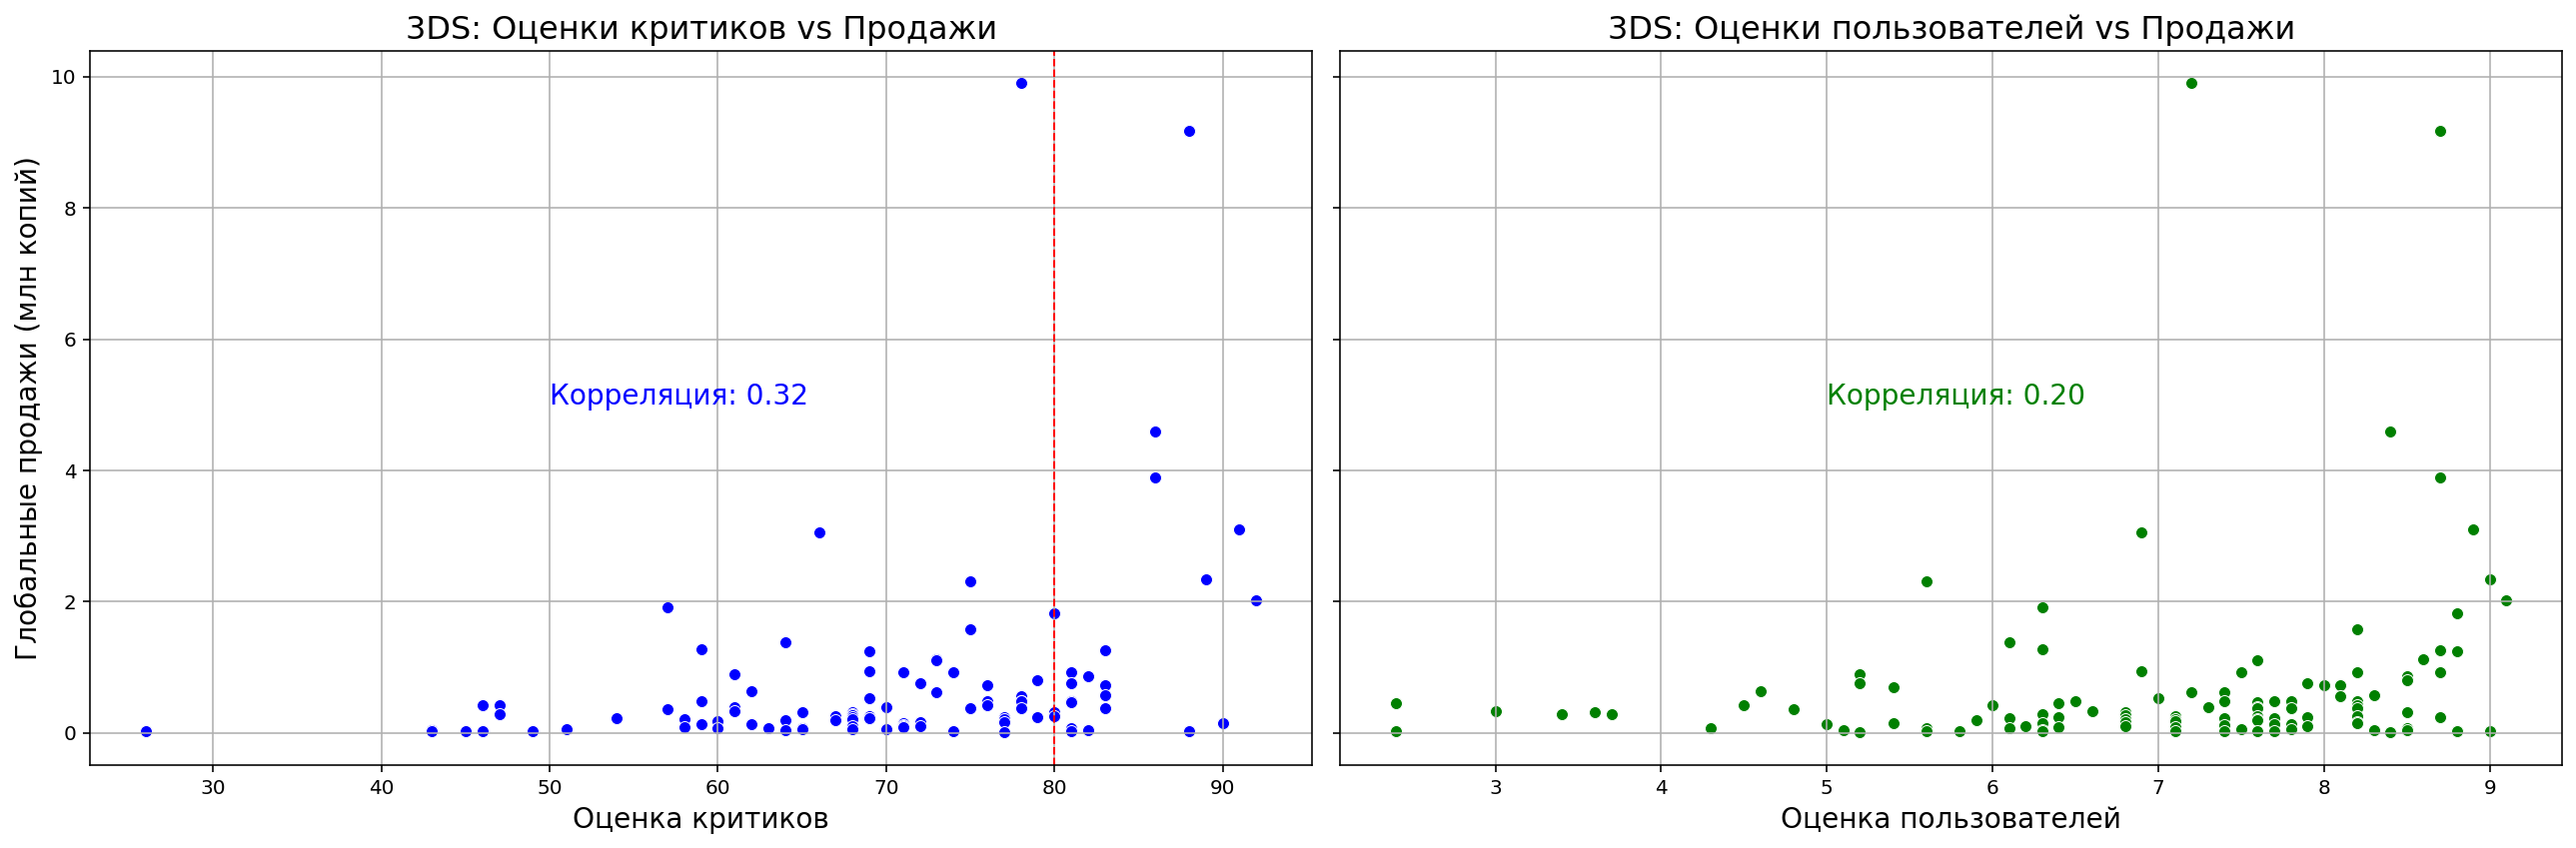

Недостаточно данных для платформы DS. Пропущено.


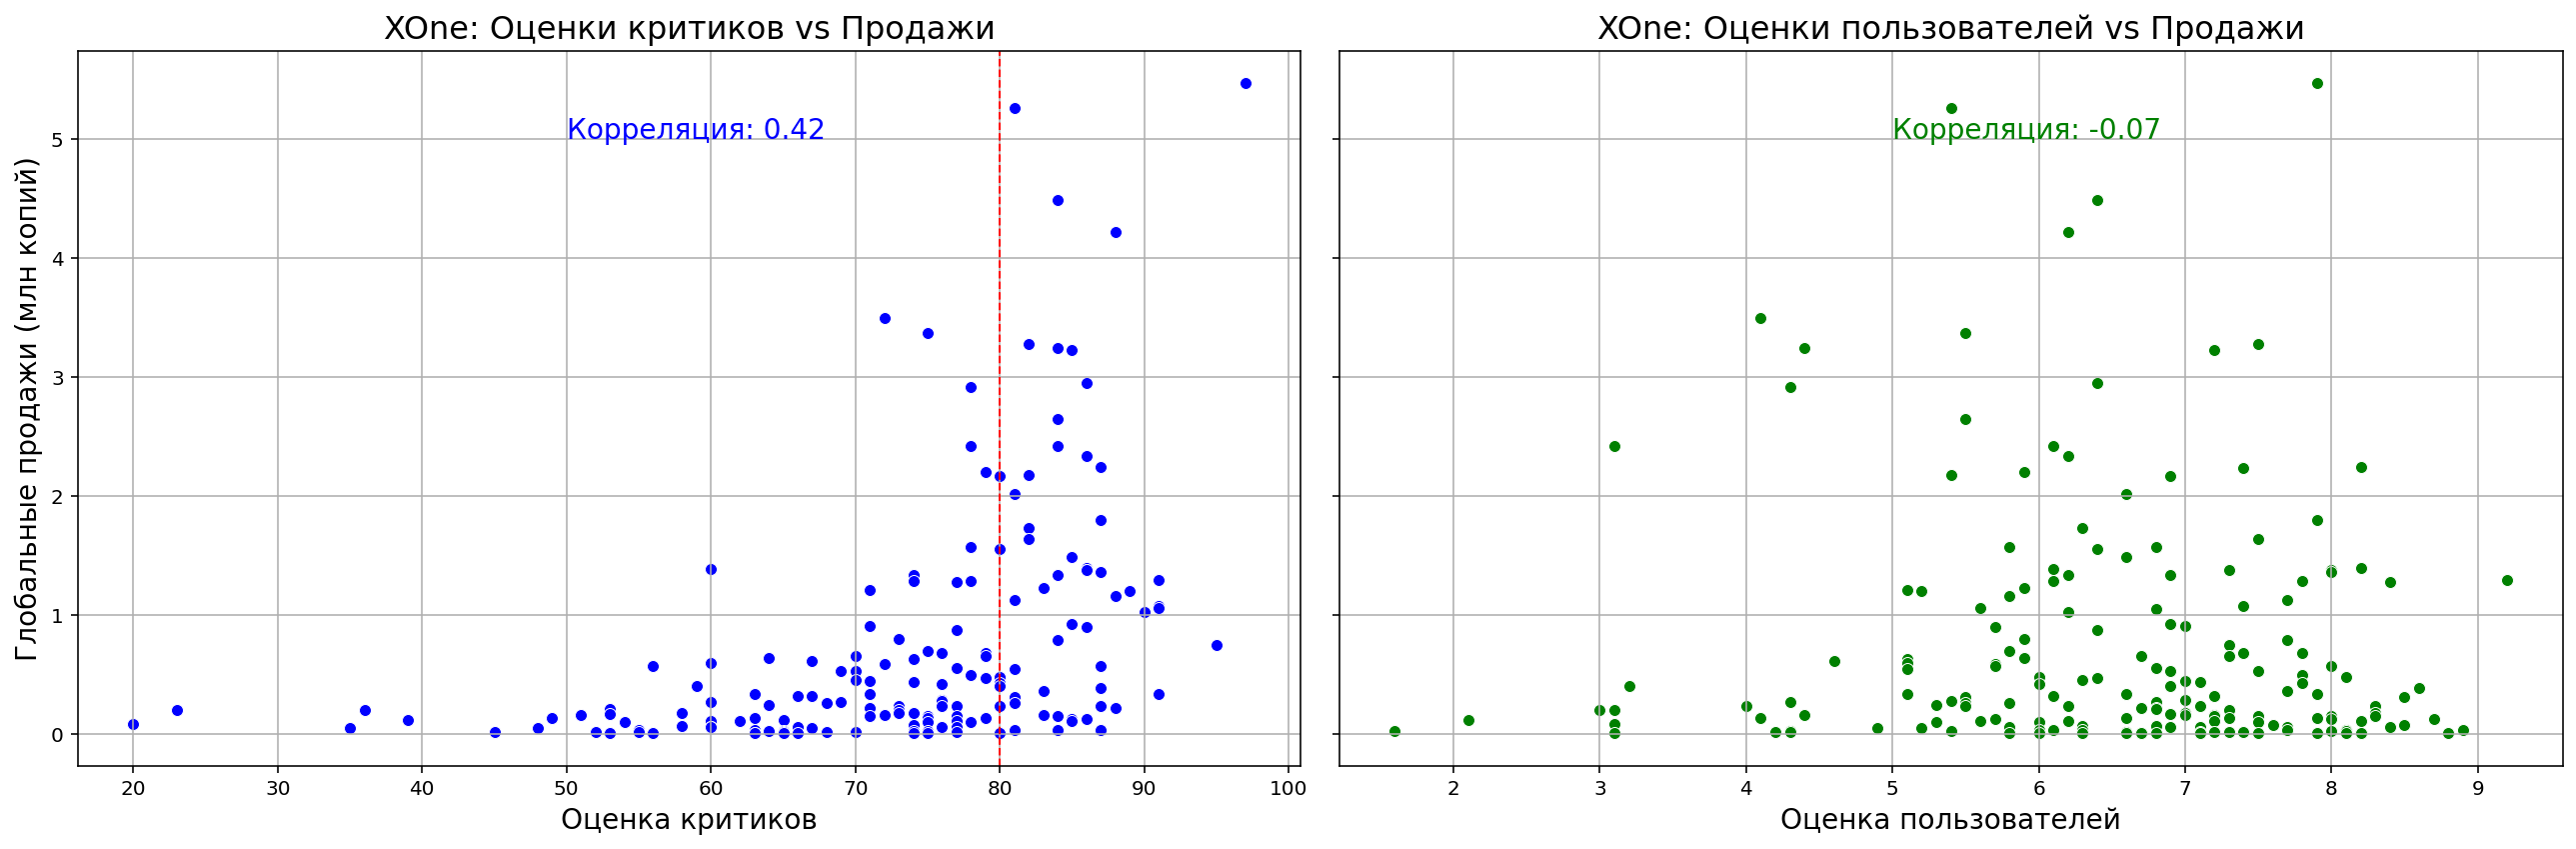

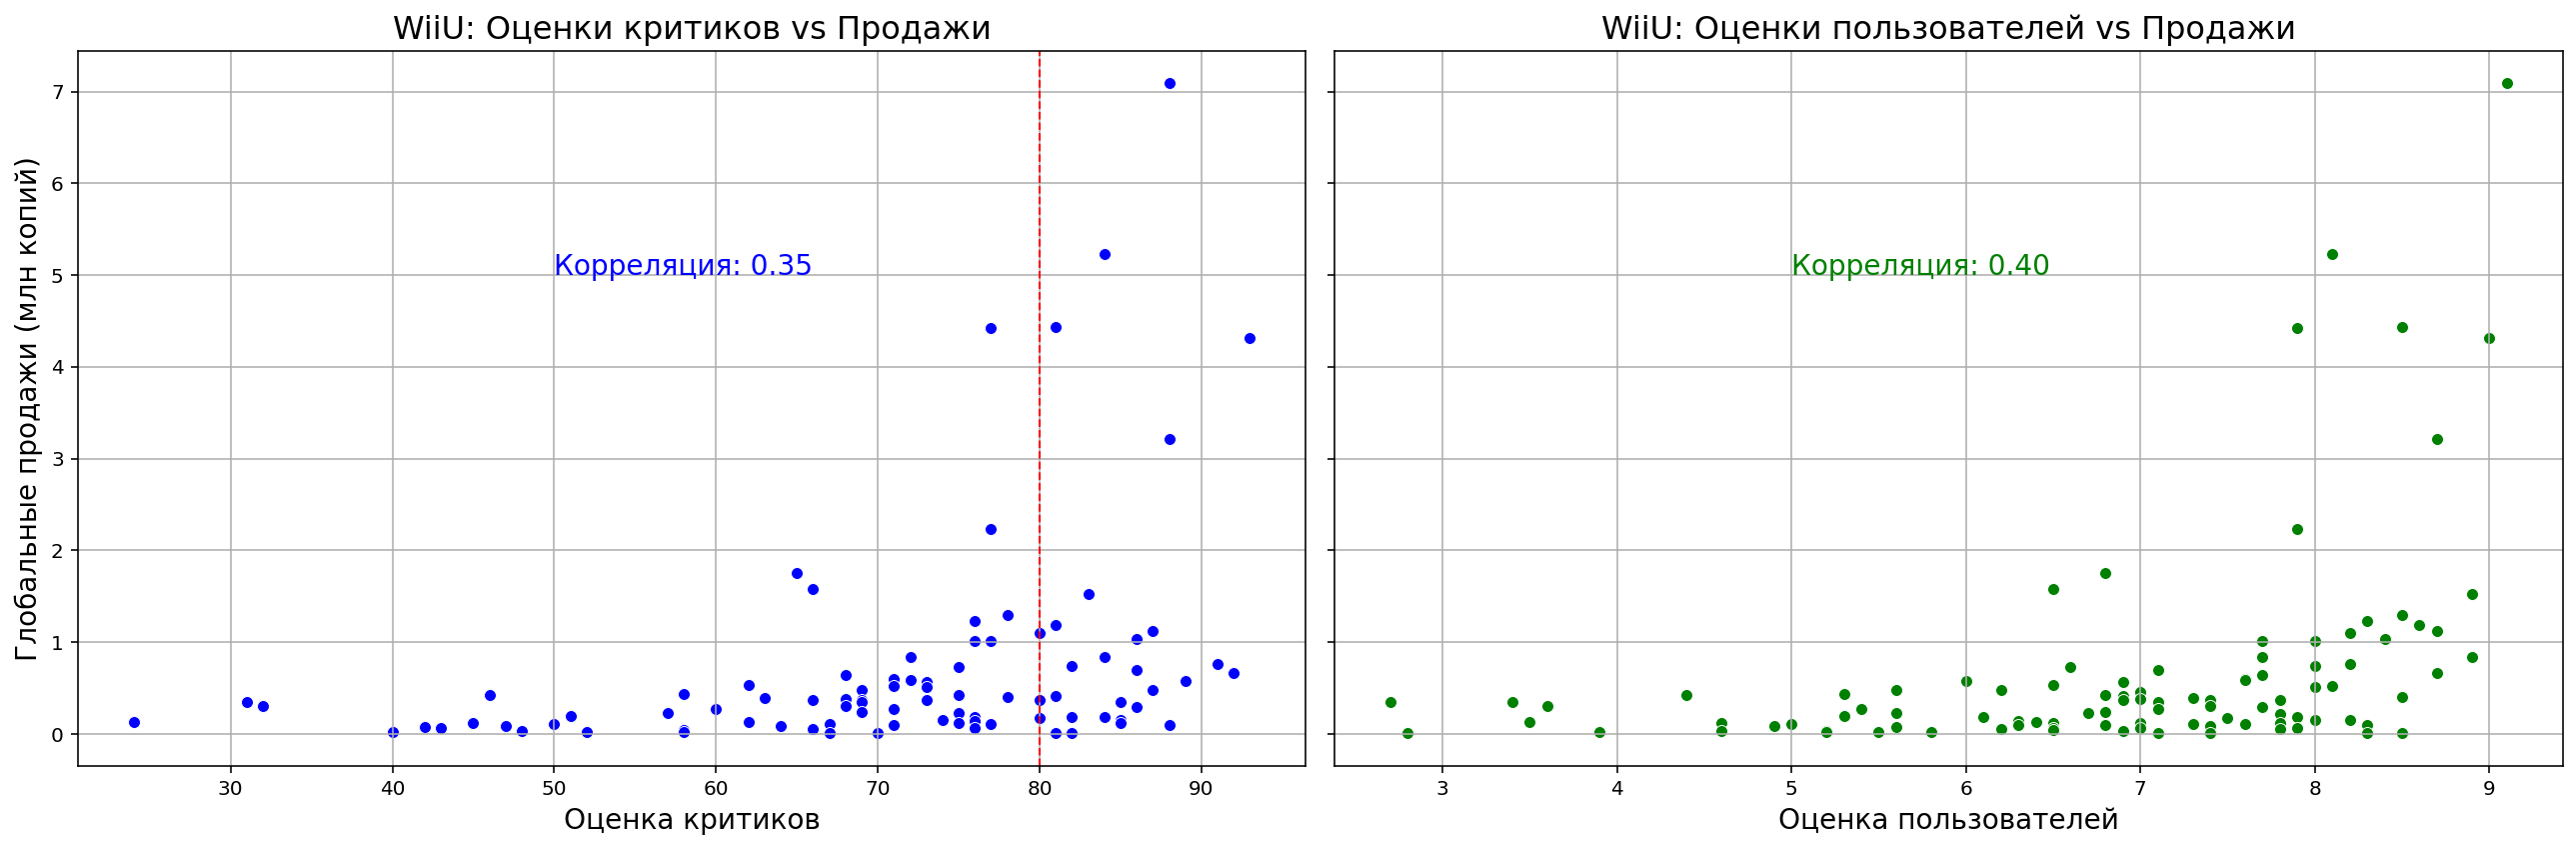

In [30]:
# Получаем список уникальных платформ из актуального периода
platforms = actual_period_data['platform'].unique()

# Фильтруем платформы, исключая PS4, т.к. уже анализировали эту платформу выше
filtered_platforms = [platform for platform in platforms if platform != 'PS4']

# Функция для построения графиков и расчета корреляции
def plot_correlation_for_platform(platform):
    # Фильтрация данных для текущей платформы и фильтрация заглушек
    platform_data_critic = actual_period_data[
        (actual_period_data['platform'] == platform) & 
        (actual_period_data['critic_score'] != -1)
    ]
    platform_data_user = actual_period_data[
        (actual_period_data['platform'] == platform) & 
        (actual_period_data['user_score'] != -1)
    ]
    
    # Проверка наличия достаточного количества данных, иначе выскакивает красная подсказка и график по платформе не строится
    if len(platform_data_critic) < 2 or len(platform_data_user) < 2:
        print(f"Недостаточно данных для платформы {platform}. Пропущено.")
        return False  # Указываем, что данные недостаточны
    
    # Расчет корреляции
    critic_corr = platform_data_critic['critic_score'].corr(platform_data_critic['total_sales'])
    user_corr = platform_data_user['user_score'].corr(platform_data_user['total_sales'])
    
    # Построение диаграмм рассеяния
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    
    # Отзывы критиков
    sns.scatterplot(data=platform_data_critic, x='critic_score', y='total_sales', color='blue', ax=axes[0])
    axes[0].axvline(x=80, color='red', linestyle='--', linewidth=1)
    axes[0].set_title(f'{platform}: Оценки критиков vs Продажи', fontsize=16)
    axes[0].set_xlabel('Оценка критиков', fontsize=14)
    axes[0].set_ylabel('Глобальные продажи (млн копий)', fontsize=14)
    axes[0].grid(True)
    axes[0].text(50, 5, f"Корреляция: {critic_corr:.2f}", fontsize=14, color='blue')
    
    # Отзывы пользователей
    sns.scatterplot(data=platform_data_user, x='user_score', y='total_sales', color='green', ax=axes[1])
    axes[1].set_title(f'{platform}: Оценки пользователей vs Продажи', fontsize=16)
    axes[1].set_xlabel('Оценка пользователей', fontsize=14)
    axes[1].grid(True)
    axes[1].text(5, 5, f"Корреляция: {user_corr:.2f}", fontsize=14, color='green')
    
    # Отображение
    plt.tight_layout()
    plt.show()
    return True  # Указываем, что данные достаточны

# Анализируем пять платформ
analyzed_platforms = 0
for platform in filtered_platforms:
    if plot_correlation_for_platform(platform):
        analyzed_platforms += 1
    if analyzed_platforms >= 5:
        break

Сравнивая результаты, полученные при анализе платформы `PS4` и остальные платформы (брали 5: `PS3`, `X360`, `3DS`, `XOne` и `WiiU`), можно выделить несколько общих тенденций и различий:

**Общие моменты:**
1. ***Положительная корреляция с отзывами критиков***:
   - На `PS4` корреляция между оценками критиков и продажами составляет **0.41**, что говорит о умеренной зависимости.
   - Для других платформ (например, `XOne`, `X360` и `WiiU`) также наблюдается положительная корреляция с отзывами критиков, хотя она может быть чуть ниже, например,**0.42** на `XOne`, **0.36** на `X360` и **0.35** на `WiiU`. Это подтверждает, что высокие оценки критиков часто способствуют росту продаж.

2. ***Слабая или отсутствующая корреляция с отзывами пользователей***:
   - На `PS4` корреляция между отзывами пользователей и продажами составляет **-0.03**, что говорит об отсутствии значимой зависимости.
   - Для других платформ значения корреляции с отзывами пользователей аналогично близки к нулю (например, **-0.01** на `PS3`,  **0.01** на `X360`, **-0.07** на `XOne`), что указывает на незначительное влияние мнения пользователей на продажи.  Однако, имеется положительная корреляция у платформы `WiiU` (0.40) и `3DS` (0.20). Но здесь стоит обратить внимение на наличие выбросов.

**Различия:**
1. ***Величина выбросов***:
   - На `PS4` заметны сильные выбросы в данных (игры с очень высокими продажами), что также наблюдается на других популярных платформах, например, `WiiU` и `3DS` (говорили об этом в предыдущем пункте). Однако их количество и уровень продаж могут отличаться в зависимости от платформы.

2. ***Порог критических оценок***:
   - Для `PS4` заметен порог в `80 баллов`, после которого продажи игр резко увеличиваются. Но на других платформах порог критических оценок также может быть значимым, но он не всегда столь четко выражен, как на `PS4`. Например, у `3DS`, `WiiU`, `XOne`.

В целом, влияние отзывов критиков на продажи прослеживается на всех платформах, хотя его уровень может варьироваться. При этом отзывы пользователей имеют слабое влияние на продажи как на PS4, так и на других платформах. Это свидетельствует **о схожести тенденций в игровой индустрии вне зависимости от платформы**.

Дополнительно к диаграмм рассеяния и расчету корреляции создадим еще **матрицу корреляции** за актуальный период по всем показателям и посмотрим на зависимость  `total_sales` от `critic_score` и `user_score` (исключая из расчета заглушки с `-1`).

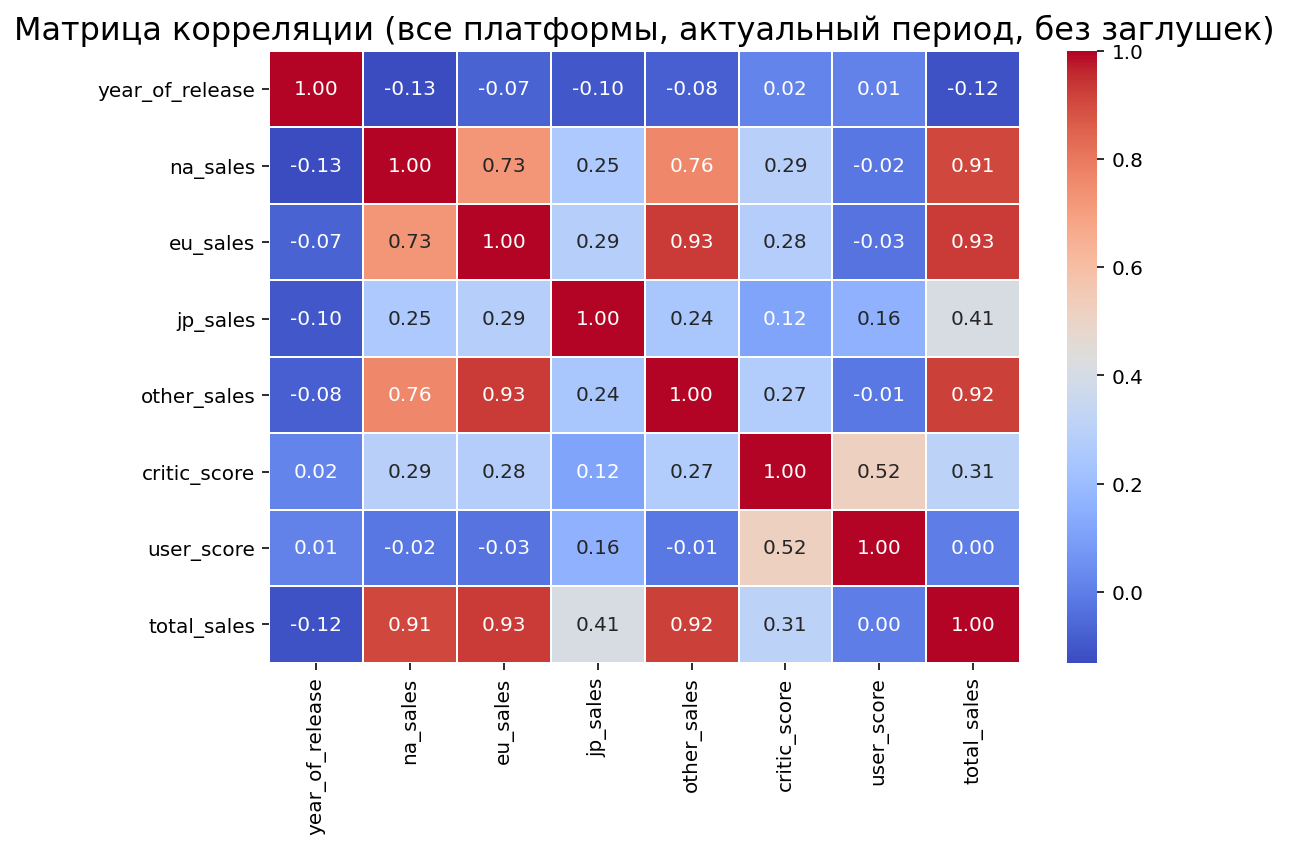

In [31]:
# Фильтруем данные: исключаем строки с заглушками в critic_score и user_score
filtered_data = actual_period_data[
    (actual_period_data['critic_score'] != -1) & 
    (actual_period_data['user_score'] != -1)
]

# Проверяем, что данные для расчета корреляции не пусты
if not filtered_data.empty:
    # Вычисляем корреляционную матрицу для отфильтрованных данных
    corr_matrix_filtered = filtered_data.corr()

    # Построение тепловой карты корреляций
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix_filtered, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Матрица корреляции (все платформы, актуальный период, без заглушек)', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Данные для построения корреляционной матрицы отсутствуют.")

Матрица корреляции демонстрирует следующие результаты:

1. **Связь между продажами и оценками критиков** (`total_sales` и `critic_score`): коэффициент корреляции **0.31** указывает на **слабую положительную связь**. Это означает, что более высокие оценки критиков могут незначительно способствовать увеличению продаж, но зависимость не является сильной.

2. **Связь между продажами и отзывами пользователей** (`total_sales` и `user_score`): коэффициент корреляции **0.00** указывает на **отсутствие зависимости между продажами и отзывами пользователей**. Это свидетельствует о том, что мнение пользователей практически не влияет на объемы продаж.

3. **Связь между оценками критиков и отзывами пользователей** (`critic_score` и `user_score`): коэффициент корреляции **0.52** демонстрирует **умеренную положительную связь**. Это говорит о том, что мнения критиков и пользователей часто совпадают, но далеко не всегда.

Следовательно, продажи игр оказываются более зависимыми от оценок критиков, чем от отзывов пользователей, однако даже влияние критиков не является решающим. Следовательно, можно предположить, что на продажи игр влияют и другие факторы, такие как рекламные кампании, популярность франшизы и тренды в игровой индустрии.

#### Анализ распределения игр по жанрам и их прибыльности

Посмотрим на общее распределение игр по жанрам. Сравним медианные продажи с общими по жанрам на основании графиков.

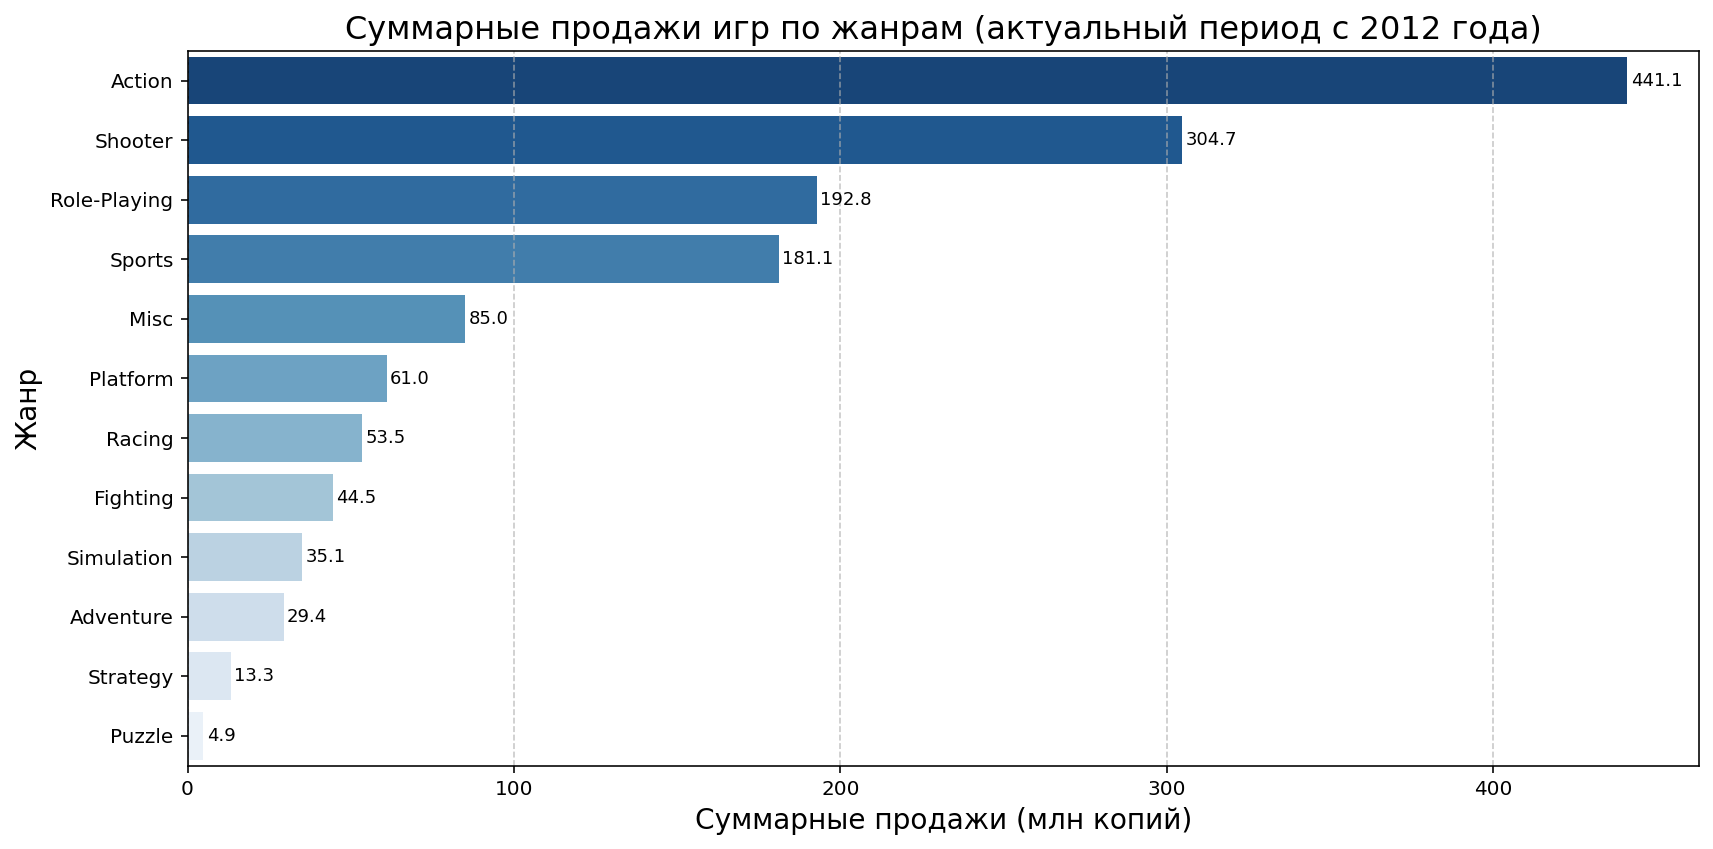

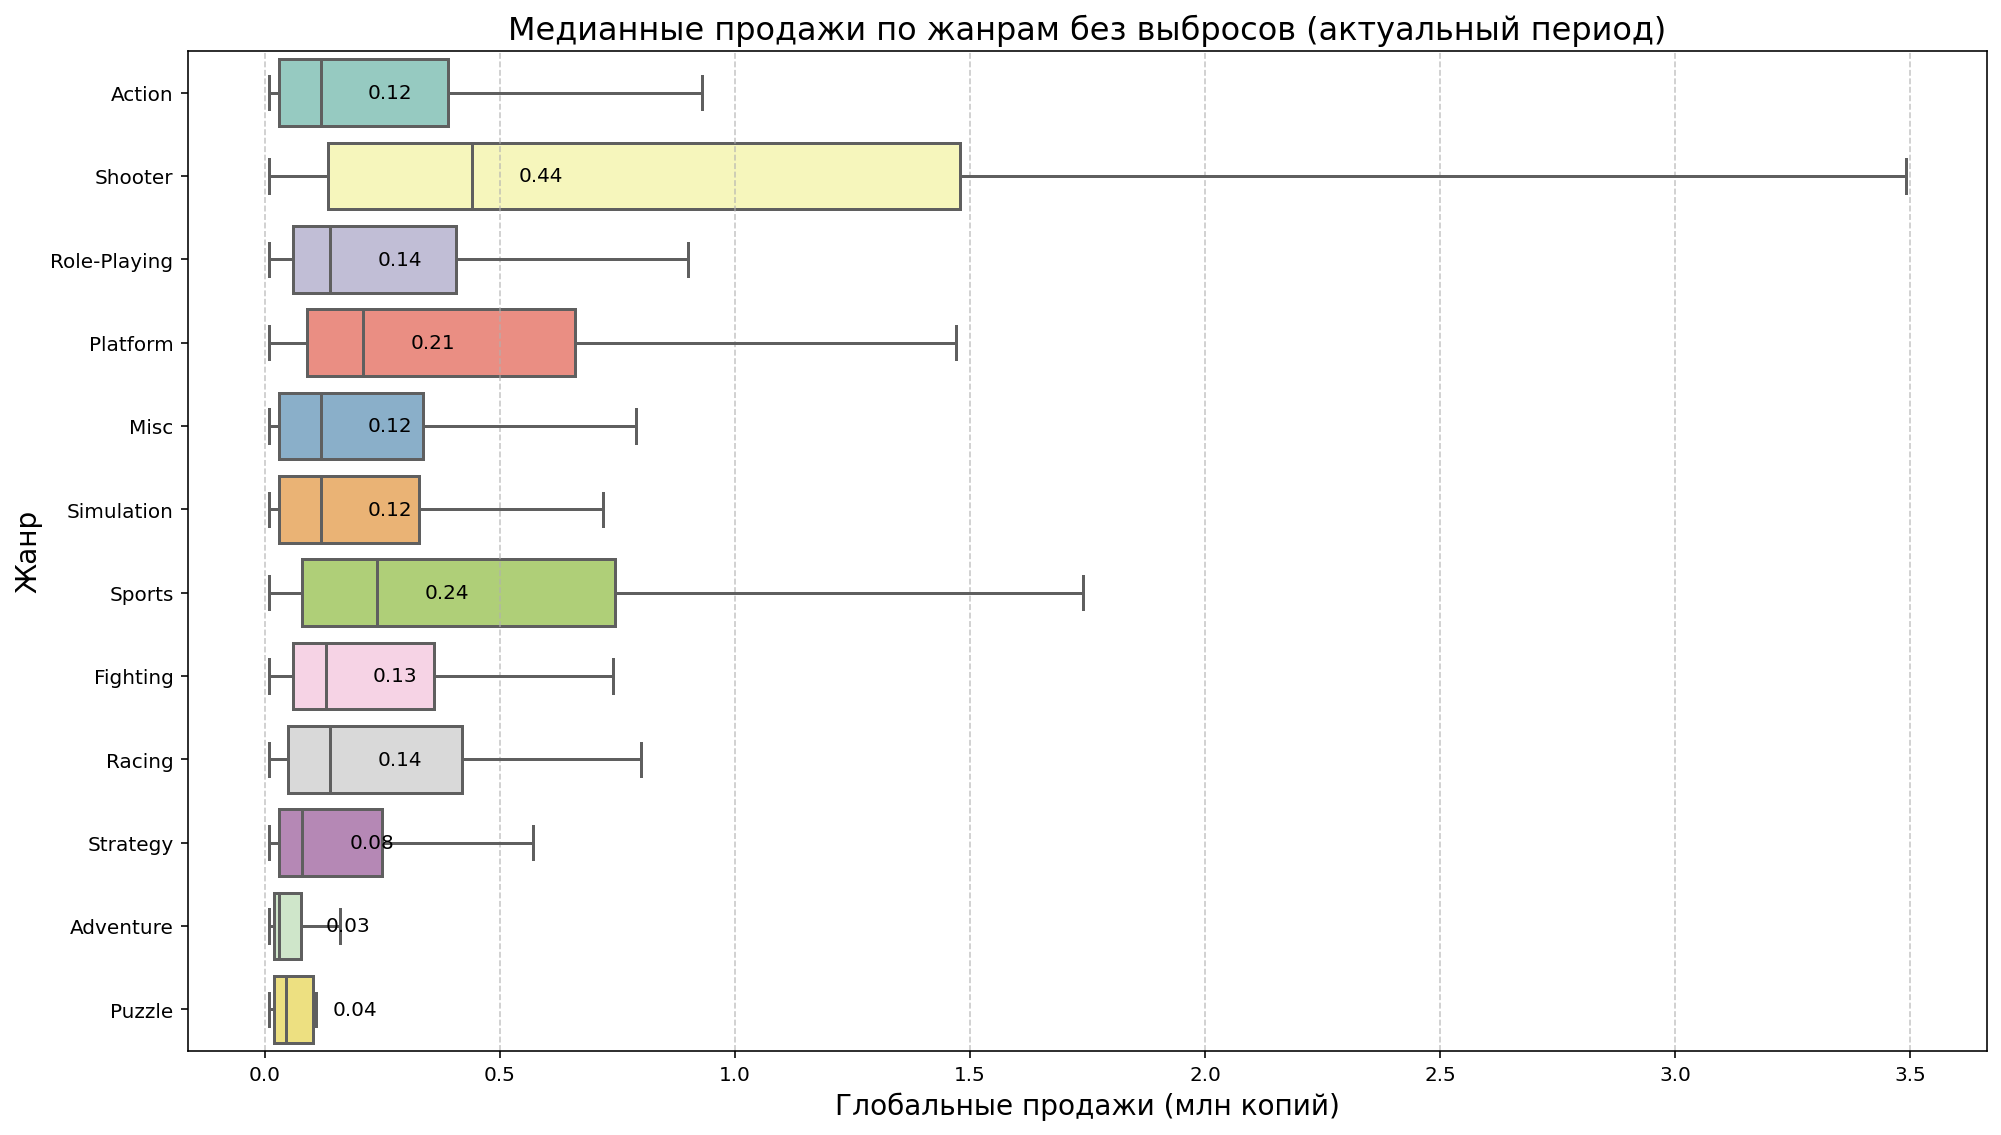

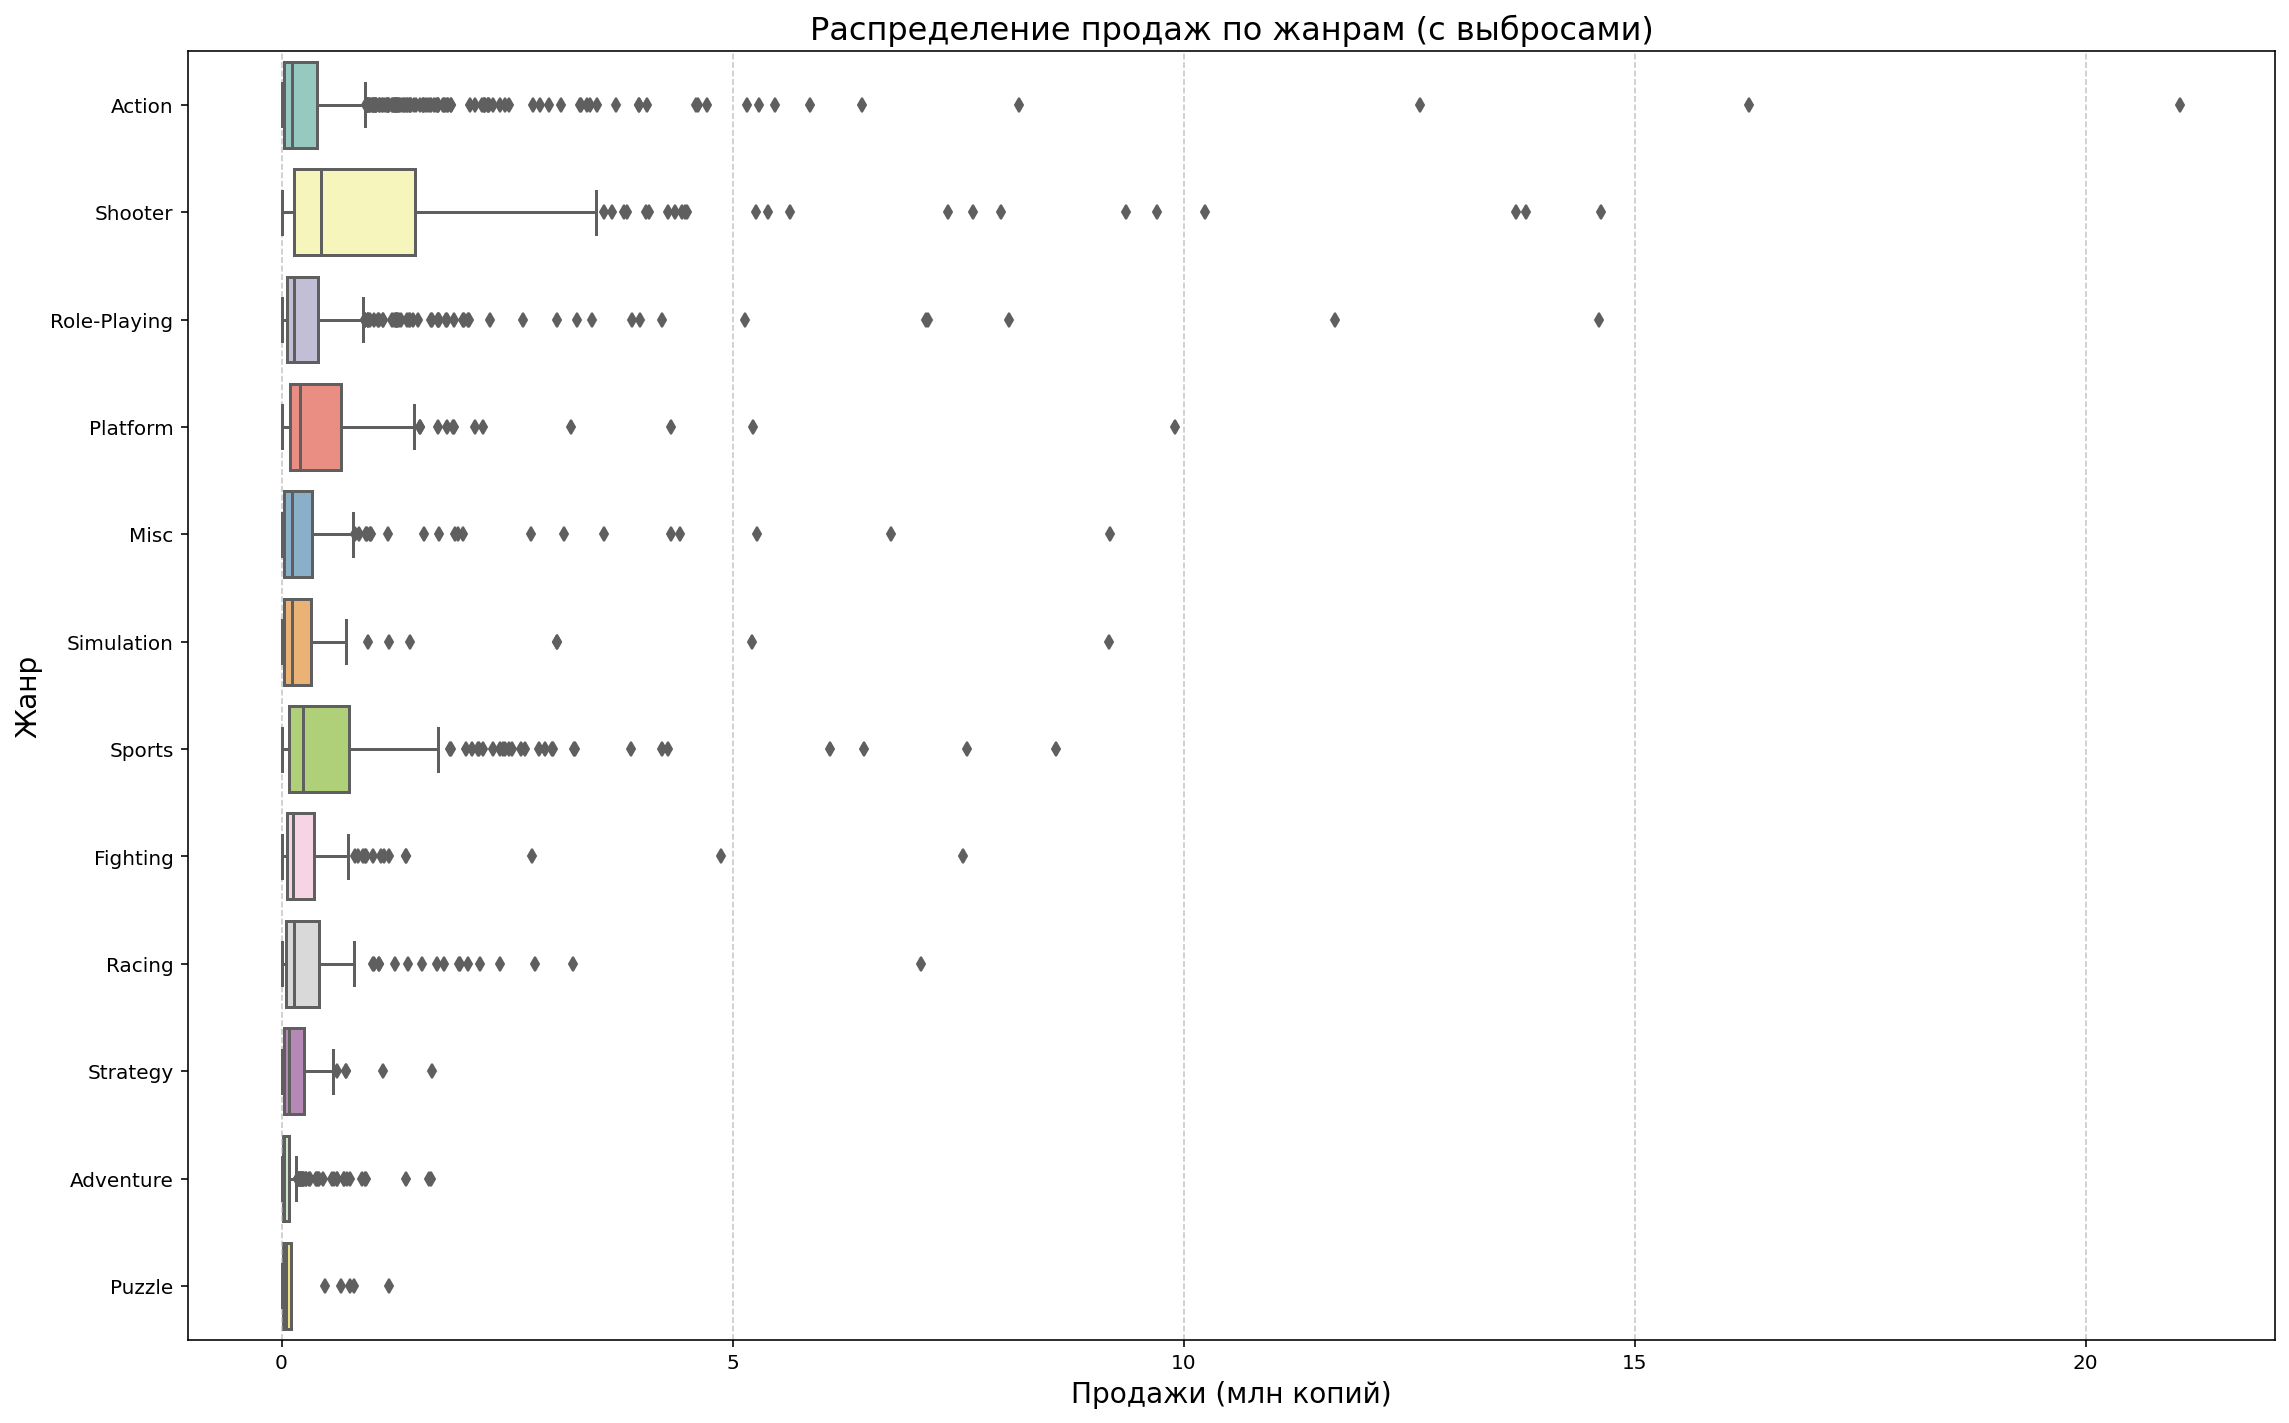

In [32]:
# Группировка данных по жанрам для суммарных продаж
genre_sales = actual_period_data.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# Построение графика суммарных продаж
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sales.values, y=genre_sales.index, palette='Blues_r')

# Подписи данных на графике
for index, value in enumerate(genre_sales.values):
    plt.text(value + 1, index, f'{value:.1f}', color='black', fontsize=9, va='center')

# Настройка графика
plt.title('Суммарные продажи игр по жанрам (актуальный период с 2012 года)', fontsize=16)
plt.xlabel('Суммарные продажи (млн копий)', fontsize=14)
plt.ylabel('Жанр', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Построение диаграммы размаха без выбросов и добавление медиан
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=actual_period_data, 
    x='total_sales', 
    y='genre', 
    showfliers=False, 
    palette='Set3'
)

# Добавление подписей медиан
for i, genre in enumerate(actual_period_data['genre'].unique()):
    median_value = actual_period_data[actual_period_data['genre'] == genre]['total_sales'].median()
    plt.text(median_value + 0.1, i, f'{median_value:.2f}', 
             color='black', fontsize=10, va='center')

# Настройка графика
plt.title('Медианные продажи по жанрам без выбросов (актуальный период)', fontsize=16)
plt.xlabel('Глобальные продажи (млн копий)', fontsize=14)
plt.ylabel('Жанр', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Диаграммы размаха с выбросами
plt.figure(figsize=(16, 10))
sns.boxplot(data=actual_period_data, x='total_sales', y='genre', palette='Set3', showfliers=True)

# Настройка графика
plt.title('Распределение продаж по жанрам (с выбросами)', fontsize=16)
plt.xlabel('Продажи (млн копий)', fontsize=14)
plt.ylabel('Жанр', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Жанры с высокими **суммарными продажами**, такие как **Action**, **Shooter**, **Role-Playing** и **Sports**, выделяются на графике с барплотом. Имеют суммарные продажи в размере более **180 млн. копий** за актуальный период. **Action** имеет максимальные суммарные продажи (**441.1 млн. копий**), что может быть связано с большим количеством игр в этом жанре.

Для прибыльности, однако, нужны стабильные жанры, которые приносят доход независимо от платформы. Поэтому, важно обращать внимание на **медианные продажи**, они дают более точное представление о стабильности спроса в жанре, так как не зависят от выбросов. Анализируя "ящики с усами", можно сказать, что жанр **Shooter** демонстрирует самые высокие медианные продажи (440 тыс. копий), что говорит о том, что большинство игр в этом жанре продаются хорошо, а не только отдельные хиты. Жанры **Sports**  и **Platform** также имеют высокие медианные продажи (240 тыс.копий и 210 тыс.копий соответственно), что указывает на стабильный интерес к играм этих жанров.

И если сравнивать платформы по суммарным и медианным продажам, то можно увидеть дисбаланс между ними. У **Action** и **Role-Playing** наблюдается большой разрыв между медианными и суммарными продажами, что говорит о значительном количестве игр, продающихся небольшими тиражами, и о том, что общие продажи "тянут" успешные проекты.

В жанрах **Puzzle** и **Adventure** медианные продажи очень низкие, как и суммарные продажи, несмотря на отдельные выбросы, что подтверждает слабый и нестабильный спрос.

**Вывод:** 

Жанры **Shooter** и **Sports** наиболее перспективны, так как сочетают высокие медианные и суммарные продажи.

**Action** и **Role-Playing** имеют высокие суммарные продажи, но их медиана указывает на менее стабильный спрос. 

Жанры с низкими суммарными и медианными продажами, такие как **Puzzle** и **Adventure**, менее привлекательны для инвестиций, несмотря на редкие успешные игры.

#### Вывод по разделу  

В данном разделе проведен исследовательский анализ данных, в результате которого сформулированы ключевые выводы и наблюдения.  

1. **Анализ количества выпускаемых игр по годам**  

На этом этапе был проанализирован объем выпускаемых игр в разные годы и оценена значимость данных за различные временные периоды.  

*Наблюдения:*  
- с 1995 года в игровой индустрии наблюдается устойчивый рост количества выпущенных игр, который достигает пика в период 2006–2009 годов;
- данные до 2000 года имеют меньшую ценность для анализа, так как индустрия игр и предпочтения пользователей существенно изменились;
- для планирования продаж в 2017 году рекомендуется сосредоточиться на данных за период с 2000 по 2016 годы, поскольку они более релевантны современным платформам и жанрам.  

2. **Анализ продаж по платформам**  

На этом этапе рассмотрены суммарные продажи по платформам за весь период.  

*Наблюдения:*  
- лидерами по суммарным продажам являются такие платформы, как PS2, X360, PS3, Wii, DS и PS;
- однако анализировать только эти платформы недостаточно, так как на 2016 год значительную роль начали играть новые, развивающиеся платформы (PS4, XOne, 3DS);
- для анализа продаж по платформам были взяты все платформы без формирования топового списка и выбран период с 2000 года.  

*Итоги:*  
Анализ продаж показал, что платформа достигает пика продаж через 2–3 года после выхода, а затем постепенно теряет популярность. Жизненный цикл платформ составляет в среднем 7,5 лет (определен расчетным путем). 
 
Однако, для прогнозирования в такой динамично развивающейся индустрии, как компьютерные игры, не следует использовать слишком большой временной интервал. Это может привести к учёту уже устаревших трендов. Поэтому, рекомендуется брать данные за последние **2-5 лет** (включая 2016 год), поскольку это позволяет учитывать актуальные тенденции.

Таким образом, актуальным периодом для анализа и прогнозирования установлен период в последние 5 лет, начиная с 2012 года. 

3. **Анализ платформ по продажам** 
На этом этапе рассмотрены платформы с самыми высокими суммарными продажами за весь актуальный период. 

*Наблюдения:*
- лидерами по продажам являются PS3 (910.38 млн копий), X360 (901.43 млн копий) и Wii (754.75 млн копий). Минимальные продажи у XOne (159.32 млн копий);
- однако популярность лидеров продаж снижается из-за завершения жизненного цикла;
- растущими платформами остаются PS4 (314.14 млн копий), XOne (159.32 млн копий) и 3DS (257.81 млн копий), которые имеют высокий потенциал для увеличения продаж.

Для прогнозирования на 2017 год стоит сосредоточиться на PS4, XOne и 3DS как на наиболее перспективных платформах.

4. **«Ящик с усами» по глобальным продажам игр в разбивке по платформам**
На этом этапе построили 2 графика «ящик с усами» по глобальным продажам игр в разбивке по платформам (со всеми максимумами продаж за актуальный период и с масштабированными данными).

*Наблюдения:*
- график с полным диапазоном показал наличие значительных выбросов в данных по продажам для большинства платформ. Такие платформы, как PS3,X360, PS4, и 3DS имеют высокие пиковые продажи отдельных игр, что может быть связано с популярностью хитов на этих платформах;
- график с ограниченным диапазоном лучше визуализирует основную массу данных, исключая влияние выбросов. Основные продажи большинства игр для каждой платформы находятся в диапазоне до 1,5–2 млн копий. Платформы PS4, XOne, и WiiU демонстрируют схожие медианы продаж, но меньший разброс, что указывает на более равномерные продажи игр.

3. **Влияние оценок на продажи игр**  
На этом этапе сначала было рассмотрено, как влияют на продажи внутри одной популярной платформы (возьмем PS4) отзывы пользователей и критиков. А затем произведено сравнение результатов с пятью другими рандомными платформами.

*Наюлюдения:*

PS4:  
- умеренная положительная корреляция между оценками критиков и продажами (0.41);  
- отсутствие значимой корреляции между оценками пользователей и продажами (-0.03);
- выбросы (игры с крайне высокими продажами) слабо влияют на общий результат.  

Другие платформы:
- анализ пяти платформ подтвердил схожую тенденцию: оценки критиков имеют большее влияние на продажи, чем отзывы пользователей; 
- матрица корреляции показала, что связь между отзывами критиков и продажами умеренная (0.31), а между отзывами пользователей и продажами отсутствует (0.00).  

4. **Распределение игр по жанрам** 

Сравнение суммарных и медианных продаж по жанрам выявило следующее:  
- Жанры Shooter и Sports наиболее перспективны, так как обеспечивают как высокие суммарные, так и стабильные медианные продажи. 
- Action и Role-Playing имеют высокий общий объем продаж, но низкие медианы указывают на нестабильный спрос.  
- Жанры Puzzle и Adventure характеризуются низкими суммарными и медианными продажами, что делает их менее прибыльными.  

**Общий вывод:**

Анализ данных показал, что для успешного планирования необходимо учитывать актуальные платформы и жанры, ориентируясь на современные тренды. При прогнозировании важно сосредоточиться на последних 5-ти годах, чтобы избежать влияния устаревших данных.

### Составление портрета пользователя каждого региона
#### Самые популярные платформы (топ-5) для пользователя каждого региона (NA, EU, JP)
<a id='user_portrait'></a>

Определим для пользователя каждого региона (NA, EU, JP) самые популярные платформы (топ-5). Опишем различия в долях продаж.

Сначала **сруппируем данные по платформам для каждого региона и подсчитаем продажи**. Выведем топ-5 для пользователя каждого региона (NA, EU, JP) и создадим дополнительно категорию `Other`.

In [33]:
# Функция для вывода топ-5 платформ и остальных
def print_top5_and_other(region_name, sales_data):
    total_sales = sales_data.sum()
    top_5 = sales_data.sort_values(ascending=False).head(5)
    other = total_sales - top_5.sum()
    top_5['Other'] = other
    print(f"Топ-5 платформ и 'Other' для {region_name}:\n")
    print(top_5)
    print("*" * 30, "\n")

# Группируем данные по платформам для каждого региона и подсчитываем продажи
platforms_na = actual_period_data.groupby('platform')['na_sales'].sum()
platforms_eu = actual_period_data.groupby('platform')['eu_sales'].sum()
platforms_jp = actual_period_data.groupby('platform')['jp_sales'].sum()

# Выводим топ-5 и 'Other' для каждого региона
print_top5_and_other("NA", platforms_na)
print_top5_and_other("EU", platforms_eu)
print_top5_and_other("JP", platforms_jp)

Топ-5 платформ и 'Other' для NA:

platform
X360     140.05
PS4      108.74
PS3      103.38
XOne      93.12
3DS       55.31
Other     90.37
Name: na_sales, dtype: float64
****************************** 

Топ-5 платформ и 'Other' для EU:

platform
PS4      141.09
PS3      106.85
X360      74.52
XOne      51.59
3DS       42.64
Other     90.12
Name: eu_sales, dtype: float64
****************************** 

Топ-5 платформ и 'Other' для JP:

platform
3DS      87.79
PS3      35.29
PSV      21.04
PS4      15.96
WiiU     13.01
Other    19.49
Name: jp_sales, dtype: float64
****************************** 



Построим дополнительно визуализацию (круговую диаграмму по каждому региону) и опишем различия в долях продаж.

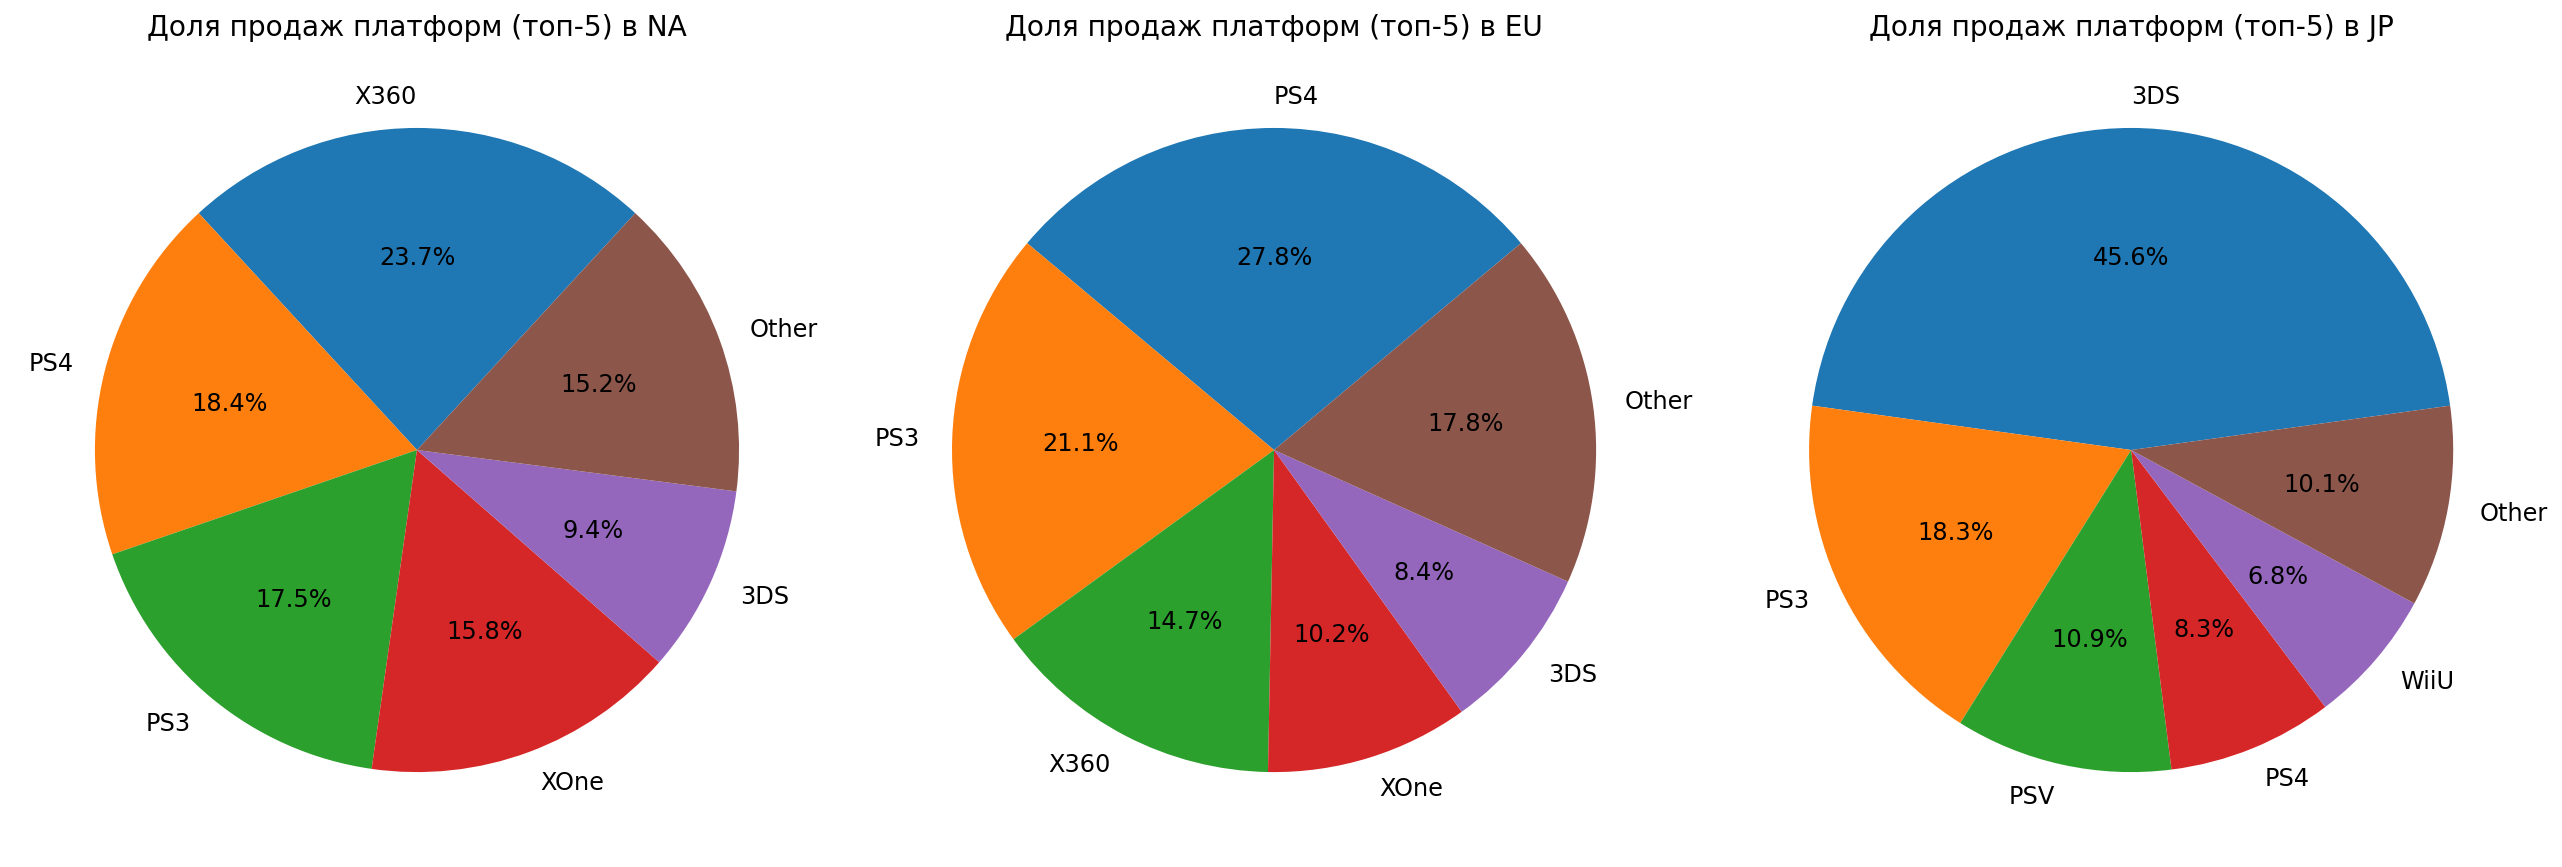

In [34]:
# Функция для корректировки долей, чтобы сумма равнялась 100% (т.к. даже при округлении с двумя знаками после запятой на 0,01 отличается)
def adjust_shares(shares):
    total = shares.sum()
    if total != 100:  # Проверяем, если сумма не равна 100
        difference = 100 - total
        shares['Other'] += difference  # Корректируем долю "Other" (только в первой диаграмме произойдет корректировка на 0,01)
    return shares

# Функция для построения круговой диаграммы с контролем положения самой большой доли
def plot_pie_chart_top_right(data, title, ax):
    # Суммируем продажи
    total_sales = data.sum()
    # Берем топ-5 платформ и добавляем остальные в категорию "Other"
    top_platforms = data.sort_values(ascending=False).head(5)
    other_platforms = total_sales - top_platforms.sum()
    top_platforms['Other'] = other_platforms

    # Вычисляем доли и корректируем их
    shares = (top_platforms / total_sales * 100).round(1)
    shares = adjust_shares(shares)  # Корректируем доли, чтобы сумма была 100%

    # Устанавливаем начальный угол, чтобы самая большая доля оказалась справа вверху
    largest_angle = (shares.cumsum() / 100).iloc[0] * 360
    start_angle = 90 - largest_angle / 2

    # Построение круговой диаграммы
    shares.plot(
        kind='pie',
        autopct='%.1f%%',
        startangle=start_angle,
        ax=ax,
        textprops={'fontsize': 12}  # Увеличиваем шрифт подписей
    )
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('')  # Убираем подпись оси

# Подготовка данных для построения круговых диаграмм
na_sales = actual_period_data.groupby('platform')['na_sales'].sum()
eu_sales = actual_period_data.groupby('platform')['eu_sales'].sum()
jp_sales = actual_period_data.groupby('platform')['jp_sales'].sum()

# Построение круговых диаграмм для каждого региона
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_pie_chart_top_right(na_sales, 'Доля продаж платформ (топ-5) в NA', axes[0])
plot_pie_chart_top_right(eu_sales, 'Доля продаж платформ (топ-5) в EU', axes[1])
plot_pie_chart_top_right(jp_sales, 'Доля продаж платформ (топ-5) в JP', axes[2])

plt.tight_layout()
plt.show()


На основе графиков можно сделать следующие выводы:

1. В **Северной Америке (NA)** лидером по доле продаж является **X360** с 23.7%, что значительно выделяет её среди остальных. На втором месте **PS4** с долей 18.4%, что лишь немного превышает долю **PS3** (17.5%). **XOne** и **3DS** занимают последние места в топ-5, с долями 15.8% и 9.4% соответственно.   Видно, что в NA предпочитают платформы, ориентированные на широкую аудиторию и семейные игры. Доля продаж на всех остальных платформах составляет 15.2%.

2. В **Европе (EU)** **PS4** занимает первое место с 27.8% и опережая по продажам своего "предшественника" **PS3** на 6.7%.   **X360** также популярна в Европе, занимая третье место с долей продаж 14.7%.  **XOne** и **3DS**, как и в NA, замыкают топ-5 с долями продаж 10.2% и 8.4% соответственно. В Европе популярны как семейные платформы, так и те, что подходят для хардкорных геймеров. Доля продаж на всех остальных платформах составляет 17.8%.

3. В **Японии** абсолютным лидером является **3DS** с долей продаж 45.6%. На втором месте **PS3** (18.3%). **PSV** занимает третье место (10.9%), а **PS4** и **WiiU** имеют доли 8.3% и 6.8% соответственно. Японский рынок сильно отличается от NA и EU, здесь доминируют портативные платформы. Доля продаж на всех остальных платформах составляет 10.1%.

Общие различия:
- **NA и EU** демонстрируют схожие предпочтения, отдавая предпочтение домашним консолям, таким как X360, PS4 и PS3.
- **JP** выделяется сильным акцентом на портативные платформы (3DS, PS3, PSV), что связано с культурными особенностями региона и популярностью игр для мобильных устройств.

#### Самые популярные жанры (топ-5) в каждом регионе

Сначала, как и выше, сгруппируем данные по жанрам для каждого региона и подсчитаем продажи. Выведем топ-5 популярных жанров в каждом регионе.

In [35]:
# Функция для вывода топ-5 жанров и остальных
def print_top5_and_other(region_name, sales_data):
    total_sales = sales_data.sum()
    top_5 = sales_data.sort_values(ascending=False).head(5)
    other = total_sales - top_5.sum()
    top_5['Other'] = other
    print(f"Топ-5 жанров и 'Other' для {region_name}:\n")
    print(top_5)
    print("*" * 30, "\n")

# Группируем данные по жанрам для каждого региона и подсчитываем продажи
genres_na = actual_period_data.groupby('genre')['na_sales'].sum()
genres_eu = actual_period_data.groupby('genre')['eu_sales'].sum()
genres_jp = actual_period_data.groupby('genre')['jp_sales'].sum()

# Выводим топ-5 жанров и категорию "Other" для каждого региона
print_top5_and_other("NA", genres_na)
print_top5_and_other("EU", genres_eu)
print_top5_and_other("JP", genres_jp)

Топ-5 жанров и 'Other' для NA:

genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Other            84.64
Name: na_sales, dtype: float64
****************************** 

Топ-5 жанров и 'Other' для EU:

genre
Action          159.34
Shooter         113.47
Sports           69.08
Role-Playing     48.53
Racing           27.29
Other            89.10
Name: eu_sales, dtype: float64
****************************** 

Топ-5 жанров и 'Other' для JP:

genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Other           41.63
Name: jp_sales, dtype: float64
****************************** 



Построим дополнительно визуализацию (круговую диаграмму по каждому региону) и поясним разницу в долях продаж.

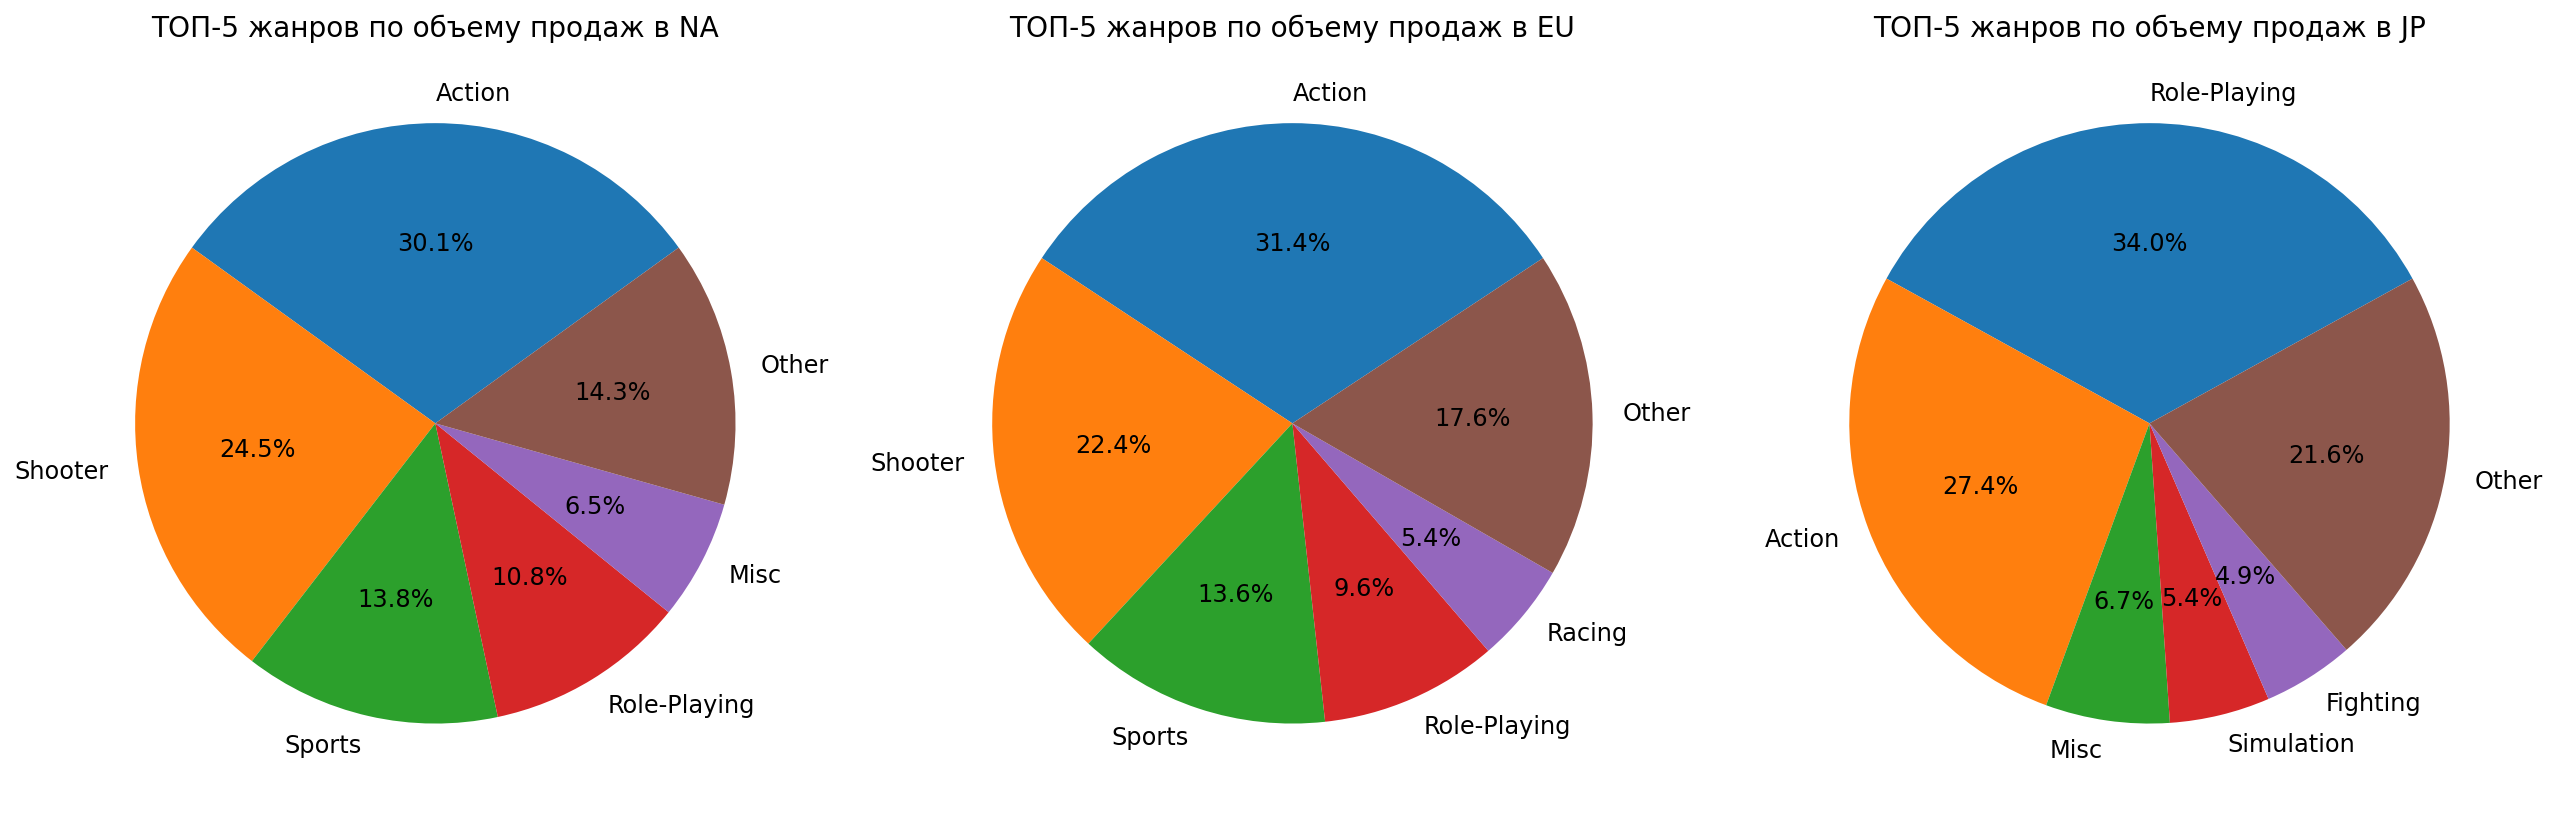

In [36]:
# Функция для построения круговой диаграммы с настройкой положения самой большой доли и крупными подписями
def plot_pie_chart_top_right(region_data, region_name, ax):
    # Суммируем продажи
    total_sales = region_data.sum()
    # Берем топ-5 жанров и добавляем остальные в категорию "Other"
    top_genres = region_data.sort_values(ascending=False).head(5)
    other_genres = total_sales - top_genres.sum()
    top_genres['Other'] = other_genres
    
    # Устанавливаем начальный угол, чтобы самая большая доля оказалась справа вверху
    largest_angle = (top_genres.cumsum() / total_sales).iloc[0] * 360
    start_angle = 90 - largest_angle / 2  # Сдвиг, чтобы синяя доля оказалась на 1–2 часах
    
    # Построение круговой диаграммы с крупными подписями
    top_genres.plot(
        kind='pie',
        autopct='%.1f%%',
        startangle=start_angle,
        ax=ax,
        legend=False,
        textprops={'fontsize': 12}  # Увеличиваем размер шрифта подписей
    )
    ax.set_title(f'ТОП-5 жанров по объему продаж в {region_name}', fontsize=14)
    ax.set_ylabel('')  # Убираем подпись оси

# Подготовка данных для каждого региона
na_genre_sales = actual_period_data.groupby('genre')['na_sales'].sum()
eu_genre_sales = actual_period_data.groupby('genre')['eu_sales'].sum()
jp_genre_sales = actual_period_data.groupby('genre')['jp_sales'].sum()

# Построение графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Построение круговых диаграмм для каждого региона
plot_pie_chart_top_right(na_genre_sales, 'NA', axes[0])
plot_pie_chart_top_right(eu_genre_sales, 'EU', axes[1])
plot_pie_chart_top_right(jp_genre_sales, 'JP', axes[2])

plt.tight_layout()
plt.show()

На основе графиков можно выделить следующие особенности:

1. В **Северной Америке (NA)** Самым популярным жанром является **Action** (доля продаж - 30.1%), что указывает на высокий интерес к динамичным играм. На втором месте **Shooter** (доля продаж -24.5%), за ним следуют **Sports** (доля продаж - 13.8%) и **Role-Playing** (доля продаж - 10.8%).  **Misc** замыкает топ-5 с долей продаж 6.5%. В NA жанры с динамичным и соревновательным геймплеем пользуются наибольшей популярностью. Доля продаж на всех остальных платформах составляет 14.3%.

2. В **Европе (EU)** **Action** также занимает первое место по объему продаж (доля продаж - 24.54%), схожей с NA. На втором месте **Shooter** (доля продаж - 22.4%), следом идут **Sports** (13.6%), **Role-Playing** (9.6%) и **Racing** (5.4%).  В Европе наблюдается схожий с NA интерес к динамичным и спортивным играм, однако жанр **Racing** здесь более востребован. Доля продаж на всех остальных платформах составляет 17.6%.

3. В **Японии (JP)** лидирует жанр **Role-Playing** с долей 34.0%, что подчёркивает популярность сюжетных и ролевых игр в этом регионе. На втором месте **Action** (27.4%), что также отражает интерес к динамичным играм. Жанры **Misc** (6.7%), **Simulation** (5.4%), и **Fighting** (4.9%) замыкают топ-5. В отличие от NA и EU, японский рынок демонстрирует явное предпочтение к RPG и меньший интерес к спортивным симуляторам и стрелялкам. Доля продаж на всех остальных платформах составляет 21.6%.

Общие различия:
- В **NA** и **EU** популярны жанры **Action**, **Shooter**, и **Sports**, что подчеркивает сходство вкусов.
- **JP** значительно выделяется за счёт предпочтения ролевых игр, таких как JRPG, и меньшего интереса к стрелялкам.

#### Влияние рейтинга ESRB на продажи

Сгруппируем данные по **рейтингам ESRB** и **регионам**, чтобы отобразить распределение продаж по игровым рейтингам.

Продажи по ESRB в NA:
 rating
M          231.57
E          114.37
Unknown    103.31
E10+        75.70
T           66.02
Name: na_sales, dtype: float64
******************************

Продажи по ESRB в EU:
 rating
M          193.96
E          113.02
Unknown     91.50
E10+        55.37
T           52.96
Name: eu_sales, dtype: float64
******************************

Продажи по ESRB в JP:
 rating
Unknown    108.84
E           28.33
T           26.02
M           21.20
E10+         8.19
Name: jp_sales, dtype: float64


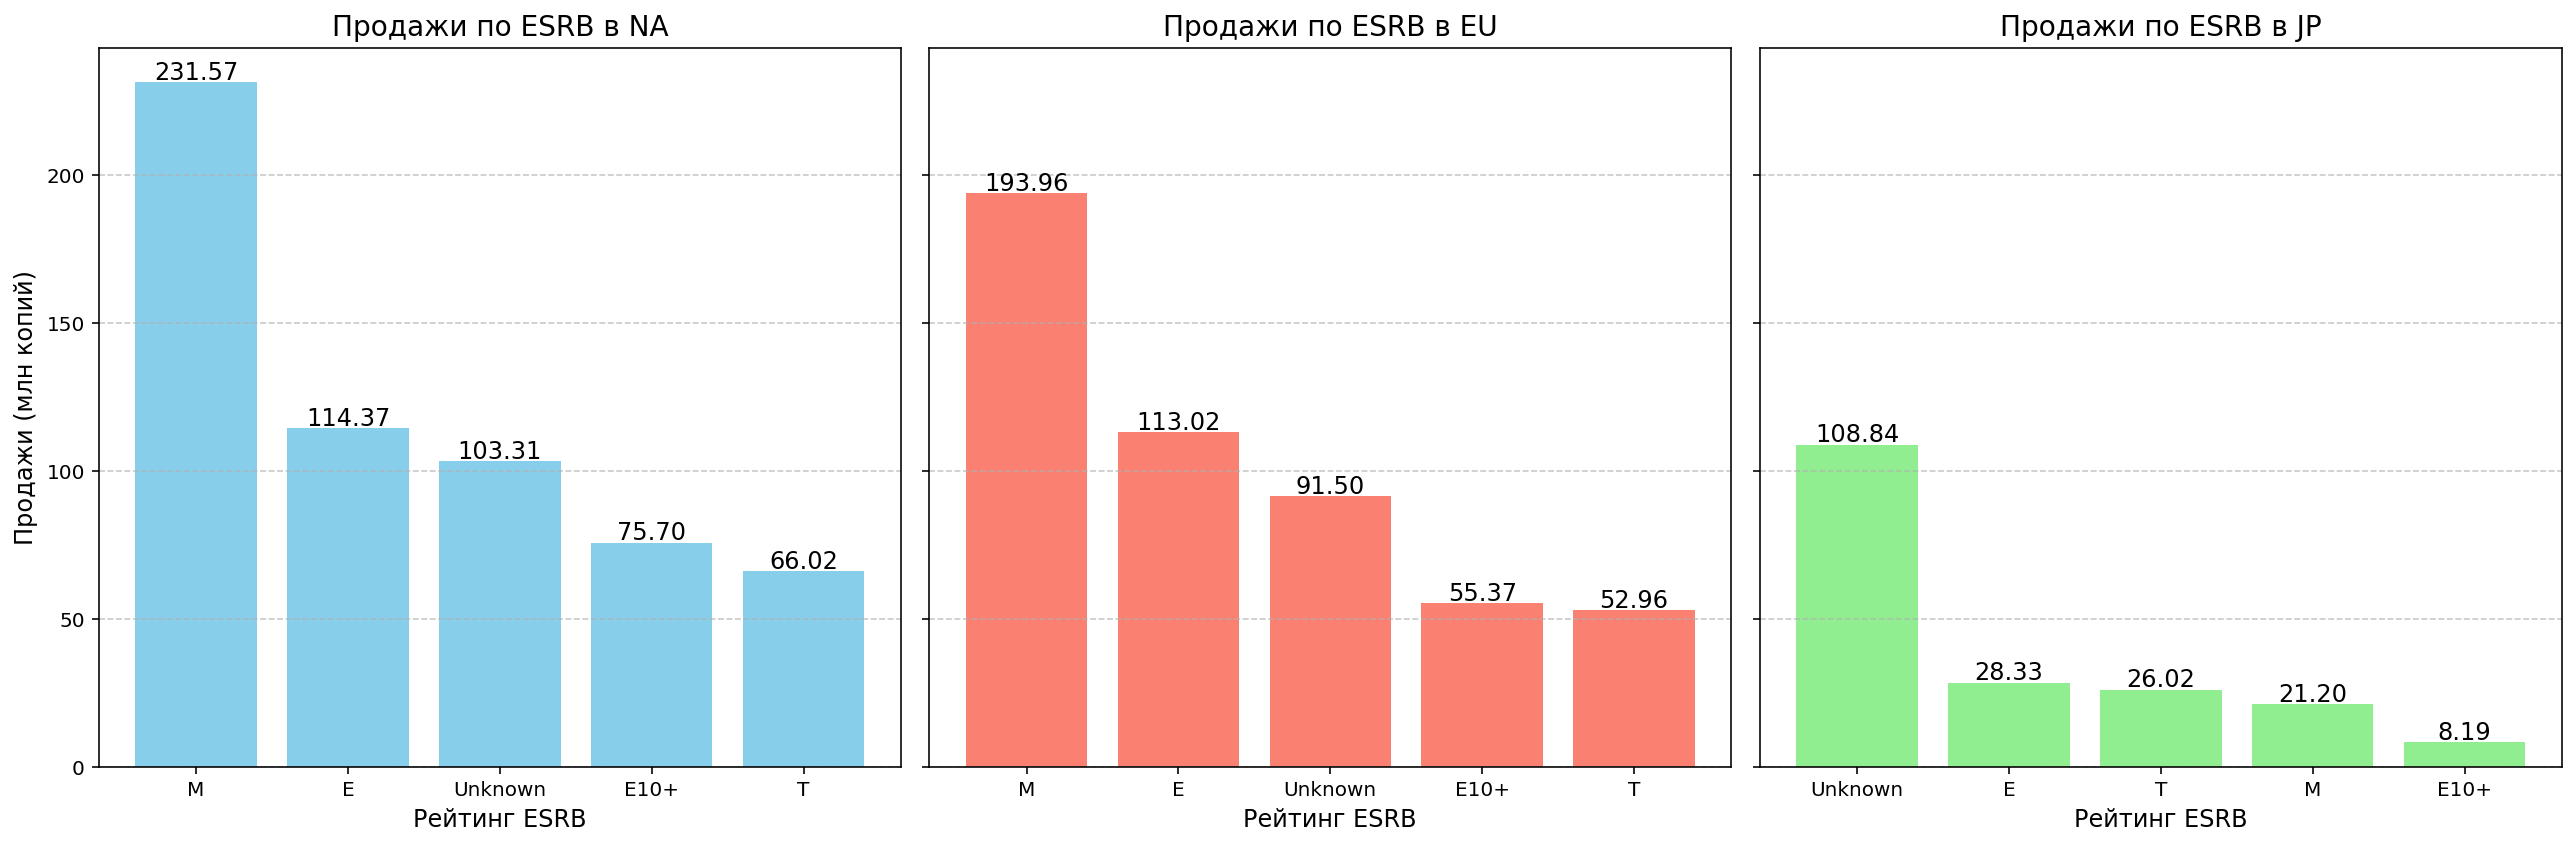

In [38]:
# Группируем данные по рейтингу ESRB и регионам
esrb_na = actual_period_data.groupby('rating')['na_sales'].sum().sort_values(ascending=False)
esrb_eu = actual_period_data.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)
esrb_jp = actual_period_data.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

# Выводим результаты
print("Продажи по ESRB в NA:\n", esrb_na)
print("*"*30)
print("\nПродажи по ESRB в EU:\n", esrb_eu)
print("*"*30)
print("\nПродажи по ESRB в JP:\n", esrb_jp)

# Строим дополнительно визуализацию
# Функция для добавления значений над столбцами
def add_labels(ax, values):
    for i, value in enumerate(values):
        ax.text(i, value + 1, f'{value:.2f}', ha='center', fontsize=12, color='black')
        
# Построение столбиковых диаграмм для каждого региона
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# NA
axes[0].bar(esrb_na.index, esrb_na.values, color='skyblue')
add_labels(axes[0], esrb_na.values)
axes[0].set_title('Продажи по ESRB в NA', fontsize=14)
axes[0].set_xlabel('Рейтинг ESRB', fontsize=12)
axes[0].set_ylabel('Продажи (млн копий)', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# EU
axes[1].bar(esrb_eu.index, esrb_eu.values, color='salmon')
add_labels(axes[1], esrb_eu.values)
axes[1].set_title('Продажи по ESRB в EU', fontsize=14)
axes[1].set_xlabel('Рейтинг ESRB', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# JP
axes[2].bar(esrb_jp.index, esrb_jp.values, color='lightgreen')
add_labels(axes[2], esrb_jp.values)
axes[2].set_title('Продажи по ESRB в JP', fontsize=14)
axes[2].set_xlabel('Рейтинг ESRB', fontsize=12)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Улучшение отображения
plt.tight_layout()
plt.show()

На основании построенных диаграмм можно сделать следующие выводы:

1. В **Северной Америке (NA)** лидером продаж является категория **M** (Mature, 17+) с объемом **231.57 млн копий**, что составляет **39.2%** от всех продаж в регионе. На втором месте - **E** (Everyone, для всех возрастов) с **114.37 млн копий** (доля **19.4%**). Игры без указанного рейтинга (**Unknown**) занимают третье место с продажами **103.31 млн копий** (**17.5%**). Категории **E10+** (Everyone 10+, для всех от 10 лет) и **T** (Teen, 13+) имеют доли **12.8%** и **11.2%**, с продажами **75.7** и **66.02 млн копий** соответственно. 

***Вывод:*** В NA игры с рейтингом **M**, предназначенные для взрослой аудитории, показывают наибольшие продажи. Они доминируют на рынке, занимая почти 40% доли.

2. В **Европе (EU)** лидером является категория **M** с продажами **193.96 млн копий**, что составляет **38.3%**. На втором месте - **E** с **113.02 млн копий** и долей **22.3%**. Игры без указанного рейтинга (**Unknown**) имеют продажи **91.5 млн копий** и долю **18.1%**. Категории **E10+** и **T** занимают **10.9%** и **10.4%** с продажами **55.37** и **52.96 млн копий** соответственно. 

***Вывод:*** Рынок EU близок по структуре к NA, с доминированием рейтинга **M**.

3. На **японском рынке (JP)** лидируют игры без указанного рейтинга (**Unknown**) с продажами **108.84 млн копий**, что составляет **56.5%**. Рейтинг **E** занимает второе место с **28.33 млн копий** (доля **14.7%**). Категории **T** и **M** имеют продажи **26.02** и **21.2 млн копий**, с долями **13.5%** и **11.0%** соответственно. Рейтинг **E10+** показывает наименьшие продажи - **8.19 млн копий** с долей **4.3%**. 

***Вывод:*** В JP рейтинги ESRB практически не используются — лидирующие позиции занимают игры с неопределенным рейтингом, что подтверждает доминирование локальных систем (например, CERO).

**Общие наблюдения:**

- *Доли продаж:* 
  - В NA и EU доли игр с рейтингом **M** составляют почти **40%**, что подчеркивает популярность игр для взрослой аудитории.
  - В JP доля игр без рейтинга (**Unknown**) превышает **56%**, что отражает низкое значение системы ESRB в этом регионе.
  
- *Региональные различия:*
  - NA и EU схожи в своих предпочтениях, хотя доля игр с рейтингом **E** выше в EU.
  - JP значительно отличается: игры без рейтинга и локальные системы имеют ключевое влияние, что подтверждается высокой долей категории **Unknown**.

Важно понимать, что система рейтинга ESRB изначально разработана для США и Канады, поэтому в других регионах преобладают игры с отсутсвующим рейтингом ESRB (Unknown). Однако, если посмотреть на ситуацию в Японии, можно увидеть, что игры с рейтингом ESRB тоже присутствуют. Это связано с тем, что крупные разработчики часто используют ESRB как часть глобального подхода к маркировке своих игр, поэтому некоторые игры, издаваемые международными компаниями, распространяются с этим рейтингом и в других регионах. Тем не менее, в регионах, таких как Европа и Япония, местные системы рейтингов (например, PEGI в Европе и CERO в Японии) имеют большее значение.

Таким образом, исходя из всего вышеперечисленного, можно ответить на вопрос: **влияет ли рейтинг ESRB на продажи?**

*Рейтинг ESRB оказывает влияние на продажи, но степень этого влияния зависит от региона:*

- В `NA` и `EU` игры с рейтингами `M` и `E` занимают лидирующие позиции по продажам. Это указывает на то, что игроки в этих регионах охотно покупают как взрослые игры, так и игры для широкой аудитории. Таким образом, ESRB позволяет ориентировать игры на целевые аудитории, что может положительно влиять на продажи.

- В `JP`, где система ESRB имеет ограниченное применение, ключевую роль играют локальные системы рейтингов. Однако наличие игр с рейтингами ESRB указывает на то, что глобальные издатели всё же стремятся охватить эту аудиторию, хотя влияние ESRB на продажи в этом регионе минимально.

Таким образом, **рейтинг ESRB может быть важным фактором в Северной Америке и Европе, где он помогает ориентировать аудиторию, но его влияние в Японии существенно ниже**.

#### Вывод по разделу
На этом этапе исследования были выполнены следующие задачи и сделаны ключевые наблюдения:

1. **Установлены самые популярные платформы (топ-5) для пользователя каждого региона (NA, EU, JP). Различия описаны в долях продаж.**

Сгруппировали данные по платформам для каждого региона и подсчитали продажи. Вывели топ-5 популярных платформ в каждом регионе. Построили визуализации (круговые диаграммы).

*Наблюдения:*

- В **Северной Америке (NA)** лидером по доле продаж является `X360` с 23.7%, что значительно выделяет её среди остальных. На втором месте `PS4` с долей 18.4%, что лишь немного превышает долю `PS3` (17.5%). `XOne` и `3DS` занимают последние места в топ-5, с долями 15.8% и 9.4% соответственно. Видно, что в NA предпочитают платформы, ориентированные на широкую аудиторию и семейные игры. Доля продаж на всех остальных платформах составляет 15.2%.

- В **Европе (EU)** `PS4` занимает первое место с 27.8% и опережая по продажам своего "предшественника" `PS3` на 6.7%. `X360` также популярна в Европе, занимая третье место с долей продаж 14.7%. `XOne` и `3DS`, как и в `NA`, замыкают топ-5 с долями продаж 10.2% и 8.4% соответственно. В Европе популярны как семейные платформы, так и те, что подходят для хардкорных геймеров. Доля продаж на всех остальных платформах составляет 17.8%.

- В **Японии** абсолютным лидером является `3DS` с долей продаж 45.6%. На втором месте `PS3` (18.3%). `PSV` занимает третье место (10.9%), а `PS4` и `WiiU` имеют доли 8.3% и 6.8% соответственно. Японский рынок сильно отличается от `NA` и `EU`, здесь доминируют портативные платформы. Доля продаж на всех остальных платформах составляет 10.1%.

*Общие различия:*

- `NA` и `EU` демонстрируют схожие предпочтения, отдавая предпочтение домашним консолям, таким как `X360`, `PS4` и `PS3`.
- `JP` выделяется сильным акцентом на портативные платформы (`3DS`, `PS3`, `PSV`), что связано с культурными особенностями региона и популярностью игр для мобильных устройств.

2. **Выявлены самые популярные жанры (топ-5) в каждом регионе. Различия описаны в долях продаж.**

Сгруппировали данные по жанрам для каждого региона и подсчитали продажи. Вывели топ-5 популярных жанров в каждом регионе. Построили визуализации (круговые диаграммы).

*Наблюдения:*
- В **Северной Америке (NA)** самым популярным жанром является `Action` (доля продаж - 30.1%), что указывает на высокий интерес к динамичным играм. На втором месте `Shooter` (доля продаж -24.5%), за ним следуют `Sports` (доля продаж - 13.8%) и `Role-Playing` (доля продаж - 10.8%). `Misc` замыкает топ-5 с долей продаж 6.5%. В NA жанры с динамичным и соревновательным геймплеем пользуются наибольшей популярностью. Доля продаж на всех остальных платформах составляет 14.3%.

- В **Европе (EU)** `Action` также занимает первое место по объему продаж (доля продаж - 24.54%), схожей с NA. На втором месте `Shooter` (доля продаж - 22.4%), следом идут `Sports` (13.6%), `Role-Playing` (9.6%) и `Racing` (5.4%). В Европе наблюдается схожий с NA интерес к динамичным и спортивным играм, однако жанр Racing здесь более востребован. Доля продаж на всех остальных платформах составляет 17.6%.

- В **Японии (JP)** лидирует жанр `Role-Playing` с долей 34.0%, что подчёркивает популярность сюжетных и ролевых игр в этом регионе. На втором месте `Action` (27.4%), что также отражает интерес к динамичным играм. Жанры `Misc` (6.7%), `Simulation` (5.4%), и `Fighting` (4.9%) замыкают топ-5. В отличие от NA и EU, японский рынок демонстрирует явное предпочтение к RPG (ролевые игры) и меньший интерес к спортивным симуляторам и стрелялкам. Доля продаж на всех остальных платформах составляет 21.6%.

*Общие различия:*

- В **NA** и **EU** популярны жанры `Action`, `Shooter` и `Sports`, что подчеркивает сходство вкусов.
- **JP** значительно выделяется за счёт предпочтения ролевых игр, таких как RPG, и меньшего интереса к стрелялкам.

3. Определено влияние рейтинга ESRB на продажи. 

Все данные сгруппировали по рейтингам ESRB и регионам, чтобы отобразить распределение продаж по игровым рейтингам.

*Наблюдения:*

- В **Северной Америке (NA)** лидером продаж является категория `M (Mature, 17+)` с объемом 231.57 млн копий, что составляет 39.2% от всех продаж в регионе. На втором месте - `E (Everyone, для всех возрастов)` с 114.37 млн копий (доля 19.4%). Игры без указанного рейтинга (`Unknown`) занимают третье место с продажами 103.31 млн копий (17.5%). Категории `E10+ (Everyone 10+, для всех от 10 лет)` и `T (Teen, 13+)` имеют доли 12.8% и 11.2%, с продажами 75.7 и 66.02 млн копий соответственно.

-  В **Европе (EU)** лидером является категория `M` с продажами 193.96 млн копий, что составляет 38.3%. На втором месте - `E` с 113.02 млн копий и долей 22.3%. Игры без указанного рейтинга (`Unknown`) имеют продажи 91.5 млн копий и долю 18.1%. Категории `E10+` и `T` занимают 10.9% и 10.4% с продажами 55.37 и 52.96 млн копий соответственно.

- На **японском рынке (JP)** лидируют игры без указанного рейтинга (`Unknown`) с продажами 108.84 млн копий, что составляет 56.5%. Рейтинг `E` занимает второе место с 28.33 млн копий (доля 14.7%). Категории `T` и `M` имеют продажи 26.02 и 21.2 млн копий, с долями 13.5% и 11.0% соответственно. Рейтинг `E10+` показывает наименьшие продажи - 8.19 млн копий с долей 4.3%.

-  В `NA` и `EU` доли игр с рейтингом M составляют почти 40%, что подчеркивает популярность игр для взрослой аудитории.
- В `JP` доля игр без рейтинга (`Unknown`) превышает 56%, что отражает низкое значение системы ESRB в этом регионе.
- NA и EU схожи в своих предпочтениях, хотя доля игр с рейтингом E выше в EU.
- JP значительно отличается: игры без рейтинга и локальные системы имеют ключевое влияние, что подтверждается высокой долей категории Unknown.

*Примечание:* система рейтинга ESRB изначально разработана для США и Канады, поэтому в других регионах преобладают игры с отсутсвующим рейтингом ESRB (Unknown). Однако, если посмотреть на ситуацию в Японии, можно увидеть, что игры с рейтингом ESRB тоже присутствуют. Это связано с тем, что крупные разработчики часто используют ESRB как часть глобального подхода к маркировке своих игр, поэтому некоторые игры, издаваемые международными компаниями, распространяются с этим рейтингом и в других регионах. Тем не менее, в регионах, таких как Европа и Япония, местные системы рейтингов (например, PEGI в Европе и CERO в Японии) имеют большее значение.

Таким образом, исходя из всего вышеперечисленного, можно определить степень влияния рейтинг ESRB на продажи.

**Рейтинг ESRB оказывает влияние на продажи, но степень этого влияния зависит от региона:**

- В NA и EU игры с рейтингами M и E занимают лидирующие позиции по продажам. Это указывает на то, что игроки в этих регионах охотно покупают как взрослые игры, так и игры для широкой аудитории. Таким образом, ESRB позволяет ориентировать игры на целевые аудитории, что может положительно влиять на продажи.

- В JP, где система ESRB имеет ограниченное применение, ключевую роль играют локальные системы рейтингов. Однако наличие игр с рейтингами ESRB указывает на то, что глобальные издатели всё же стремятся охватить эту аудиторию, хотя влияние ESRB на продажи в этом регионе минимально.

Таким образом, рейтинг ESRB может быть важным фактором в Северной Америке и Европе, где он помогает ориентировать аудиторию, но его влияние в Японии существенно ниже.

### Проверка гипотез
<a id='Hypothesis_testing'></a>
#### 1. Гипотеза о равенстве средних пользовательских рейтингов платформ Xbox One и PC

**Нулевая гипотеза (H₀):** Средние пользовательские рейтинги платформ Xbox One и PC равны.  
**Альтернативная гипотеза (H₁):** Средние пользовательские рейтинги платформ Xbox One и PC различаются.

Для проверки этой гипотезы используется **критерий Стьюдента (t-тест)** для независимых выборок, так как:
- Сравниваются два независимых множества данных.
- Проверяется равенство средних значений.

**Пороговое значение статистической значимости `alpha`** задается равным **0.05**. Это стандартное значение, которое означает, что вероятность ошибочного отклонения нулевой гипотезы не должна превышать 5%.

1. Если p-значение меньше `alpha` (0.05), **нулевая гипотеза отвергается** в пользу альтернативной.
2. Если p-значение больше `alpha`, **нулевая гипотеза не отвергается**, и можно считать, что статистически значимых различий нет.

Гипотеза: t-статистика = 0.60, p-значение = 0.5490

Результаты:
Не получилось отвергнуть нулевую гипотезу: Нет статистически значимых различий между средними пользовательскими рейтингами Xbox One и PC.


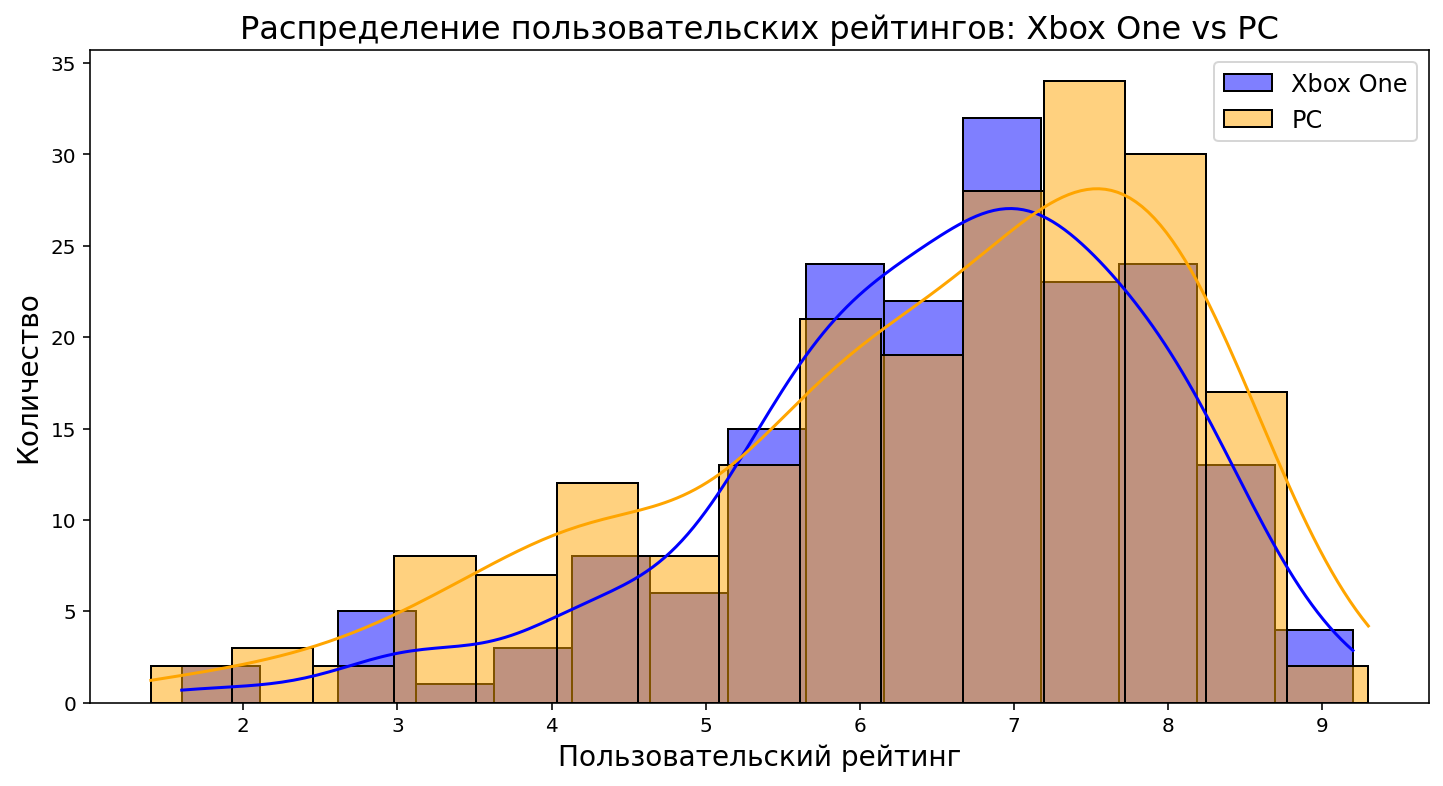

In [39]:
# Фильтруем данные для Xbox One и PC (убираем заглушки с -1)
xbox_one_ratings = actual_period_data[(actual_period_data['platform'] == 'XOne') & (actual_period_data['user_score'] != -1)]['user_score']
pc_ratings = actual_period_data[(actual_period_data['platform'] == 'PC') & (actual_period_data['user_score'] != -1)]['user_score']

# Проверка гипотезы: средние пользовательские рейтинги Xbox One и PC
t_stat_xbox_pc, p_value_xbox_pc = ttest_ind(xbox_one_ratings, pc_ratings, equal_var=False)
print(f"Гипотеза: t-статистика = {t_stat_xbox_pc:.2f}, p-значение = {p_value_xbox_pc:.4f}")

# Интерпретация результатов
alpha = 0.05  # уровень статистической значимости
print("\nРезультаты:")
if p_value_xbox_pc < alpha:
    print("Отвергаем нулевую гипотезу: средние пользовательские рейтинги Xbox One и PC статистически различны.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: Нет статистически значимых различий между средними пользовательскими рейтингами Xbox One и PC.")

# Построение гистограммы для платформ (исключаем заглушки)
plt.figure(figsize=(12, 6))

# Гистограмма для Xbox One
sns.histplot(data=xbox_one_ratings, color='blue', label='Xbox One', kde=True, bins=15)

# Гистограмма для PC
sns.histplot(data=pc_ratings, color='orange', label='PC', kde=True, bins=15)

# Настройка графика
plt.title('Распределение пользовательских рейтингов: Xbox One vs PC', fontsize=16)
plt.xlabel('Пользовательский рейтинг', fontsize=14)
plt.ylabel('Количество', fontsize=14)
plt.legend(fontsize=12)
plt.show()

Поскольку полученное значение p-value (0.5490) значительно превышает установленный уровень статистической значимости alpha (0.05), **нулевая гипотеза не отвергается: статистически значимых различий между средними пользовательскими рейтингами Xbox One и PC не выявлено.**

Тем не менее, прежде чем окончательно принять решение о сохранении нулевой гипотезы, предлагается дополнительно произвести расчет **среднего пользовательского рейтинга** и **доверительных интервалов** (CI).  Они дают более полное представление о данных и их вариативности, чем просто средние значения. **Если доверительные интервалы для двух групп перекрываются, то различия между средними значениями, скорее всего, незначимы. Если интервалы не перекрываются, это свидетельствует о статистически значимой разнице**.

In [40]:
# Проверяем средние пользовательские рейтинги для Xbox One и PC
print('-' * 62)
mean_xbox = round(xbox_one_ratings.mean(), 2)
mean_pc = round(pc_ratings.mean(), 2)
print('Средний пользовательский рейтинг Xbox One:', mean_xbox)
print('Средний пользовательский рейтинг PC:', mean_pc)

# Расчет доверительных интервалов
confidence = 0.95  # уровень доверия

# Для Xbox One
n_xbox = len(xbox_one_ratings)
se_xbox = sem(xbox_one_ratings)
ci_xbox = t.interval(confidence, n_xbox - 1, loc=mean_xbox, scale=se_xbox)

# Для PC
n_pc = len(pc_ratings)
se_pc = sem(pc_ratings)
ci_pc = t.interval(confidence, n_pc - 1, loc=mean_pc, scale=se_pc)

# Вывод доверительных интервалов
print('-' * 62)
print(f"Доверительный интервал для Xbox One: {ci_xbox[0]:.2f} — {ci_xbox[1]:.2f}")
print(f"Доверительный интервал для PC: {ci_pc[0]:.2f} — {ci_pc[1]:.2f}")

--------------------------------------------------------------
Средний пользовательский рейтинг Xbox One: 6.52
Средний пользовательский рейтинг PC: 6.43
--------------------------------------------------------------
Доверительный интервал для Xbox One: 6.32 — 6.72
Доверительный интервал для PC: 6.20 — 6.66


Дополнительный расчет доверительных интервалов подтвердил выводы:

- Для `Xbox One` доверительный интервал составляет: **6.32 — 6.72**
- Для `PC` -  **6.20 — 6.66**

Поскольку **интервалы перекрываются**, это указывает на отсутствие статистически значимых различий между пользовательскими рейтингами этих платформ. Таким образом, **нулевая гипотеза о равенстве средних пользовательских рейтингов платформ Xbox One и PC сохраняется**.

#### 2. Гипотеза о различии средних пользовательских рейтингов жанров Action и Sports

**Нулевая гипотеза (H₀):** Средние пользовательские рейтинги жанров Action и Sports равны.  
**Альтернативная гипотеза (H₁):** Средние пользовательские рейтинги жанров Action и Sports различаются.

Для проверки также применяется **критерий Стьюдента (t-тест)**, так как:
- Сравниваются две независимые группы данных.
- Необходимо проверить равенство средних значений.

**Пороговое значение статистической значимости `alpha`** задается равным **0.05**. Это стандартное значение, которое означает, что вероятность ошибочного отклонения нулевой гипотезы не должна превышать 5%.

1. Если p-значение меньше `alpha` (0.05), **нулевая гипотеза отвергается** в пользу альтернативной.
2. Если p-значение больше `alpha`, **нулевая гипотеза не отвергается**, и можно считать, что статистически значимых различий нет.

Гипотеза 2: t-статистика = 9.86, p-значение = 0.0000000000
Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports статистически различны.


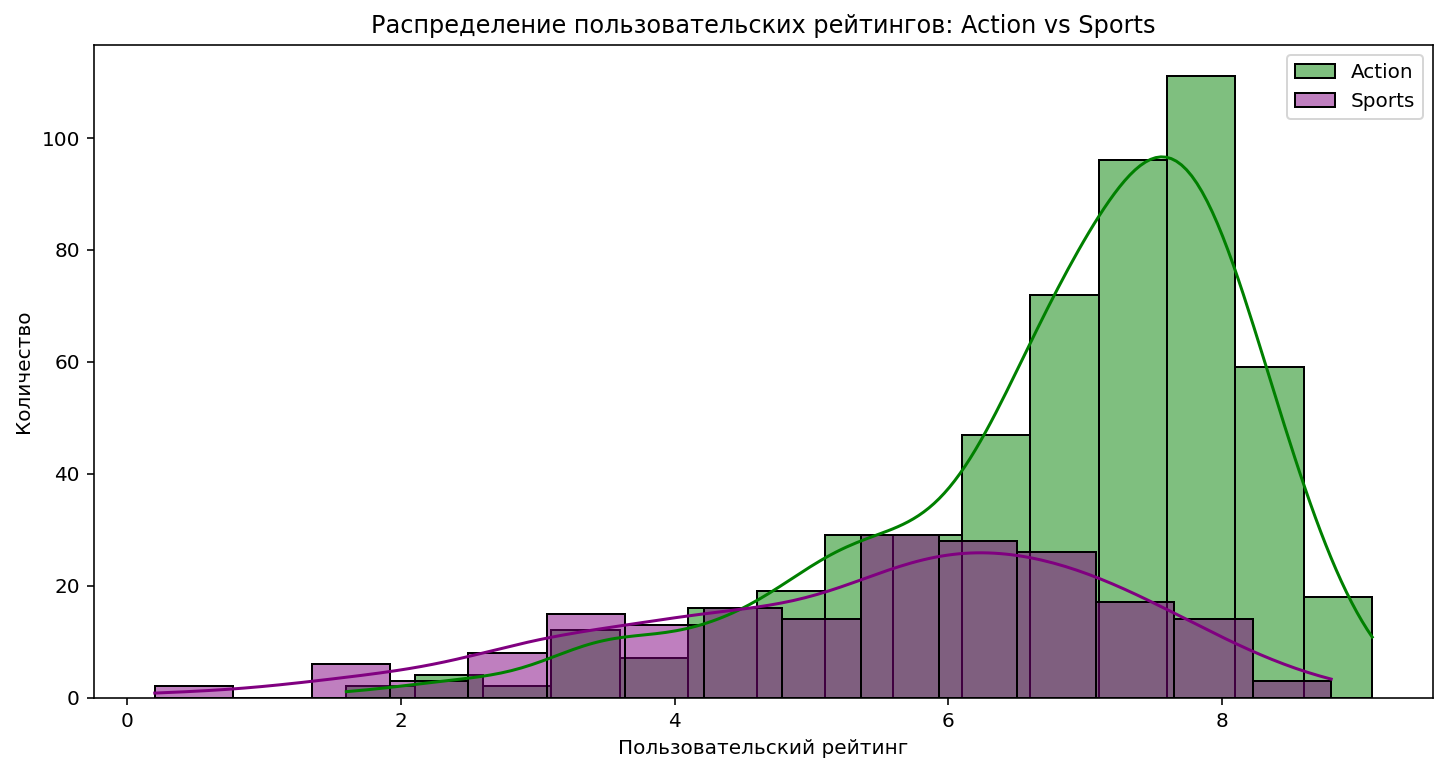

In [41]:
# Фильтруем данные для жанров Action и Sports (убираем заглушки с -1)
action_ratings = actual_period_data.query("genre == 'Action' and user_score != -1")['user_score']
sports_ratings = actual_period_data.query("genre == 'Sports' and user_score != -1")['user_score']

# Проверка гипотезы 2: Action vs Sports
t_stat_action_sports, p_value_action_sports = ttest_ind(action_ratings, sports_ratings, equal_var=False)
print(f"Гипотеза 2: t-статистика = {t_stat_action_sports:.2f}, p-значение = {p_value_action_sports:.10f}")

# Интерпретация результатов
alpha = 0.05
if p_value_action_sports < alpha:
    print("Отвергаем нулевую гипотезу: средние пользовательские рейтинги жанров Action и Sports статистически различны.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: нет статистически значимых различий между средними пользовательскими рейтингами жанров Action и Sports.")
    
# Гистограмма для жанров
plt.figure(figsize=(12, 6))
sns.histplot(data=action_ratings, color='green', label='Action', kde=True, bins=15)
sns.histplot(data=sports_ratings, color='purple', label='Sports', kde=True, bins=15)
plt.title('Распределение пользовательских рейтингов: Action vs Sports')
plt.xlabel('Пользовательский рейтинг')
plt.ylabel('Количество')
plt.legend()
plt.show()

Результаты теста (t-статистика = `9.86`, p-значение = `0.0000000000`) показали, что **средние пользовательские рейтинги жанров `Action` и `Sports` статистически различны**. Полученное значение p-value значительно меньше установленного уровня статистической значимости alpha (0.05).

В этой ситуации, как и выше, прежде чем принимать окончательное решение об отвержении нулевой гипотезы, предлагается дополнительно произвести расчет **среднего пользовательского рейтинга** и **доверительных интервалов** (CI). 

In [42]:
# Проверяем средние пользовательские рейтинги для жанров Action и Sports
print('-' * 62)
mean_action = round(action_ratings.mean(), 2)
mean_sports = round(sports_ratings.mean(), 2)
print('Средний пользовательский рейтинг жанра Action:', mean_action)
print('Средний пользовательский рейтинг жанра Sports:', mean_sports)

# Расчет доверительных интервалов
confidence = 0.95  # доверительный уровень
# Для Action
n_action = len(action_ratings)
se_action = sem(action_ratings)
ci_action = t.interval(confidence, n_action - 1, loc=mean_action, scale=se_action)

# Для Sports
n_sports = len(sports_ratings)
se_sports = sem(sports_ratings)
ci_sports = t.interval(confidence, n_sports - 1, loc=mean_sports, scale=se_sports)

# Вывод доверительных интервалов
print('-' * 62)
print(f"Доверительный интервал для жанра Action: {ci_action[0]:.2f} — {ci_action[1]:.2f}")
print(f"Доверительный интервал для жанра Sports: {ci_sports[0]:.2f} — {ci_sports[1]:.2f}")

--------------------------------------------------------------
Средний пользовательский рейтинг жанра Action: 6.83
Средний пользовательский рейтинг жанра Sports: 5.46
--------------------------------------------------------------
Доверительный интервал для жанра Action: 6.71 — 6.95
Доверительный интервал для жанра Sports: 5.21 — 5.71


Дополнительный расчет доверительных интервалов подтвердил выводы:  
- Для жанра **Action** доверительный интервал составляет **6.78 — 6.92**,  
- Для жанра **Sports** — **6.27 — 6.51**.  

Поскольку интервалы **не перекрываются** даже частично, это свидетельствует **о наличии статистически значимой разницы** между пользовательскими рейтингами этих жанров. Таким образом, **нулевая гипотеза должна быть отвергнута**.

#### Вывод по разделу
На данном этапе была выполнена проверка гипотез:  

1. **Сравнение средних пользовательских рейтингов платформ Xbox One и PC** показало, что, хотя рейтинги игр на различных платформах могут отличаться, в данном случае эти различия статистически незначимы. Таким образом, нулевая гипотеза о равенстве средних пользовательских рейтингов для Xbox One и PC сохраняется.  

2. **Анализ различий в средних пользовательских рейтингах жанров Action и Sports** выявил, что средние рейтинги между этими жанрами статистически значимо отличаются. Это может быть обусловлено разницей в ожиданиях и предпочтениях аудитории каждого жанра. Следовательно, нулевая гипотеза о равенстве средних пользовательских рейтингов для жанров Action и Sports была отвергнута.

### Общий вывод
<a id='conclusions'></a>

**Заказчик исследования:** интернет-магазин «Стримчик».  

**Цель исследования:** выявить закономерности, определяющие успешность игры, для того чтобы сделать ставку на потенциально популярный продукт и эффективно спланировать рекламные кампании.  

**Задачи исследования**:
- произвести первичный обзор и подготовку данных;
- осуществить исследовательский анализ данных;
- составить портрет пользователя каждого региона;
- проверить гипотезы;
- сформирование выводы и предложить направления для дальнейшего развития.

В начале исследования нами были проведены **первичный анализ и предобработка данных**.

**Первичный обзор данных показал**, что

Датайфрейм `computer_games_data (данные о продажах игр, оценки пользователей, экспертов, жанры и платформы)`:
- содержит 16175 строк и 11 столбцов;
- наименование столбцов не соответствуют стилю `snake_case`, нужно привести к нижнему регистру;
- не все указанные типы данных соответствуют данным, содержащимся в столбцах:
    - в столбце `Year_of_Release` (год выпуска) стоит тип данных `float64`, нужно преобразовать в `int` (в тип `datetime` преобразовывать здесь не нужно, это будет избыточно для анализа, т.к. столбец `Year_of_Release` содержит не полную дату (например, день, месяц и год), а только числовое значение года);
    - в столбце `User_Score` тип данных `object`, а нужен `float64`;
- в 6-ти столбцах из 11-ти содержаться пропуски:
    - `Name` - **2** пропуска (**0,01%** данных)
    - `Year_of_Release` - **269** пропусков (**1,61%** данных)
    - `Genre` - **2** пропуска (**0,01%** данных)
    - `Critic_Score` - **8578** проопусков (**51,32%** данных)
    - `User_Score` - **6701** пропуск (**40,09%** данных)
    - `Rating` - **6766** пропускоов (**40.48%** данных)
- данные предоставлены за период **с 1980 г. по 2016 г.**;
- максимальная оценка критиков 98, минимальная - 13;
- **явных дубликатов нет**;
- выявлено **2 неявных дубликата** (имя, платформа и год релиза совпадают)
- **топ-5 игр по названию**:
     - Need for Speed: Most Wanted - 12
     - LEGO Marvel Super Heroes - 9
     - Ratatouille - 9
     - FIFA 14  - 9
     - Madden NFL 07 -  9
- **топ-5 платфоорм**:
     - PS2 - 2161
     - DS - 2151
     - PS3 - 1331
     - Wii - 1320
     - X360 - 1262
- **топ-5 жанров игр**:
    - Action - 3369
    - Sports - 2348
    - Misc - 1750
    - Role-Playing - 1498
    - Shooter - 1323
- **рейтинг от организации ESRB**:
    - E - 3990
    - T - 2961
    - M - 1563
    - E10+ -  1420
    - EC - 8
    - K-A - 3
    - RP - 3
    - AO - 1.

**В результате предобработке были выполнены следующие действия:**
1. Все **названия столбцов** преобразованы в нижний регистр.
2. Все данные приведены к нужным типам.
3. Выявлено, что в анализируемом датафрейме имеются строки с аббревиатурой `tbd` (`2424 строки / 14,5% ` от всех данных). Произведена их замена на `NaN`. В столбце `user_score` после замены `tbd` на `NaN` вместо начальных `40,09%` пропусков теперь `54,59%` (количество отсутствующих данных увеличилось на `14,5%`).
3. Все **неявные дубликаты** (2) удалены.
4. Установлено, что **средний процент пропусков** находится примерно на уровне `13,46`%. Столбцы с процентом выше этого значения (user_score, critic_score и rating) считаются проблемными для анализа.
5. Пропуски со столбцах `name` и `genre` (по 0,01 % пропусков) удалены.
6. Пропуски в столбце `year_of_release` также удалены (`1,61%` от общего объема информации). Изначально была прoведена работа по отработке версии, что год в названиях игp - это год выпуска игры. В этом случае, предлагалось создать словарь с названиями игр и годами их выпуска и вручную заполнить пропуски в столбце `year_of_release`. Однако, при проверке выснилось, что это предположение не верно. К примеру, даты выхода игры `All-Star Baseball 2005` в США на PS2 - 8 апреля 2004 г., на Xbox - 23 марта 2004; `Football Manager 2007` - 20 октября 2006г. Следовательно, такой способ заполнения пропусков в данной ситуации не корректен, пропуски удалили.
7. В столбцах `user_score`, `critic_score` и `rating` выявлена значительная часть пропусков (`54,59%`, `51,32%` и `40,48%` соответственно). Принято решение пропуски в `user_score` и `critic_score` заплнить заглушкой `-1`, а в `rating` - заглушкой `Unknown`.
8. Посчитет процента удаленных данных показал, что потеря составила `1,63%` данных (`272` строки). Это можно отнести к минимальному искажению выборки: удаление 1.63% данных не должно существенно повлиять на результаты анализа и выводы.
9. Выявлены **возможные причины пропусков** в данных:
- Пропуски в столбце `critic_score` (оценка критиков) могли возникнуть по причинам отсутствия обзоров критиков, т.е. некоторые игры не получили оценок от профессиональных критиков, особенно если они малопопулярны или выпущены для узкого сегмента аудитории. Оценки могли так же отсутствовать в источниках данных из-за проблем с их сбором или обновлением (например, база данных Metacritic не обновлялась вовремя). Ну и игры, выпущенные для старых или редких платформ, могут не иметь критических оценок.

- Пропуски в столбце `user_score` (оценка пользователей) могли возникнуть из-за недостатка пользователе - если игра не популярна, пользователи могли просто не оставлять отзывы и оценки. Так же пропуски могли возникнуть из-за ошибок в системе сбора пользовательских оценок или из-за их неполного импорта. Или, например, игра могла быть недавно выпущена, и пользователи ещё не успели её оценить. Пропуски в отзывах могут быть связаны также с низким уровнем продаж игры, из-за чего не набралось достаточного количества пользовательских отзывов для формирования итоговой оценки.

- Пропуски в столбце `rating` (возрастной рейтинг ESRB) могли возникнуть по причине того, что игра не была оценена ESRB: некоторые игры, особенно инди-проекты или локальные релизы, могут не проходить сертификацию в ESRB. Так же для игр, выпущенных за пределами США (например, в Японии или Европе), рейтинг ESRB может отсутствовать, так как там используются другие системы (PEGI, CERO). Ну и данные о рейтинге могли быть потеряны при переносе или обновлении базы данных.

10. Был произведен посчет суммарных продаж во всех регионах и записан их в отдельный столбец `total_sales`.


Далее был проведен **исследовательский анализ данных**, в результате которого сформулированы ключевые выводы и наблюдения.  

1. **Анализ количества выпускаемых игр по годам**  

На этом этапе был проанализирован объем выпускаемых игр в разные годы и оценена значимость данных за различные временные периоды.  

*Наблюдения:*  
- с 1995 года в игровой индустрии наблюдается устойчивый рост количества выпущенных игр, который достигает пика в период 2006–2009 годов;
- данные до 2000 года имеют меньшую ценность для анализа, так как индустрия игр и предпочтения пользователей существенно изменились;
- для планирования продаж в 2017 году рекомендуется сосредоточиться на данных за период с 2000 по 2016 годы, поскольку они более релевантны современным платформам и жанрам.  

2. **Анализ продаж по платформам**  

На этом этапе рассмотрены суммарные продажи по платформам за весь период.  

*Наблюдения:*  
- лидерами по суммарным продажам являются такие платформы, как PS2, X360, PS3, Wii, DS и PS;
- однако анализировать только эти платформы недостаточно, так как на 2016 год значительную роль начали играть новые, развивающиеся платформы (PS4, XOne, 3DS);
- для анализа продаж по платформам были взяты все платформы без формирования топового списка и выбран период с 2000 года.  

*Итоги:*  
Анализ продаж показал, что платформа достигает пика продаж через 2–3 года после выхода, а затем постепенно теряет популярность. Жизненный цикл платформ составляет в среднем 7,5 лет (определен расчетным путем). 
 
Однако, для прогнозирования в такой динамично развивающейся индустрии, как компьютерные игры, не следует использовать слишком большой временной интервал. Это может привести к учёту уже устаревших трендов. Поэтому, рекомендуется брать данные за последние **2-5 лет** (включая 2016 год), поскольку это позволяет учитывать актуальные тенденции.

Таким образом, **актуальным периодом для анализа и прогнозирования установлен период в последние 5 лет, начиная с 2012 года**. 

3. **Анализ платформ по продажам** 

На этом этапе рассмотрены платформы с самыми высокими суммарными продажами за весь актуальный период. 

*Наблюдения:*
- лидерами по продажам являются PS3 (910.38 млн копий), X360 (901.43 млн копий) и Wii (754.75 млн копий). Минимальные продажи у XOne (159.32 млн копий);
- однако популярность лидеров продаж снижается из-за завершения жизненного цикла;
- растущими платформами остаются PS4 (314.14 млн копий), XOne (159.32 млн копий) и 3DS (257.81 млн копий), которые имеют высокий потенциал для увеличения продаж.

Для прогнозирования на 2017 год стоит сосредоточиться на PS4, XOne и 3DS как на наиболее перспективных платформах.

4. **«Ящик с усами» по глобальным продажам игр в разбивке по платформам**

На этом этапе построили 2 графика «ящик с усами» по глобальным продажам игр в разбивке по платформам (со всеми максимумами продаж за актуальный период и с масштабированными данными).

*Наблюдения:*
- график с полным диапазоном показал наличие значительных выбросов в данных по продажам для большинства платформ. Такие платформы, как PS3,X360, PS4, и 3DS имеют высокие пиковые продажи отдельных игр, что может быть связано с популярностью хитов на этих платформах;
- график с ограниченным диапазоном лучше визуализирует основную массу данных, исключая влияние выбросов. Основные продажи большинства игр для каждой платформы находятся в диапазоне до 1,5–2 млн копий. Платформы PS4, XOne, и WiiU демонстрируют схожие медианы продаж, но меньший разброс, что указывает на более равномерные продажи игр.

3. **Влияние оценок на продажи игр**  

На этом этапе сначала было рассмотрено, как влияют на продажи внутри одной популярной платформы (возьмем PS4) отзывы пользователей и критиков. А затем произведено сравнение результатов с пятью другими рандомными платформами.

*Наюлюдения:*

PS4:  
- умеренная положительная корреляция между оценками критиков и продажами (0.41);  
- отсутствие значимой корреляции между оценками пользователей и продажами (-0.03);
- выбросы (игры с крайне высокими продажами) слабо влияют на общий результат.  

Другие платформы:
- анализ пяти платформ подтвердил схожую тенденцию: оценки критиков имеют большее влияние на продажи, чем отзывы пользователей; 
- матрица корреляции показала, что связь между отзывами критиков и продажами умеренная (0.31), а между отзывами пользователей и продажами отсутствует (0.00).  

4. **Распределение игр по жанрам** 

Сравнение суммарных и медианных продаж по жанрам выявило следующее:  
- Жанры Shooter и Sports наиболее перспективны, так как обеспечивают как высокие суммарные, так и стабильные медианные продажи. 
- Action и Role-Playing имеют высокий общий объем продаж, но низкие медианы указывают на нестабильный спрос.  
- Жанры Puzzle и Adventure характеризуются низкими суммарными и медианными продажами, что делает их менее прибыльными.  

*Общий вывод по разделу:*

Анализ данных показал, что для успешного планирования необходимо учитывать актуальные платформы и жанры, ориентируясь на современные тренды. При прогнозировании важно сосредоточиться на последних 5-ти годах, чтобы избежать влияния устаревших данных.


Далее была осуществлена работа по **составлению портрета пользователя**.

На этом этапе исследования были выполнены следующие задачи и сделаны ключевые наблюдения:

1. **Установлены самые популярные платформы (топ-5) для пользователя каждого региона (NA, EU, JP). Различия описаны в долях продаж.**

Сгруппировали данные по платформам для каждого региона и подсчитали продажи. Вывели топ-5 популярных платформ в каждом регионе. Построили визуализации (круговые диаграммы).

*Наблюдения:*

- В **Северной Америке (NA)** лидером по доле продаж является `X360` с 23.7%, что значительно выделяет её среди остальных. На втором месте `PS4` с долей 18.4%, что лишь немного превышает долю `PS3` (17.5%). `XOne` и `3DS` занимают последние места в топ-5, с долями 15.8% и 9.4% соответственно. Видно, что в NA предпочитают платформы, ориентированные на широкую аудиторию и семейные игры. Доля продаж на всех остальных платформах составляет 15.2%.

- В **Европе (EU)** `PS4` занимает первое место с 27.8% и опережая по продажам своего "предшественника" `PS3` на 6.7%. `X360` также популярна в Европе, занимая третье место с долей продаж 14.7%. `XOne` и `3DS`, как и в `NA`, замыкают топ-5 с долями продаж 10.2% и 8.4% соответственно. В Европе популярны как семейные платформы, так и те, что подходят для хардкорных геймеров. Доля продаж на всех остальных платформах составляет 17.8%.

- В **Японии** абсолютным лидером является `3DS` с долей продаж 45.6%. На втором месте `PS3` (18.3%). `PSV` занимает третье место (10.9%), а `PS4` и `WiiU` имеют доли 8.3% и 6.8% соответственно. Японский рынок сильно отличается от `NA` и `EU`, здесь доминируют портативные платформы. Доля продаж на всех остальных платформах составляет 10.1%.

*Общие различия:*

- `NA` и `EU` демонстрируют схожие предпочтения, отдавая предпочтение домашним консолям, таким как `X360`, `PS4` и `PS3`.
- `JP` выделяется сильным акцентом на портативные платформы (`3DS`, `PS3`, `PSV`), что связано с культурными особенностями региона и популярностью игр для мобильных устройств.

2. **Выявлены самые популярные жанры (топ-5) в каждом регионе. Различия описаны в долях продаж.**

Сгруппировали данные по жанрам для каждого региона и подсчитали продажи. Вывели топ-5 популярных жанров в каждом регионе. Построили визуализации (круговые диаграммы).

*Наблюдения:*
- В **Северной Америке (NA)** самым популярным жанром является `Action` (доля продаж - 30.1%), что указывает на высокий интерес к динамичным играм. На втором месте `Shooter` (доля продаж -24.5%), за ним следуют `Sports` (доля продаж - 13.8%) и `Role-Playing` (доля продаж - 10.8%). `Misc` замыкает топ-5 с долей продаж 6.5%. В NA жанры с динамичным и соревновательным геймплеем пользуются наибольшей популярностью. Доля продаж на всех остальных платформах составляет 14.3%.

- В **Европе (EU)** `Action` также занимает первое место по объему продаж (доля продаж - 24.54%), схожей с NA. На втором месте `Shooter` (доля продаж - 22.4%), следом идут `Sports` (13.6%), `Role-Playing` (9.6%) и `Racing` (5.4%). В Европе наблюдается схожий с NA интерес к динамичным и спортивным играм, однако жанр Racing здесь более востребован. Доля продаж на всех остальных платформах составляет 17.6%.

- В **Японии (JP)** лидирует жанр `Role-Playing` с долей 34.0%, что подчёркивает популярность сюжетных и ролевых игр в этом регионе. На втором месте `Action` (27.4%), что также отражает интерес к динамичным играм. Жанры `Misc` (6.7%), `Simulation` (5.4%), и `Fighting` (4.9%) замыкают топ-5. В отличие от NA и EU, японский рынок демонстрирует явное предпочтение к RPG (ролевые игры) и меньший интерес к спортивным симуляторам и стрелялкам. Доля продаж на всех остальных платформах составляет 21.6%.

*Общие различия:*

- В **NA** и **EU** популярны жанры `Action`, `Shooter` и `Sports`, что подчеркивает сходство вкусов.
- **JP** значительно выделяется за счёт предпочтения ролевых игр, таких как RPG, и меньшего интереса к стрелялкам.

3. **Определено влияние рейтинга ESRB на продажи**. 

Все данные сгруппировали по рейтингам ESRB и регионам, чтобы отобразить распределение продаж по игровым рейтингам.

*Наблюдения:*

- В **Северной Америке (NA)** лидером продаж является категория `M (Mature, 17+)` с объемом 231.57 млн копий, что составляет 39.2% от всех продаж в регионе. На втором месте - `E (Everyone, для всех возрастов)` с 114.37 млн копий (доля 19.4%). Игры без указанного рейтинга (`Unknown`) занимают третье место с продажами 103.31 млн копий (17.5%). Категории `E10+ (Everyone 10+, для всех от 10 лет)` и `T (Teen, 13+)` имеют доли 12.8% и 11.2%, с продажами 75.7 и 66.02 млн копий соответственно.

-  В **Европе (EU)** лидером является категория `M` с продажами 193.96 млн копий, что составляет 38.3%. На втором месте - `E` с 113.02 млн копий и долей 22.3%. Игры без указанного рейтинга (`Unknown`) имеют продажи 91.5 млн копий и долю 18.1%. Категории `E10+` и `T` занимают 10.9% и 10.4% с продажами 55.37 и 52.96 млн копий соответственно.

- На **японском рынке (JP)** лидируют игры без указанного рейтинга (`Unknown`) с продажами 108.84 млн копий, что составляет 56.5%. Рейтинг `E` занимает второе место с 28.33 млн копий (доля 14.7%). Категории `T` и `M` имеют продажи 26.02 и 21.2 млн копий, с долями 13.5% и 11.0% соответственно. Рейтинг `E10+` показывает наименьшие продажи - 8.19 млн копий с долей 4.3%.

-  В `NA` и `EU` доли игр с рейтингом M составляют почти 40%, что подчеркивает популярность игр для взрослой аудитории.
- В `JP` доля игр без рейтинга (`Unknown`) превышает 56%, что отражает низкое значение системы ESRB в этом регионе.
- NA и EU схожи в своих предпочтениях, хотя доля игр с рейтингом E выше в EU.
- JP значительно отличается: игры без рейтинга и локальные системы имеют ключевое влияние, что подтверждается высокой долей категории Unknown.

*Примечание:* система рейтинга ESRB изначально разработана для США и Канады, поэтому в других регионах преобладают игры с отсутсвующим рейтингом ESRB (Unknown). Однако, если посмотреть на ситуацию в Японии, можно увидеть, что игры с рейтингом ESRB тоже присутствуют. Это связано с тем, что крупные разработчики часто используют ESRB как часть глобального подхода к маркировке своих игр, поэтому некоторые игры, издаваемые международными компаниями, распространяются с этим рейтингом и в других регионах. Тем не менее, в регионах, таких как Европа и Япония, местные системы рейтингов (например, PEGI в Европе и CERO в Японии) имеют большее значение.

Таким образом, исходя из всего вышеперечисленного, определена степень влияния рейтинг ESRB на продажи.

**Рейтинг ESRB оказывает влияние на продажи, но степень этого влияния зависит от региона:**

- В NA и EU игры с рейтингами M и E занимают лидирующие позиции по продажам. Это указывает на то, что игроки в этих регионах охотно покупают как взрослые игры, так и игры для широкой аудитории. Таким образом, ESRB позволяет ориентировать игры на целевые аудитории, что может положительно влиять на продажи.

- В JP, где система ESRB имеет ограниченное применение, ключевую роль играют локальные системы рейтингов. Однако наличие игр с рейтингами ESRB указывает на то, что глобальные издатели всё же стремятся охватить эту аудиторию, хотя влияние ESRB на продажи в этом регионе минимально.

Следовательно, рейтинг ESRB может быть важным фактором в Северной Америке и Европе, где он помогает ориентировать аудиторию, но его влияние в Японии существенно ниже.

Затем была выполнена **проверка гипотез**, которая показала следующие рехультаты: 

1. **Сравнение средних пользовательских рейтингов платформ Xbox One и PC** показало, что, хотя рейтинги игр на различных платформах могут отличаться, в данном случае эти различия статистически незначимы. Таким образом, нулевая гипотеза о равенстве средних пользовательских рейтингов для Xbox One и PC сохраняется.  

2. **Анализ различий в средних пользовательских рейтингах жанров Action и Sports** выявил, что средние рейтинги между этими жанрами статистически значимо отличаются. Это может быть обусловлено разницей в ожиданиях и предпочтениях аудитории каждого жанра. Следовательно, нулевая гипотеза о равенстве средних пользовательских рейтингов для жанров Action и Sports была отвергнута.

В завершение исследования определены **возможные направления для дальнейшего развития**.

А именно:
- ориентироваться на платформы `PS4`, `XOne`, `3DS` и жанры `Shooter`, `Sports`.
- учитывать региональные различия в платформах и жанрах при планировании продаж.
- провести углубленный анализ отзывов для определения факторов, влияющих на положительные оценки.
- обновлять анализ на основе данных за последние 2–3 года для более точного прогнозирования.

**Итог:**

Проведённый анализ позволил выявить ключевые закономерности, которые помогут интернет-магазину «Стримчик» эффективно планировать продажи и рекламные кампании, ориентируясь на современные тренды игровой индустрии.